# Telecom Churn Prediction - Starter Notebook

**Author:** Venkat Lata

The goal of this notebook is to provide an overview of how write a notebook and create a submission file that successfully solves the churn prediction problem. Please download the datasets, unzip and place them in the same folder as this notebook.

We are going to follow the process called CRISP-DM.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b9/CRISP-DM_Process_Diagram.png/639px-CRISP-DM_Process_Diagram.png" style="height: 400px; width:400px;"/>

After Business and Data Understanding via EDA, we want to prepare data for modelling. Then evaluate and submit our predictions.

# 0. Problem statement

In the telecom industry, customers are able to choose from multiple service providers and actively switch from one operator to another. In this highly competitive market, the telecommunications industry experiences an average of 15-25% annual churn rate. Given the fact that it costs 5-10 times more to acquire a new customer than to retain an existing one, customer retention has now become even more important than customer acquisition.

For many incumbent operators, retaining high profitable customers is the number one business
goal. To reduce customer churn, telecom companies need to predict which customers are at high risk of churn. In this project, you will analyze customer-level data of a leading telecom firm, build predictive models to identify customers at high risk of churn, and identify the main indicators of churn.

In this competition, your goal is *to build a machine learning model that is able to predict churning customers based on the features provided for their usage.*

**Customer behaviour during churn:**

Customers usually do not decide to switch to another competitor instantly, but rather over a
period of time (this is especially applicable to high-value customers). In churn prediction, we
assume that there are three phases of customer lifecycle :

1. <u>The ‘good’ phase:</u> In this phase, the customer is happy with the service and behaves as usual.

2. <u>The ‘action’ phase:</u> The customer experience starts to sore in this phase, for e.g. he/she gets a compelling offer from a competitor, faces unjust charges, becomes unhappy with service quality etc. In this phase, the customer usually shows different behaviour than the ‘good’ months. It is crucial to identify high-churn-risk customers in this phase, since some corrective actions can be taken at this point (such as matching the competitor’s offer/improving the service quality etc.)

3. <u>The ‘churn’ phase:</u> In this phase, the customer is said to have churned. In this case, since you are working over a four-month window, the first two months are the ‘good’ phase, the third month is the ‘action’ phase, while the fourth month (September) is the ‘churn’ phase.

## STEP #0 - LOADING DEPENDENCIES AND DATASETS

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Suppress Warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Display Options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set Styling
sns.set_style("whitegrid")

In [2]:
#COMMENT THIS SECTION INCASE RUNNING THIS NOTEBOOK LOCALLY

#Checking the kaggle paths for the uploaded datasets
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [3]:
#INCASE RUNNING THIS LOCALLY, PASS THE RELATIVE PATH OF THE CSV FILES BELOW
#(e.g. if files are in same folder as notebook, simple write "train.csv" as path)

# Commands for loading file in Kaggle
# data = pd.read_csv("/kaggle/input/kagglelabstest2021/train.csv")
# unseen = pd.read_csv("/kaggle/input/kagglelabstest2021/test.csv")
# sample = pd.read_csv("/kaggle/input/kagglelabstest2021/sample.csv")
# data_dict = pd.read_csv("/kaggle/input/kagglelabstest2021/data_dictionary.csv")

# Commands for loading files locally
data = pd.read_csv("train.csv")
unseen = pd.read_csv("test.csv")
sample = pd.read_csv("sample.csv")
data_dict = pd.read_csv("data_dictionary.csv")

print(data.shape)
print(unseen.shape)
print(sample.shape)
print(data_dict.shape)

(69999, 172)
(30000, 171)
(30000, 2)
(36, 2)


In [4]:
data.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
0,0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,7.527,48.58,124.38,1.29,32.24,96.68,2.33,0.00,0.0,0.0,0.00,0.0,0.00,2.23,0.00,0.28,5.29,16.04,2.33,0.00,0.00,0.00,0.00,0.00,0.00,7.53,16.04,2.61,46.34,124.38,1.01,18.75,80.61,0.0,0.00,0.0,0.0,0.0,0.0,0.0,65.09,204.99,1.01,0.0,0.0,0.0,8.20,0.63,0.00,0.38,0.0,0.0,81.21,221.68,3.63,2.43,3.68,7.79,0.83,21.08,16.91,0.00,0.00,0.00,3.26,24.76,24.71,0.00,7.61,0.21,7.46,19.96,14.96,0.0,0.0,0.0,0.0,0.0,0.0,7.46,27.58,15.18,11.84,53.04,40.56,0.0,0.0,0.66,0.0,0.0,0.0,1.11,0.69,0.00,3,2,2,77,65,10,65,65,10,6/22/2014,7/10/2014,8/24/2014,65,65,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.00,0.00,0.0,0.00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,42.953,0.00,0.00,0.00,0.00,25.99,30.89,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,22.01,29.79,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,30.73,31.66,0.00,0.0,0.0,0.00,30.73,31.66,1.68,19.09,10.53,1.41,18.68,11.09,0.35,1.66,3.40,3.44,39.44,25.03,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,3.44,39.44,25.04,0.0,0.0,0.01,0.0,0.0,0.0,0.00,0.00,0.00,3,4,5,0,145,50,0,145,50,6/12/2014,7/10/2014,8/26/2014,0,0,0,NaN,7/8/2014,NaN,NaN,1.0,NaN,NaN,145.0,NaN,NaN,0.0,NaN,NaN,1.0,NaN,Na

In [5]:
data = data.set_index('id')
data.head()

,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,7.527,48.58,124.38,1.29,32.24,96.68,2.33,0.00,0.0,0.0,0.00,0.0,0.00,2.23,0.00,0.28,5.29,16.04,2.33,0.00,0.00,0.00,0.00,0.00,0.00,7.53,16.04,2.61,46.34,124.38,1.01,18.75,80.61,0.0,0.00,0.0,0.0,0.0,0.0,0.0,65.09,204.99,1.01,0.0,0.0,0.0,8.20,0.63,0.00,0.38,0.0,0.0,81.21,221.68,3.63,2.43,3.68,7.79,0.83,21.08,16.91,0.00,0.00,0.00,3.26,24.76,24.71,0.00,7.61,0.21,7.46,19.96,14.96,0.0,0.0,0.0,0.0,0.0,0.0,7.46,27.58,15.18,11.84,53.04,40.56,0.0,0.0,0.66,0.0,0.0,0.0,1.11,0.69,0.00,3,2,2,77,65,10,65,65,10,6/22/2014,7/10/2014,8/24/2014,65,65,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.00,0.00,0.0,0.00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,42.953,0.00,0.00,0.00,0.00,25.99,30.89,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,22.01,29.79,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,30.73,31.66,0.00,0.0,0.0,0.00,30.73,31.66,1.68,19.09,10.53,1.41,18.68,11.09,0.35,1.66,3.40,3.44,39.44,25.03,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,3.44,39.44,25.04,0.

In [6]:
unseen.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
0,69999,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,91.882,65.330,64.445,31.78,20.23,23.11,60.16,32.16,34.83,0.00,0.00,0.00,0.00,0.00,0.00,24.88,20.23,21.06,18.13,10.89,8.36,0.00,13.58,0.00,0.0,0.00,0.03,43.01,44.71,29.43,6.90,0.00,2.05,42.03,7.68,26.43,0.0,0.0,0.0,0.0,0.0,0.0,48.93,7.68,28.48,0.0,0.0,0.0,0.00,0.00,0.03,0.0,0.0,0.0,91.94,52.39,57.94,30.33,37.56,21.98,10.21,4.59,9.53,0.26,0.00,0.00,40.81,42.16,31.51,0.00,0.00,0.00,0.36,1.04,4.34,0.0,0.0,0.00,0.0,0.0,0.0,0.36,1.04,4.34,41.73,43.56,36.26,0.54,0.34,0.39,0.00,0.00,0.00,0.0,0.0,0.00,5,5,4,103,90,60,50,30,30,6/21/2014,7/26/2014,8/24/2014,30,30,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,1692,0.00,0.00,0.00
1,70000,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,414.168,515.568,360.868,75.51,41.21,19.84,474.34,621.84,394.94,0.00,0.00,0.00,0.00,0.00,0.00,75.51,41.21,19.84,473.61,598.08,377.26,0.73,0.00,0.00,0.0,0.00,0.00,549.86,639.29,397.11,0.00,0.00,0.00,0.00,23.76,17.68,0.0,0.0,0.0,0.0,0.0,0.0,0.00,23.76,17.68,0.0,0.0,0.8,0.00,0.00,0.00,0.0,0.0,0.0,549.86,663.06,415.59,19.99,26.95,2.61,160.19,122.29,184.81,1.49,0.00,0.00,181.69,149.24,187.43,0.00,0.00,0.00,0.00,12.51,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.00,12.51,0.00,296.33,339.64,281.66,0.00,0.00,0.00,114.63,177.88,94.23,0.0,0.0,0.00,5,4,5,500,500,500,250,250,250,6/19/2014,7/16/2014,8/24/2014,250,0,0,NaN,NaN,Na

In [7]:
unseen = unseen.set_index('id')
unseen.head()

,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
69999,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,91.882,65.330,64.445,31.78,20.23,23.11,60.16,32.16,34.83,0.00,0.00,0.00,0.00,0.00,0.00,24.88,20.23,21.06,18.13,10.89,8.36,0.00,13.58,0.00,0.0,0.00,0.03,43.01,44.71,29.43,6.90,0.00,2.05,42.03,7.68,26.43,0.0,0.0,0.0,0.0,0.0,0.0,48.93,7.68,28.48,0.0,0.0,0.0,0.00,0.00,0.03,0.0,0.0,0.0,91.94,52.39,57.94,30.33,37.56,21.98,10.21,4.59,9.53,0.26,0.00,0.00,40.81,42.16,31.51,0.00,0.00,0.00,0.36,1.04,4.34,0.0,0.0,0.00,0.0,0.0,0.0,0.36,1.04,4.34,41.73,43.56,36.26,0.54,0.34,0.39,0.00,0.00,0.00,0.0,0.0,0.00,5,5,4,103,90,60,50,30,30,6/21/2014,7/26/2014,8/24/2014,30,30,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,1692,0.00,0.00,0.00
70000,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,414.168,515.568,360.868,75.51,41.21,19.84,474.34,621.84,394.94,0.00,0.00,0.00,0.00,0.00,0.00,75.51,41.21,19.84,473.61,598.08,377.26,0.73,0.00,0.00,0.0,0.00,0.00,549.86,639.29,397.11,0.00,0.00,0.00,0.00,23.76,17.68,0.0,0.0,0.0,0.0,0.0,0.0,0.00,23.76,17.68,0.0,0.0,0.8,0.00,0.00,0.00,0.0,0.0,0.0,549.86,663.06,415.59,19.99,26.95,2.61,160.19,122.29,184.81,1.49,0.00,0.00,181.69,149.24,187.43,0.00,0.00,0.00,0.00,12.51,0.00,0.0,0.0,0.00,0.0,0.0,0

## STEP #1 - DATA UNDERSTANDING

In [8]:
data.head()

,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,7.527,48.58,124.38,1.29,32.24,96.68,2.33,0.00,0.0,0.0,0.00,0.0,0.00,2.23,0.00,0.28,5.29,16.04,2.33,0.00,0.00,0.00,0.00,0.00,0.00,7.53,16.04,2.61,46.34,124.38,1.01,18.75,80.61,0.0,0.00,0.0,0.0,0.0,0.0,0.0,65.09,204.99,1.01,0.0,0.0,0.0,8.20,0.63,0.00,0.38,0.0,0.0,81.21,221.68,3.63,2.43,3.68,7.79,0.83,21.08,16.91,0.00,0.00,0.00,3.26,24.76,24.71,0.00,7.61,0.21,7.46,19.96,14.96,0.0,0.0,0.0,0.0,0.0,0.0,7.46,27.58,15.18,11.84,53.04,40.56,0.0,0.0,0.66,0.0,0.0,0.0,1.11,0.69,0.00,3,2,2,77,65,10,65,65,10,6/22/2014,7/10/2014,8/24/2014,65,65,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.00,0.00,0.0,0.00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,42.953,0.00,0.00,0.00,0.00,25.99,30.89,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,22.01,29.79,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,30.73,31.66,0.00,0.0,0.0,0.00,30.73,31.66,1.68,19.09,10.53,1.41,18.68,11.09,0.35,1.66,3.40,3.44,39.44,25.03,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,3.44,39.44,25.04,0.

#### THE DATA IS SPECIFICALLY PROVIDED FOR THE MONTHS OF JUNE, JULY AND AUGUST ONLY.

In [9]:
pd.DataFrame(data.columns)

,0
0,circle_id
1,loc_og_t2o_mou
2,std_og_t2o_mou
3,loc_ic_t2o_mou
4,last_date_of_month_6
5,last_date_of_month_7
6,last_date_of_month_8
7,arpu_6
8,arpu_7
9,arpu_8


In [1]:
data_dict

NameError: name 'data_dict' is not defined

In [11]:
data.describe()

,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
count,69999.0,69297.0,69297.0,69297.0,69999.000000,69999.000000,69999.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.0,67312.0,66296.0,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,69999.000000,69999.000000,69999.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.0,67312.0,66296.0,67231.000000,67312.000000,66296.000000,69999.000000,69999.000000,69999.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,17568.000000,17865.000000,18417.000000,17568.000000,17865.000000,18417.000000,17568.000000,17865.000000,18417.000000,17568.000000,17865.000000,18417.000000,17568.000000,17865.000000,18417.000000,69999.000000,69999.000000,69999.000000,69

#### 1. Categories having `MOU` provide insights into a customer's engagement level.
#### 2. Categories having `ARPU` provide insights into a customer's spending patterns.
#### 3. Categories having `RECH` provide insights into a customer's recharge patterns.

In [12]:
data.info(verbose=1, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 69999 entries, 0 to 69998
Data columns (total 171 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    circle_id                 69999 non-null  int64  
 1    loc_og_t2o_mou            69297 non-null  float64
 2    std_og_t2o_mou            69297 non-null  float64
 3    loc_ic_t2o_mou            69297 non-null  float64
 4    last_date_of_month_6      69999 non-null  object 
 5    last_date_of_month_7      69600 non-null  object 
 6    last_date_of_month_8      69266 non-null  object 
 7    arpu_6                    69999 non-null  float64
 8    arpu_7                    69999 non-null  float64
 9    arpu_8                    69999 non-null  float64
 10   onnet_mou_6               67231 non-null  float64
 11   onnet_mou_7               67312 non-null  float64
 12   onnet_mou_8               66296 non-null  float64
 13   offnet_mou_6              67231 non-null  float64

#### 4. Data related to a customer's Data consumption, Night Pack usage and FB usage is very sparse.

#### 5. Some Columns such as `loc_og_t2o_mou`, `std_og_t2o_mou`, `loc_ic_t2o_mou`, `std_og_t2c_mou_6`, `std_og_t2c_mou_7`, 
#### `std_og_t2c_mou_8`, `std_ic_t2o_mou_6`, `std_ic_t2o_mou_7`, `std_ic_t2o_mou_8` are all-zero-valued columns.

## STEP #2 - CREATING X, y AND THEN TRAIN TEST SPLIT

In [13]:
X = data.drop(columns=['churn_probability'])
y = data['churn_probability']

X.shape, y.shape

((69999, 170), (69999,))

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((55999, 170), (14000, 170), (55999,), (14000,))

In [16]:
X_train.head()

,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
47338,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,172.250,149.720,244.222,20.71,13.16,48.34,152.38,129.73,268.23,0.0,0.0,0.0,0.0,0.0,0.0,20.71,13.16,48.34,140.83,121.26,241.23,11.54,6.79,26.99,0.00,1.66,0.0,173.09,141.23,316.58,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,1.66,0.00,0.00,0.0,0.0,173.09,142.89,316.58,17.83,16.69,34.51,44.74,29.91,82.41,6.89,40.14,79.53,69.48,86.76,196.46,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,166.04,121.78,205.19,0.0,0.0,0.0,96.56,35.01,8.73,0.00,0.00,0.0,6,4,2,0,0,398,0,0,398,6/27/2014,7/25/2014,8/6/2014,0,0,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,395,0.0,0.0,0.0
67455,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,155.610,53.934,47.532,11.84,7.54,5.33,107.69,44.76,28.31,0.0,0.0,0.0,0.0,0.0,0.0,11.84,7.54,5.33,86.66,31.26,28.31,0.00,0.00,0.00,20.63,0.00,0.0,98.51,38.81,33.64,0.00,0.00,0.00,0.00,11.13,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,11.13,0.00,0.0,0.0,0.0,21.26,2.88,2.18,0.00,0.0,0.0,119.78,52.83,35.83,109.71,77.11,15.64,533.33,288.61,204.88,2.00,0.55,0.00,645.04,366.28,220.53,0.00,0.00,0.00,0.00,32.41,0.00,0.0,0.73,0.0,0.0,0.0,0.0,0.00,33.

## STEP #3 - HANDLING MISSING DATA

### 3.1 DROP COLUMNS WITH ALL NULL VALUES

In [17]:
X_train.describe()

,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
count,55999.0,55422.0,55422.0,55422.0,55999.000000,55999.000000,55999.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.0,53871.0,53066.0,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,55999.000000,55999.000000,55999.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.0,53871.0,53066.0,53781.000000,53871.000000,53066.000000,55999.000000,55999.000000,55999.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.00000,55999.000000,55999.000000,14086.000000,14286.000000,14721.000000,14086.000000,14286.000000,14721.000000,14086.000000,14286.000000,14721.000000,14086.000000,14286.000000,14721.000000,14086.000000,14286.000000,14721.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.00

In [18]:
# Checking columns with all null values
print(X_train['loc_og_t2o_mou'].value_counts())
print(X_train['std_og_t2o_mou'].value_counts())
print(X_train['loc_ic_t2o_mou'].value_counts())
print(X_train['std_og_t2c_mou_6'].value_counts())
print(X_train['std_og_t2c_mou_7'].value_counts())
print(X_train['std_og_t2c_mou_8'].value_counts())
print(X_train['std_ic_t2o_mou_6'].value_counts())
print(X_train['std_ic_t2o_mou_7'].value_counts())
print(X_train['std_ic_t2o_mou_8'].value_counts())

loc_og_t2o_mou
0.0    55422
Name: count, dtype: int64
std_og_t2o_mou
0.0    55422
Name: count, dtype: int64
loc_ic_t2o_mou
0.0    55422
Name: count, dtype: int64
std_og_t2c_mou_6
0.0    53781
Name: count, dtype: int64
std_og_t2c_mou_7
0.0    53871
Name: count, dtype: int64
std_og_t2c_mou_8
0.0    53066
Name: count, dtype: int64
std_ic_t2o_mou_6
0.0    53781
Name: count, dtype: int64
std_ic_t2o_mou_7
0.0    53871
Name: count, dtype: int64
std_ic_t2o_mou_8
0.0    53066
Name: count, dtype: int64


In [19]:
# Dropping columns with all null values
columns_to_drop = [
    'loc_og_t2o_mou', 'std_og_t2o_mou', 'loc_ic_t2o_mou', 
    'std_og_t2c_mou_6', 'std_og_t2c_mou_7', 'std_og_t2c_mou_8', 
    'std_ic_t2o_mou_6', 'std_ic_t2o_mou_7', 'std_ic_t2o_mou_8'
]

X_train.drop(columns=columns_to_drop, inplace=True)

### 3.2 DROP COLUMNS WITH ONLY ONE UNIQUE VALUE

In [20]:
# Identify categorical columns by checking their unique values
for col in list(X_train.columns):
    print(col, ': ', X_train[col].nunique())

circle_id :  1
last_date_of_month_6 :  1
last_date_of_month_7 :  1
last_date_of_month_8 :  1
arpu_6 :  49977
arpu_7 :  49857
arpu_8 :  48837
onnet_mou_6 :  17702
onnet_mou_7 :  17709
onnet_mou_8 :  17383
offnet_mou_6 :  23384
offnet_mou_7 :  23333
offnet_mou_8 :  23110
roam_ic_mou_6 :  4641
roam_ic_mou_7 :  3702
roam_ic_mou_8 :  3696
roam_og_mou_6 :  5687
roam_og_mou_7 :  4592
roam_og_mou_8 :  4504
loc_og_t2t_mou_6 :  10331
loc_og_t2t_mou_7 :  10191
loc_og_t2t_mou_8 :  10144
loc_og_t2m_mou_6 :  16167
loc_og_t2m_mou_7 :  15989
loc_og_t2m_mou_8 :  15849
loc_og_t2f_mou_6 :  3085
loc_og_t2f_mou_7 :  3070
loc_og_t2f_mou_8 :  3035
loc_og_t2c_mou_6 :  1807
loc_og_t2c_mou_7 :  1926
loc_og_t2c_mou_8 :  2024
loc_og_mou_6 :  19919
loc_og_mou_7 :  19715
loc_og_mou_8 :  19607
std_og_t2t_mou_6 :  12563
std_og_t2t_mou_7 :  12701
std_og_t2t_mou_8 :  12423
std_og_t2m_mou_6 :  13960
std_og_t2m_mou_7 :  14182
std_og_t2m_mou_8 :  13894
std_og_t2f_mou_6 :  1821
std_og_t2f_mou_7 :  1762
std_og_t2f_mou_8 :  

In [21]:
# Dropping columns with non-unique values
columns_to_drop = ['circle_id', 'last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8']

X_train.drop(columns=columns_to_drop, inplace=True)

In [22]:
X_train.shape

(55999, 157)

### 3.3 DROP ALL COLUMNS WITH MORE THAN 50% MISSING VALUES

In [23]:
# !pip install missingno

import missingno as msno

<Axes: >

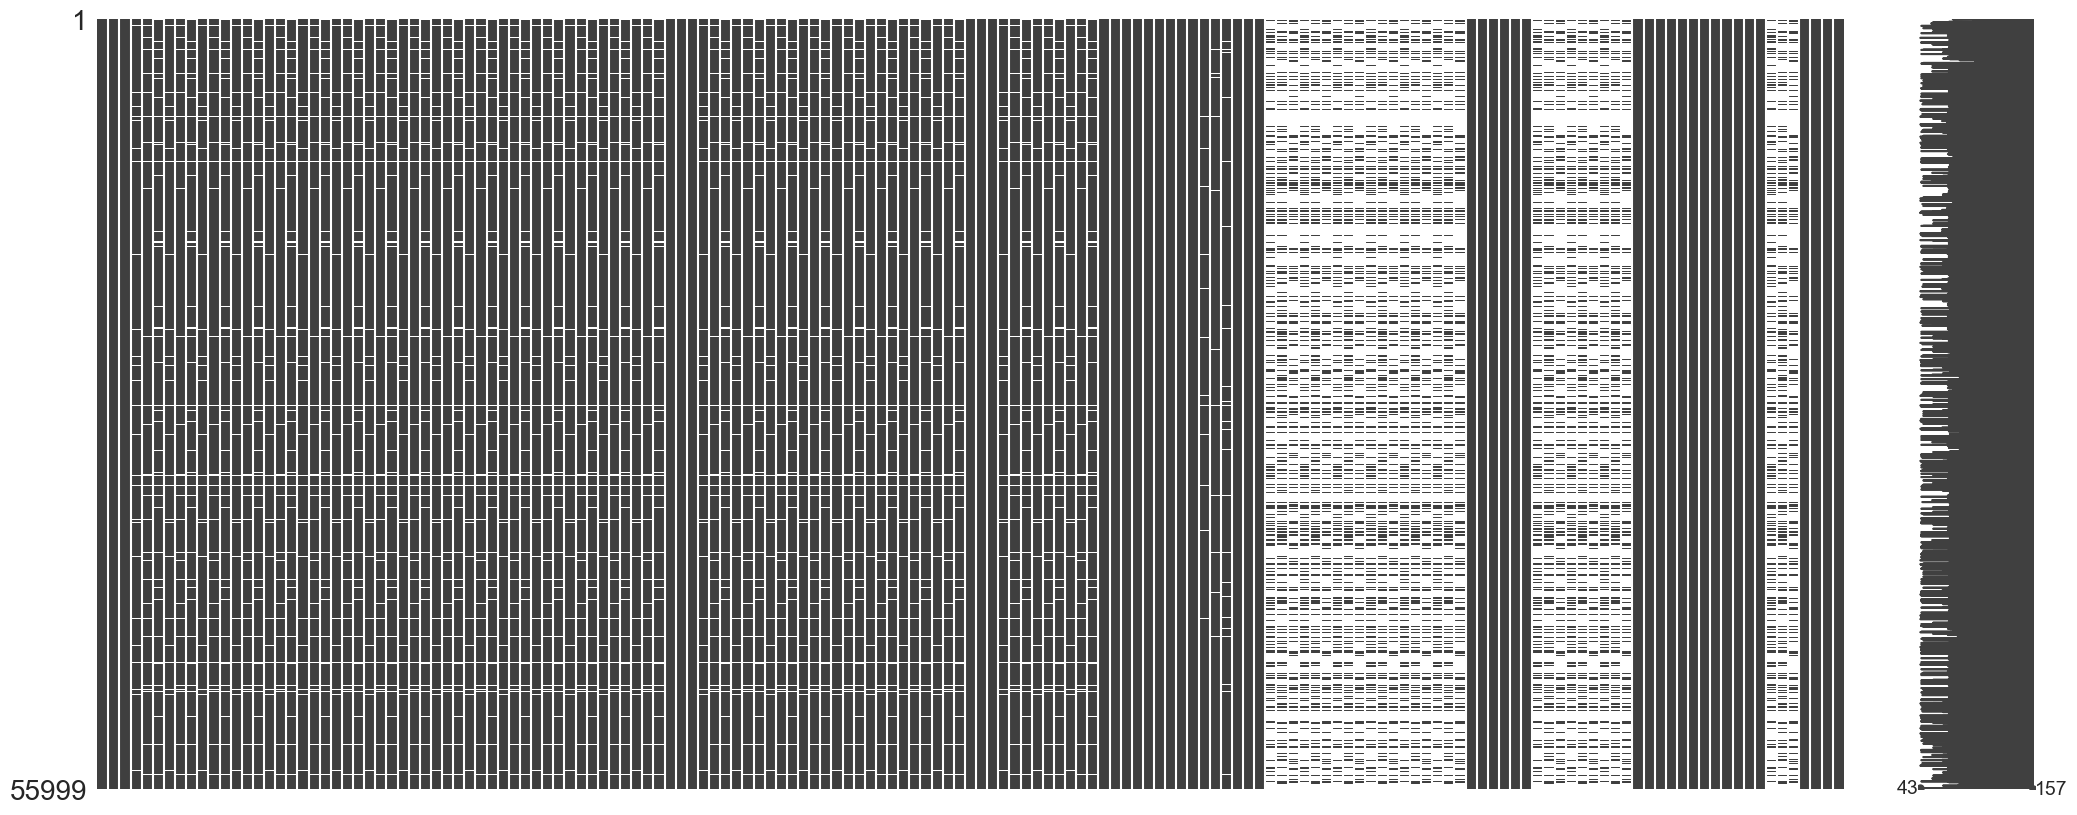

In [24]:
msno.matrix(X_train)

In [25]:
100*X_train.isnull().sum()/X_train.shape[0]

arpu_6                       0.000000
arpu_7                       0.000000
arpu_8                       0.000000
onnet_mou_6                  3.960785
onnet_mou_7                  3.800068
onnet_mou_8                  5.237594
offnet_mou_6                 3.960785
offnet_mou_7                 3.800068
offnet_mou_8                 5.237594
roam_ic_mou_6                3.960785
roam_ic_mou_7                3.800068
roam_ic_mou_8                5.237594
roam_og_mou_6                3.960785
roam_og_mou_7                3.800068
roam_og_mou_8                5.237594
loc_og_t2t_mou_6             3.960785
loc_og_t2t_mou_7             3.800068
loc_og_t2t_mou_8             5.237594
loc_og_t2m_mou_6             3.960785
loc_og_t2m_mou_7             3.800068
loc_og_t2m_mou_8             5.237594
loc_og_t2f_mou_6             3.960785
loc_og_t2f_mou_7             3.800068
loc_og_t2f_mou_8             5.237594
loc_og_t2c_mou_6             3.960785
loc_og_t2c_mou_7             3.800068
loc_og_t2c_m

In [26]:
# Drop columns with missing value percentage greater than the threshold
threshold = 50

X_train = X_train.loc[:, X_train.isnull().mean() * 100 < threshold]

In [27]:
X_train.shape

(55999, 127)

### 3.4 IMPUTING ROWS WITH MISSING VALUES USING SIMPLEIMPUTER

In [28]:
100*X_train.isnull().sum()/X_train.shape[0]

arpu_6                 0.000000
arpu_7                 0.000000
arpu_8                 0.000000
onnet_mou_6            3.960785
onnet_mou_7            3.800068
onnet_mou_8            5.237594
offnet_mou_6           3.960785
offnet_mou_7           3.800068
offnet_mou_8           5.237594
roam_ic_mou_6          3.960785
roam_ic_mou_7          3.800068
roam_ic_mou_8          5.237594
roam_og_mou_6          3.960785
roam_og_mou_7          3.800068
roam_og_mou_8          5.237594
loc_og_t2t_mou_6       3.960785
loc_og_t2t_mou_7       3.800068
loc_og_t2t_mou_8       5.237594
loc_og_t2m_mou_6       3.960785
loc_og_t2m_mou_7       3.800068
loc_og_t2m_mou_8       5.237594
loc_og_t2f_mou_6       3.960785
loc_og_t2f_mou_7       3.800068
loc_og_t2f_mou_8       5.237594
loc_og_t2c_mou_6       3.960785
loc_og_t2c_mou_7       3.800068
loc_og_t2c_mou_8       5.237594
loc_og_mou_6           3.960785
loc_og_mou_7           3.800068
loc_og_mou_8           5.237594
std_og_t2t_mou_6       3.960785
std_og_t

In [29]:
X_train.dtypes

arpu_6                 float64
arpu_7                 float64
arpu_8                 float64
onnet_mou_6            float64
onnet_mou_7            float64
onnet_mou_8            float64
offnet_mou_6           float64
offnet_mou_7           float64
offnet_mou_8           float64
roam_ic_mou_6          float64
roam_ic_mou_7          float64
roam_ic_mou_8          float64
roam_og_mou_6          float64
roam_og_mou_7          float64
roam_og_mou_8          float64
loc_og_t2t_mou_6       float64
loc_og_t2t_mou_7       float64
loc_og_t2t_mou_8       float64
loc_og_t2m_mou_6       float64
loc_og_t2m_mou_7       float64
loc_og_t2m_mou_8       float64
loc_og_t2f_mou_6       float64
loc_og_t2f_mou_7       float64
loc_og_t2f_mou_8       float64
loc_og_t2c_mou_6       float64
loc_og_t2c_mou_7       float64
loc_og_t2c_mou_8       float64
loc_og_mou_6           float64
loc_og_mou_7           float64
loc_og_mou_8           float64
std_og_t2t_mou_6       float64
std_og_t2t_mou_7       float64
std_og_t

In [30]:
X_train[X_train.isnull().any(axis=1)].head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
664,475.536,137.251,0.000,25.26,11.58,NaN,574.48,148.59,NaN,0.00,0.0,NaN,0.00,0.0,NaN,25.26,11.58,NaN,574.48,148.59,NaN,0.0,0.00,NaN,0.0,0.0,NaN,599.74,160.18,NaN,0.00,0.00,NaN,0.00,0.00,NaN,0.0,0.0,NaN,0.00,0.00,NaN,0.0,0.0,NaN,0.0,0.00,NaN,0.0,0.0,NaN,599.74,160.18,0.00,30.48,7.43,NaN,266.76,54.81,NaN,0.00,0.00,NaN,297.24,62.24,NaN,0.00,0.0,NaN,0.78,0.00,NaN,0.00,0.00,NaN,0.78,0.00,NaN,298.29,62.24,0.00,0.0,0.0,NaN,0.0,0.00,NaN,0.26,0.00,NaN,9,3,1,660,110,0,110,110,0,6/29/2014,7/16/2014,8/19/2014,110,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,499,0.0,0.00,0.00
32234,130.030,167.329,130.020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,2,154,198,154,154,198,154,6/13/2014,7/6/2014,8/6/2014,154,0,154,0.09,17.83,141.41,1305.98,1014.22,803.38,1,1,1,0,0,0,0,0,0,0,0,0,710,174.0,88.32,42.34
40646,302.757,97.294,30.000,0.00,1.23,NaN,309.01,115.79,NaN,0.00,0.0,NaN,0.00,0.0,NaN,0.00,1.23,NaN,309.01,115.79,NaN,0.0,0.00,NaN,0.0,0.0,NaN,309.01,117.03,NaN,0.00,0.00,NaN,0.00,0.00,NaN,0.0,0.0,NaN,0.00,0.00,NaN,0.0,0.0,NaN,0.0,0.00,NaN,0.0,0.0,NaN,309.01,117.03,0.00,0.00,0.33,NaN,829.89,540.61,NaN,161.28,429.43,NaN,991.18,970.38,NaN,0.00,0.0,NaN,0.00,0.00,NaN,0.00,0.00,NaN,0.00,0.00,NaN,991.18,970.64,0.00,0.0,0.0,NaN,0.0,0.00,NaN,0.00,0.26,NaN,5,4,2,350,400,0,350,400,0,6/27/2014,7/25/2014,8/19/2014,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,365,0.0,0.00,0.00
39195,198.541,406.714,141.916,500.33,497.11,377.94,200.03,162.89,237.04,0.00,0.0,0.0,0.00,0.0,0.0,500.33,497.11,377.94,186.83,151.18,235.86,0.0,0.15,0.0,0.0,0.0,0.0,687.16,648.44,613.81,0.00,0.00,0.0,13.19,9.86,1.18,0.0,0.0,0.0,13.19,9.86,1.18,0.0,0.0,0.0,0.0,1.70,0.0,0.0,0.0,0.0,700.36,660.01,614.99,156.79,122.41,171.

In [31]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='constant', fill_value=0)

for col in X_train.columns:
    X_train[[col]] = imputer.fit_transform(X_train[[col]])
    # Handling Missing Values for Test and Unseen Data
    X_test[[col]] = imputer.transform(X_test[[col]])
    unseen[[col]] = imputer.transform(unseen[[col]])

In [32]:
100*X_train.isnull().sum()/X_train.shape[0]

arpu_6                 0.0
arpu_7                 0.0
arpu_8                 0.0
onnet_mou_6            0.0
onnet_mou_7            0.0
onnet_mou_8            0.0
offnet_mou_6           0.0
offnet_mou_7           0.0
offnet_mou_8           0.0
roam_ic_mou_6          0.0
roam_ic_mou_7          0.0
roam_ic_mou_8          0.0
roam_og_mou_6          0.0
roam_og_mou_7          0.0
roam_og_mou_8          0.0
loc_og_t2t_mou_6       0.0
loc_og_t2t_mou_7       0.0
loc_og_t2t_mou_8       0.0
loc_og_t2m_mou_6       0.0
loc_og_t2m_mou_7       0.0
loc_og_t2m_mou_8       0.0
loc_og_t2f_mou_6       0.0
loc_og_t2f_mou_7       0.0
loc_og_t2f_mou_8       0.0
loc_og_t2c_mou_6       0.0
loc_og_t2c_mou_7       0.0
loc_og_t2c_mou_8       0.0
loc_og_mou_6           0.0
loc_og_mou_7           0.0
loc_og_mou_8           0.0
std_og_t2t_mou_6       0.0
std_og_t2t_mou_7       0.0
std_og_t2t_mou_8       0.0
std_og_t2m_mou_6       0.0
std_og_t2m_mou_7       0.0
std_og_t2m_mou_8       0.0
std_og_t2f_mou_6       0.0
s

In [33]:
X_train[X_train.isnull().any(axis=1)].head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [34]:
features = X_train.columns

In [35]:
100*X_test[features].isnull().sum()/X_test.shape[0]

arpu_6                 0.0
arpu_7                 0.0
arpu_8                 0.0
onnet_mou_6            0.0
onnet_mou_7            0.0
onnet_mou_8            0.0
offnet_mou_6           0.0
offnet_mou_7           0.0
offnet_mou_8           0.0
roam_ic_mou_6          0.0
roam_ic_mou_7          0.0
roam_ic_mou_8          0.0
roam_og_mou_6          0.0
roam_og_mou_7          0.0
roam_og_mou_8          0.0
loc_og_t2t_mou_6       0.0
loc_og_t2t_mou_7       0.0
loc_og_t2t_mou_8       0.0
loc_og_t2m_mou_6       0.0
loc_og_t2m_mou_7       0.0
loc_og_t2m_mou_8       0.0
loc_og_t2f_mou_6       0.0
loc_og_t2f_mou_7       0.0
loc_og_t2f_mou_8       0.0
loc_og_t2c_mou_6       0.0
loc_og_t2c_mou_7       0.0
loc_og_t2c_mou_8       0.0
loc_og_mou_6           0.0
loc_og_mou_7           0.0
loc_og_mou_8           0.0
std_og_t2t_mou_6       0.0
std_og_t2t_mou_7       0.0
std_og_t2t_mou_8       0.0
std_og_t2m_mou_6       0.0
std_og_t2m_mou_7       0.0
std_og_t2m_mou_8       0.0
std_og_t2f_mou_6       0.0
s

In [36]:
100*unseen[features].isnull().sum()/unseen.shape[0]

arpu_6                 0.0
arpu_7                 0.0
arpu_8                 0.0
onnet_mou_6            0.0
onnet_mou_7            0.0
onnet_mou_8            0.0
offnet_mou_6           0.0
offnet_mou_7           0.0
offnet_mou_8           0.0
roam_ic_mou_6          0.0
roam_ic_mou_7          0.0
roam_ic_mou_8          0.0
roam_og_mou_6          0.0
roam_og_mou_7          0.0
roam_og_mou_8          0.0
loc_og_t2t_mou_6       0.0
loc_og_t2t_mou_7       0.0
loc_og_t2t_mou_8       0.0
loc_og_t2m_mou_6       0.0
loc_og_t2m_mou_7       0.0
loc_og_t2m_mou_8       0.0
loc_og_t2f_mou_6       0.0
loc_og_t2f_mou_7       0.0
loc_og_t2f_mou_8       0.0
loc_og_t2c_mou_6       0.0
loc_og_t2c_mou_7       0.0
loc_og_t2c_mou_8       0.0
loc_og_mou_6           0.0
loc_og_mou_7           0.0
loc_og_mou_8           0.0
std_og_t2t_mou_6       0.0
std_og_t2t_mou_7       0.0
std_og_t2t_mou_8       0.0
std_og_t2m_mou_6       0.0
std_og_t2m_mou_7       0.0
std_og_t2m_mou_8       0.0
std_og_t2f_mou_6       0.0
s

### 3.5 DROP DATE COLUMNS WHICH ARE NOT REQUIRED FOR ANALYSIS

In [37]:
X_train.head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
47338,172.250,149.720,244.222,20.71,13.16,48.34,152.38,129.73,268.23,0.0,0.0,0.0,0.0,0.0,0.0,20.71,13.16,48.34,140.83,121.26,241.23,11.54,6.79,26.99,0.00,1.66,0.0,173.09,141.23,316.58,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,1.66,0.00,0.00,0.0,0.0,173.09,142.89,316.58,17.83,16.69,34.51,44.74,29.91,82.41,6.89,40.14,79.53,69.48,86.76,196.46,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,166.04,121.78,205.19,0.0,0.0,0.0,96.56,35.01,8.73,0.00,0.00,0.0,6,4,2,0,0,398,0,0,398,6/27/2014,7/25/2014,8/6/2014,0,0,398,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,395,0.0,0.0,0.0
67455,155.610,53.934,47.532,11.84,7.54,5.33,107.69,44.76,28.31,0.0,0.0,0.0,0.0,0.0,0.0,11.84,7.54,5.33,86.66,31.26,28.31,0.00,0.00,0.00,20.63,0.00,0.0,98.51,38.81,33.64,0.00,0.00,0.00,0.00,11.13,0.00,0.0,0.0,0.0,0.00,11.13,0.00,0.0,0.0,0.0,21.26,2.88,2.18,0.00,0.0,0.0,119.78,52.83,35.83,109.71,77.11,15.64,533.33,288.61,204.88,2.00,0.55,0.00,645.04,366.28,220.53,0.00,0.00,0.00,0.00,32.41,0.00,0.0,0.73,0.0,0.00,33.14,0.00,645.04,399.43,220.53,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,12,4,3,174,57,70,30,30,30,6/30/2014,7/21/2014,8/28/2014,10,7,30,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,515,0.0,0.0,0.0
12308,68.285,71.308,35.515,12.64,5.63,0.00,23.16,44.66,19.21,0.0,0.0,0.0,0.0,0.0,0.0,8.94,4.86,0.00,14.44,1.10,1.21,0.00,0.00,0.00,0.00,1.46,0.0,23.39,5.96,1.21,3.70,0.76,0.00,8.71,43.56,18.00,0.0,0.0,0.0,12.41,44.33,18.00,0.0,0.0,0.0,0.20,9.73,2.93,0.81,0.0,0.0,36.83,60.03,22.14,35.99,35.13,3.56,79.36,62.06,8.91,1.08,0.94,0.00,116.44,98.14,12.48,0.18,5.28,0.68,48.76,52.11,0.21,0.0,3.95,0.0,48.94,61.34,0.89,165.59,164.36,13.38,0.0,0.2,0.0,0.00,0.00,0.00,0.20,4.66,0.0,5,5,3,80,80,40,30,50,30,6/29/2014,7/29/2014,8/10/2014,30,50,10,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,595,0.0,0.0,0.0
52334,139.165,205.666,172.807,68.78,207.41,57.04,172.33,187.66,239.06,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.71,0.00,1.54,0.00,0.00,0.00,0.00,0.35,0.0,1.71,0.00,1.54,68.78,207.41,57.04,170.61,187

In [38]:
# Dropping Date columns as they do not contribute to business sense
date_columns = ['date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']

X_train.drop(columns=date_columns, inplace=True)
    
X_train.head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
47338,172.250,149.720,244.222,20.71,13.16,48.34,152.38,129.73,268.23,0.0,0.0,0.0,0.0,0.0,0.0,20.71,13.16,48.34,140.83,121.26,241.23,11.54,6.79,26.99,0.00,1.66,0.0,173.09,141.23,316.58,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,1.66,0.00,0.00,0.0,0.0,173.09,142.89,316.58,17.83,16.69,34.51,44.74,29.91,82.41,6.89,40.14,79.53,69.48,86.76,196.46,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,166.04,121.78,205.19,0.0,0.0,0.0,96.56,35.01,8.73,0.00,0.00,0.0,6,4,2,0,0,398,0,0,398,0,0,398,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,395,0.0,0.0,0.0
67455,155.610,53.934,47.532,11.84,7.54,5.33,107.69,44.76,28.31,0.0,0.0,0.0,0.0,0.0,0.0,11.84,7.54,5.33,86.66,31.26,28.31,0.00,0.00,0.00,20.63,0.00,0.0,98.51,38.81,33.64,0.00,0.00,0.00,0.00,11.13,0.00,0.0,0.0,0.0,0.00,11.13,0.00,0.0,0.0,0.0,21.26,2.88,2.18,0.00,0.0,0.0,119.78,52.83,35.83,109.71,77.11,15.64,533.33,288.61,204.88,2.00,0.55,0.00,645.04,366.28,220.53,0.00,0.00,0.00,0.00,32.41,0.00,0.0,0.73,0.0,0.00,33.14,0.00,645.04,399.43,220.53,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,12,4,3,174,57,70,30,30,30,10,7,30,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,515,0.0,0.0,0.0
12308,68.285,71.308,35.515,12.64,5.63,0.00,23.16,44.66,19.21,0.0,0.0,0.0,0.0,0.0,0.0,8.94,4.86,0.00,14.44,1.10,1.21,0.00,0.00,0.00,0.00,1.46,0.0,23.39,5.96,1.21,3.70,0.76,0.00,8.71,43.56,18.00,0.0,0.0,0.0,12.41,44.33,18.00,0.0,0.0,0.0,0.20,9.73,2.93,0.81,0.0,0.0,36.83,60.03,22.14,35.99,35.13,3.56,79.36,62.06,8.91,1.08,0.94,0.00,116.44,98.14,12.48,0.18,5.28,0.68,48.76,52.11,0.21,0.0,3.95,0.0,48.94,61.34,0.89,165.59,164.36,13.38,0.0,0.2,0.0,0.00,0.00,0.00,0.20,4.66,0.0,5,5,3,80,80,40,30,50,30,30,50,10,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,595,0.0,0.0,0.0
52334,139.165,205.666,172.807,68.78,207.41,57.04,172.33,187.66,239.06,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.71,0.00,1.54,0.00,0.00,0.00,0.00,0.35,0.0,1.71,0.00,1.54,68.78,207.41,57.04,170.61,187.31,237.51,0.0,0.0,0.0,239.39,394.73,294.56,0.0,0.0,0.0,0.00,0.35,0.00,0.00,0.0,0.0,241.11,395.08,296.11,0.00,0.00,0.00,9.43,6.16,2.51,0.00,0.00,0.00,9.

### 3.6 DROPPING COLUMNS THAT ARE CORRELATED TO OTHERS

In [39]:
# Checking for Correlation between Independent Variables
corr = X_train.corr()
corr.loc[:, :] = np.tril(corr, -1)
corr = corr.stack()

In [40]:
corr[(corr > 0.70) | (corr < -0.70)]

arpu_7            arpu_6              0.709880
arpu_8            arpu_7              0.751045
onnet_mou_7       onnet_mou_6         0.735950
onnet_mou_8       onnet_mou_7         0.785000
offnet_mou_7      offnet_mou_6        0.740543
offnet_mou_8      offnet_mou_7        0.764095
loc_og_t2t_mou_7  loc_og_t2t_mou_6    0.785208
loc_og_t2t_mou_8  loc_og_t2t_mou_7    0.808376
loc_og_t2m_mou_7  loc_og_t2m_mou_6    0.789582
loc_og_t2m_mou_8  loc_og_t2m_mou_7    0.815537
loc_og_t2f_mou_7  loc_og_t2f_mou_6    0.780236
loc_og_t2f_mou_8  loc_og_t2f_mou_6    0.709437
                  loc_og_t2f_mou_7    0.787547
loc_og_mou_6      loc_og_t2t_mou_6    0.768139
                  loc_og_t2m_mou_6    0.825051
loc_og_mou_7      loc_og_t2t_mou_7    0.778116
                  loc_og_t2m_mou_7    0.800725
                  loc_og_mou_6        0.810747
loc_og_mou_8      loc_og_t2t_mou_8    0.788028
                  loc_og_t2m_mou_8    0.794879
                  loc_og_mou_6        0.732358
             

In [41]:
# Based on the above correlations the following features are well implied by the other features and hence, are less important
columns_to_drop = [
    'loc_og_t2t_mou_6', 'loc_og_t2t_mou_7', 'loc_og_t2t_mou_8', 
    'loc_og_t2m_mou_6', 'loc_og_t2m_mou_7', 'loc_og_t2m_mou_8',
    'loc_og_t2f_mou_6', 'loc_og_t2f_mou_7', 'loc_og_t2f_mou_8',
    'loc_og_t2c_mou_6', 'loc_og_t2c_mou_7', 'loc_og_t2c_mou_8',
    'loc_ic_t2t_mou_6', 'loc_ic_t2t_mou_7', 'loc_ic_t2t_mou_8', 
    'loc_ic_t2m_mou_6', 'loc_ic_t2m_mou_7', 'loc_ic_t2m_mou_8',
    'loc_ic_t2f_mou_6', 'loc_ic_t2f_mou_7', 'loc_ic_t2f_mou_8',
    'std_og_t2t_mou_6', 'std_og_t2t_mou_7', 'std_og_t2t_mou_8',
    'std_og_t2m_mou_6', 'std_og_t2m_mou_7', 'std_og_t2m_mou_8',
    'std_og_t2f_mou_6', 'std_og_t2f_mou_7', 'std_og_t2f_mou_8',
    'std_ic_t2t_mou_6', 'std_ic_t2t_mou_7', 'std_ic_t2t_mou_8',
    'std_ic_t2m_mou_6', 'std_ic_t2m_mou_7', 'std_ic_t2m_mou_8',
    'std_ic_t2f_mou_6', 'std_ic_t2f_mou_7', 'std_ic_t2f_mou_8',
]

In [42]:
X_train.drop(columns_to_drop, axis=1, inplace=True)
X_train.shape

(55999, 85)

In [43]:
X_train.head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
47338,172.250,149.720,244.222,20.71,13.16,48.34,152.38,129.73,268.23,0.0,0.0,0.0,0.0,0.0,0.0,173.09,141.23,316.58,0.00,0.00,0.00,0.0,0.0,0.0,0.00,1.66,0.00,0.00,0.0,0.0,173.09,142.89,316.58,69.48,86.76,196.46,0.00,0.00,0.00,166.04,121.78,205.19,0.0,0.0,0.0,96.56,35.01,8.73,0.00,0.00,0.0,6,4,2,0,0,398,0,0,398,0,0,398,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,395,0.0,0.0,0.0
67455,155.610,53.934,47.532,11.84,7.54,5.33,107.69,44.76,28.31,0.0,0.0,0.0,0.0,0.0,0.0,98.51,38.81,33.64,0.00,11.13,0.00,0.0,0.0,0.0,21.26,2.88,2.18,0.00,0.0,0.0,119.78,52.83,35.83,645.04,366.28,220.53,0.00,33.14,0.00,645.04,399.43,220.53,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,12,4,3,174,57,70,30,30,30,10,7,30,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,515,0.0,0.0,0.0
12308,68.285,71.308,35.515,12.64,5.63,0.00,23.16,44.66,19.21,0.0,0.0,0.0,0.0,0.0,0.0,23.39,5.96,1.21,12.41,44.33,18.00,0.0,0.0,0.0,0.20,9.73,2.93,0.81,0.0,0.0,36.83,60.03,22.14,116.44,98.14,12.48,48.94,61.34,0.89,165.59,164.36,13.38,0.0,0.2,0.0,0.00,0.00,0.00,0.20,4.66,0.0,5,5,3,80,80,40,30,50,30,30,50,10,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,595,0.0,0.0,0.0
52334,139.165,205.666,172.807,68.78,207.41,57.04,172.33,187.66,239.06,0.0,0.0,0.0,0.0,0.0,0.0,1.71,0.00,1.54,239.39,394.73,294.56,0.0,0.0,0.0,0.00,0.35,0.00,0.00,0.0,0.0,241.11,395.08,296.11,9.43,6.16,2.51,12.11,27.38,16.99,21.54,33.54,19.51,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,7,10,5,226,236,136,110,110,50,10,110,36,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,656,0.0,0.0,0.0
664,475.536,137.251,0.000,25.26,11.58,0.00,574.48,148.59,0.00,0.0,0.0,0.0,0.0,0.0,0.0,599.74,160.18,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,599.74,160.18,0.00,297.24,62.24,0.00,0.78,0.00,0.00,298.29,62.24,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.26,0.00,0.0,9,3,1,660,110,0,110,110,0,110,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,499,0.0,0.0,0.0


<Axes: >

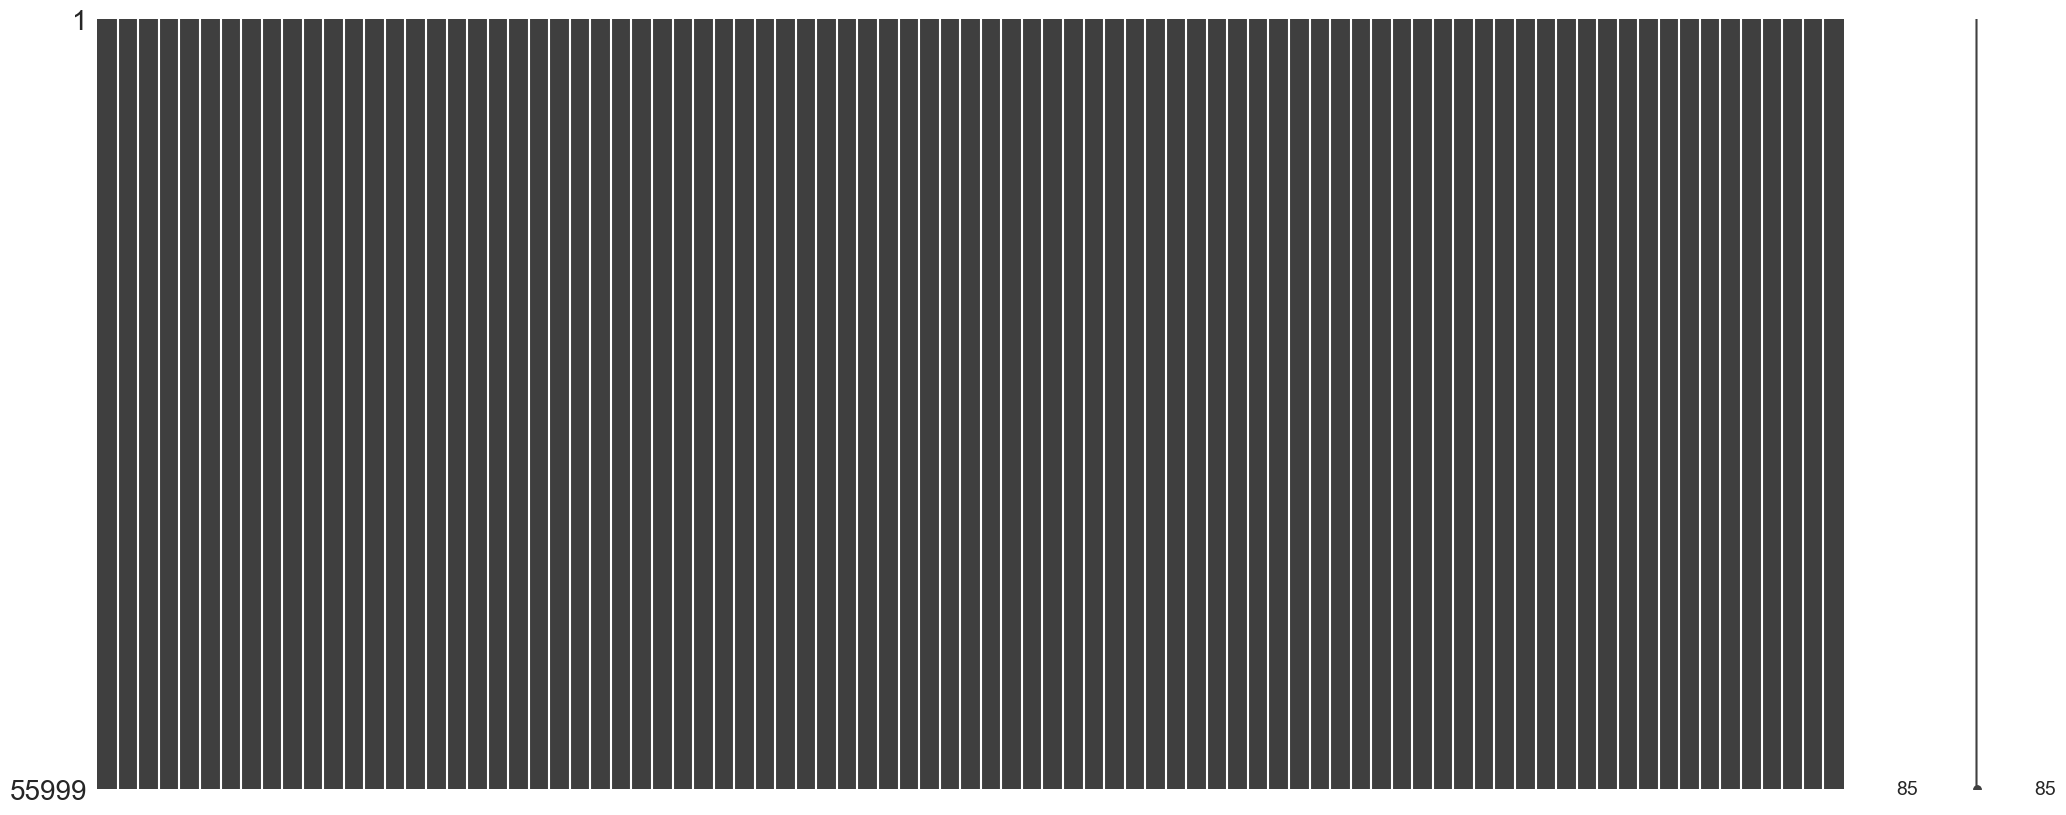

In [44]:
msno.matrix(X_train)

## STEP #4 - HANDLING OUTLIERS

In [45]:
# Function to cap outliers using the K-sigma method
def cap_outliers_k_sigma_method(series, k=3):
    mean = series.mean()
    std_dev = series.std()
    lower_bound = mean - k * std_dev
    upper_bound = mean + k * std_dev
    return series.apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))

In [46]:
# Handling Outliers
columns_to_handle = [i for i in list(X_train.columns) if X_train[i].nunique() > 50]

for col in columns_to_handle:
    X_train[col] = cap_outliers_k_sigma_method(X_train[col])

X_train.shape

(55999, 85)

## STEP #5 - EXPLORATORY DATA ANALYSIS

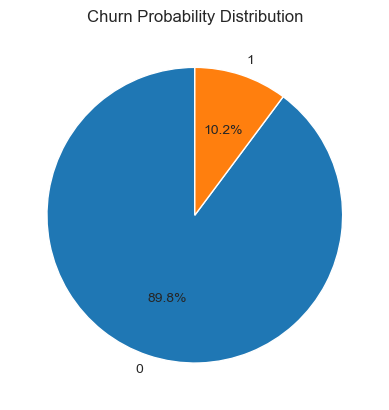

In [47]:
# Checking Balance of Target Variable
pd.Series(y_train).value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.ylabel('')
plt.title('Churn Probability Distribution')
plt.show()

#### OBSERVATION: The data is highly imbalanced

### 5.1 UNIVARIATE ANALYSIS

In [48]:
# Total Usage Metrics
columns = [i for i in list(X_train.columns) if re.search('arpu|offnet|onnet|total|max|vol|aon',i)]
plt.figure(figsize=(15,8))
plt.xticks(rotation=45, ha='right')
sns.boxplot(data = X_train[columns])
plt.show()

In [49]:
# Outgoing Usage Metrics
columns = [i for i in list(X_train.columns) if re.search('og',i)]
plt.figure(figsize=(15,8))
plt.xticks(rotation=45, ha='right')
sns.boxplot(data = X_train[columns])
plt.show()

In [50]:
# Incoming Usage Metrics
columns = [i for i in list(X_train.columns) if re.search('ic',i)]
plt.figure(figsize=(15,8))
plt.xticks(rotation=45, ha='right')
sns.boxplot(data = X_train[columns])
plt.show()

##### Roaming, ISD, Special Package Data, and Others are highly skewed for both outgoing and incoming usages.

In [51]:
# Data Usage and Recharge Patterns
columns = [i for i in list(X_train.columns) if re.search('2g|3g|rech',i)]
plt.figure(figsize=(15,8))
plt.xticks(rotation=45, ha='right')
sns.boxplot(data = X_train[columns])
plt.show()

##### Most of the features are highly skewed and we need to perform Data transormation. Since they have a Positive Skew we should perform a Log Transformation

### 5.2 BIVARIATE ANALYSIS

In [52]:
# Average Revenue Per User
columns = [col for col in X_train.columns if re.search('arpu', col)]
plt.figure(figsize=(12, 4))

for i, col in enumerate(columns):
    plt.subplot(1, len(columns), i + 1)
    sns.violinplot(x=pd.Series(y_train), y=X_train[col], palette="viridis")
    plt.title(f'{col}')
    plt.xlabel('Churn Probability')
    plt.ylabel('')

plt.suptitle('Average Revenue Per User (ARPU) Metrics with Churn Probability')
plt.tight_layout()
plt.show()

##### 1. Variance of ARPU significantly drops for users having a Churn Probability of 1

In [53]:
# Total Usage Metrics
columns = [i for i in list(X_train.columns) if re.search('total.+mou',i)]
plt.figure(figsize=(12, 7))

for i, col in enumerate(columns):
    plt.subplot(2, 3, i + 1)
    sns.violinplot(x=pd.Series(y_train), y=X_train[col], palette="viridis")
    plt.title(f'{col}')
    plt.xlabel('Churn Probability')
    plt.ylabel('')

plt.suptitle('Total Usage Metrics with Churn Probability')
plt.tight_layout()
plt.show()

##### 2. Outgoing Usage Decrease more drastically than Incoming Usage.

In [54]:
# Local Network Usage Metrics
columns = [i for i in list(X_train.columns) if re.search('loc_ic_mou|loc_og_mou',i)]
plt.figure(figsize=(12, 7))

for i, col in enumerate(columns):
    plt.subplot(2, 3, i + 1)
    sns.violinplot(x=pd.Series(y_train), y=X_train[col], palette="viridis")
    plt.title(f'{col}')
    plt.xlabel('Churn Probability')
    plt.ylabel('')

plt.suptitle('Local Network Usage Metrics with Churn Probability')
plt.tight_layout()
plt.show()

##### 3. Volume of Local Incoming decreased but variance increased for customers who churned

In [55]:
# STD Network Usage Metrics
columns = [i for i in list(X_train.columns) if re.search('std_ic_mou|std_og_mou',i)]
plt.figure(figsize=(12, 7))

for i, col in enumerate(columns):
    plt.subplot(2, 3, i + 1)
    sns.violinplot(x=pd.Series(y_train), y=X_train[col], palette="viridis")
    plt.title(f'{col}')
    plt.xlabel('Churn Probability')
    plt.ylabel('')

plt.suptitle('STD Network Usage Metrics with Churn Probability')
plt.tight_layout()
plt.show()

##### 4. STD Usage was higher in customers who churned as compared to customers who didn't churn in June and drastically decreased over the months. It appears that the customers who churn usually used the telecom services for STD rather than local.

In [56]:
# Recharge Patterns
columns = [i for i in list(X_train.columns) if re.search('rech_amt',i)]
plt.figure(figsize=(12, 7))

for i, col in enumerate(columns):
    plt.subplot(2, 3, i + 1)
    sns.violinplot(x=pd.Series(y_train), y=X_train[col], palette="viridis")
    plt.title(f'{col}')
    plt.xlabel('Churn Probability')
    plt.ylabel('')

plt.suptitle('Recharge Amount with Churn Probability')
plt.tight_layout()
plt.show()

##### 5. Maximum Recharge Amount decreased from 100 to 50  and then to zero over the months.

## STEP #6 - FEATURE ENGINEERING

In [57]:
X_train.shape

(55999, 85)

In [58]:
features = X_train.columns

In [59]:
X_test[features].head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
57621,1127.020,1363.096,421.153,365.19,402.24,165.88,216.56,168.61,57.63,0.0,0.00,0.0,0.0,0.00,0.0,386.98,382.71,156.33,107.19,60.54,55.19,87.58,128.98,3.01,0.00,0.68,9.29,1.78,0.0,0.0,583.54,572.93,223.84,146.16,164.71,153.13,38.68,38.09,52.53,258.03,263.19,279.93,0.00,0.0,0.0,73.18,60.38,74.26,0.00,0.00,0.0,25,26,14,1525,1805,465,110,120,70,30,30,30,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,669,0.00,0.00,0.00
39559,517.241,407.339,426.689,112.28,126.01,99.61,226.66,358.43,423.01,0.0,0.00,0.0,0.0,0.00,0.0,185.33,195.09,156.84,151.46,274.98,357.73,0.00,0.00,0.00,2.15,14.36,8.05,0.00,0.0,0.0,338.94,484.44,522.63,83.63,58.56,133.66,29.69,6.64,22.94,113.73,65.59,156.61,0.39,0.0,0.0,0.00,0.00,0.00,0.00,0.38,0.0,9,12,11,640,489,501,154,154,154,65,0,0,193.77,128.26,7.73,1102.99,812.47,1181.12,2,1,1,3,7,5,0,0,0,0,0,0,464,107.79,916.29,1235.71
41415,648.204,586.811,618.653,777.76,766.84,802.01,424.31,220.96,351.34,0.0,0.00,0.0,0.0,0.00,0.0,15.41,30.63,24.84,1186.66,957.01,1128.51,0.00,0.00,0.00,0.00,0.16,0.00,0.00,0.0,0.0,1202.08,987.81,1153.36,18.41,71.01,28.18,16.58,11.74,13.73,39.91,82.76,41.91,0.00,0.0,0.0,0.00,0.00,0.00,4.91,0.00,0.0,33,40,32,746,656,716,70,50,50,50,20,30,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,405,0.00,0.00,0.00
47731,245.917,177.315,132.963,172.14,83.96,84.58,171.76,59.28,23.11,0.0,0.00,0.0,0.0,0.00,0.0,43.26,59.51,16.96,299.63,83.73,83.11,1.01,0.00,0.00,0.00,0.00,7.61,0.00,0.0,0.0,343.91,143.24,107.69,112.23,119.73,113.16,3.41,0.15,0.58,115.64,119.88,113.74,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,13,12,11,270,200,150,30,30,30,20,30,20,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,1240,0.00,0.00,0.00
64801,891.619,765.631,920.688,475.13,419.36,650.71,867.71,615.79,610.68,0.0,35.04,0.0,0.0,116.76,0.0,303.99,245.63,335.33,1023.59,672.49,915.86,0.20,0.26,0.00,15.04,0.00,10.20,0.00,0.0,0.0,1342.84,918.39,1261.39,271.51,188.09,289.79,82.48,170.19,147.83,356.09,358.96,437.63,0.00,0.0,0.0,2.09,0.66,0.00,0.00,0.00,0.0,13,10,13,1100,971,996,279,250,250,0,0,0,40.48,11.32,24.68,334.78,946.45,1493.41,1,1,1,5,1,0,0,0,1,0,0,0,1541,1239.80,496.45,271.36


In [60]:
unseen[features].head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
69999,91.882,65.330,64.445,31.78,20.23,23.11,60.16,32.16,34.83,0.00,0.00,0.00,0.00,0.00,0.00,43.01,44.71,29.43,48.93,7.68,28.48,0.0,0.0,0.0,0.00,0.00,0.03,0.0,0.0,0.0,91.94,52.39,57.94,40.81,42.16,31.51,0.36,1.04,4.34,41.73,43.56,36.26,0.54,0.34,0.39,0.00,0.00,0.00,0.0,0.0,0.00,5,5,4,103,90,60,50,30,30,30,30,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1692,0.00,0.00,0.00
70000,414.168,515.568,360.868,75.51,41.21,19.84,474.34,621.84,394.94,0.00,0.00,0.00,0.00,0.00,0.00,549.86,639.29,397.11,0.00,23.76,17.68,0.0,0.0,0.8,0.00,0.00,0.00,0.0,0.0,0.0,549.86,663.06,415.59,181.69,149.24,187.43,0.00,12.51,0.00,296.33,339.64,281.66,0.00,0.00,0.00,114.63,177.88,94.23,0.0,0.0,0.00,5,4,5,500,500,500,250,250,250,250,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,2533,0.00,0.00,0.00
70001,329.844,434.884,746.239,7.54,7.86,8.40,16.98,45.81,45.04,22.81,103.38,26.08,24.53,53.68,54.44,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.00,6,9,5,500,1000,1000,300,500,500,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,277,525.61,758.41,241.84
70002,43.550,171.390,24.400,5.31,2.16,0.00,40.04,205.01,24.01,0.00,0.00,0.00,0.00,0.00,0.00,8.26,98.61,22.86,37.09,96.53,0.00,0.0,0.0,0.0,0.00,12.03,1.15,0.0,0.0,0.0,45.36,207.18,24.01,546.06,504.86,531.64,9.63,16.14,8.83,555.69,522.44,549.13,0.00,0.00,0.00,0.00,1.43,8.65,0.0,0.0,0.00,3,5,2,110,260,0,110,150,0,110,150,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1244,0.00,0.00,0.00
70003,306.854,406.289,413.329,450.93,609.03,700.68,60.94,23.84,74.16,0.00,0.00,0.00,0.00,0.00,0.00,2.84,3.44,25.51,509.03,629.43,749.29,0.0,0.0,0.0,0.71,5.39,4.96,2.2,0.0,0.0,514.79,638.28,779.78,10.13,9.59,17.61,43.59,106.33,141.48,53.73,115.93,159.26,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.16,11,7,8,356,490,546,90,130,130,50,130,130,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,462,0.00,0.00,0.00


### 6.1 DERIVING NEW FEATURES

In [61]:
# Ratio of total outgoing amount and age on network (average daily usage)
X_train['avg_daily_usage_ratio'] = X_train[['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8']].sum(axis=1) / X_train['aon']

X_test['avg_daily_usage_ratio'] = X_test[['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8']].sum(axis=1) / X_test['aon']

unseen['avg_daily_usage_ratio'] = unseen[['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8']].sum(axis=1) / unseen['aon']

In [62]:
# Standard deviation of ARPU over the three months
X_train['arpu_std_dev'] = X_train[['arpu_6', 'arpu_7', 'arpu_8']].std(axis=1)

X_test['arpu_std_dev'] = X_test[['arpu_6', 'arpu_7', 'arpu_8']].std(axis=1)

unseen['arpu_std_dev'] = unseen[['arpu_6', 'arpu_7', 'arpu_8']].std(axis=1)

In [63]:
X_train.head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,avg_daily_usage_ratio,arpu_std_dev
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
47338,172.250,149.720,244.222,20.71,13.16,48.34,152.38,129.73,268.23,0.0,0.0,0.0,0.0,0.0,0.0,173.09,141.23,316.58,0.00,0.00,0.00,0.0,0.0,0.0,0.00,1.66,0.00,0.00,0.0,0.0,173.09,142.89,316.58,69.48,86.76,196.46,0.00,0.00,0.00,166.04,121.78,205.19,0.0,0.0,0.0,96.56,35.01,8.73,0.00,0.00,0.0,6.0,4.0,2.0,0.0,0.0,398.0,0.0,0.0,398.0,0.0,0.0,367.448883,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,395.0,0.0,0.0,0.0,1.601418,49.359561
67455,155.610,53.934,47.532,11.84,7.54,5.33,107.69,44.76,28.31,0.0,0.0,0.0,0.0,0.0,0.0,98.51,38.81,33.64,0.00,11.13,0.00,0.0,0.0,0.0,21.26,2.88,2.18,0.00,0.0,0.0,119.78,52.83,35.83,645.04,366.28,220.53,0.00,33.14,0.00,645.04,399.43,220.53,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,12.0,4.0,3.0,174.0,57.0,70.0,30.0,30.0,30.0,10.0,7.0,30.000000,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,515.0,0.0,0.0,0.0,0.404738,60.635315
12308,68.285,71.308,35.515,12.64,5.63,0.00,23.16,44.66,19.21,0.0,0.0,0.0,0.0,0.0,0.0,23.39,5.96,1.21,12.41,44.33,18.00,0.0,0.0,0.0,0.20,9.73,2.93,0.81,0.0,0.0,36.83,60.03,22.14,116.44,98.14,12.48,48.94,61.34,0.89,165.59,164.36,13.38,0.0,0.2,0.0,0.00,0.00,0.00,0.20,4.66,0.0,5.0,5.0,3.0,80.0,80.0,40.0,30.0,50.0,30.0,30.0,50.0,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,595.0,0.0,0.0,0.0,0.200000,19.850064
52334,139.165,205.666,172.807,68.78,207.41,57.04,172.33,187.66,239.06,0.0,0.0,0.0,0.0,0.0,0.0,1.71,0.00,1.54,239.39,394.73,294.56,0.0,0.0,0.0,0.00,0.35,0.00,0.00,0.0,0.0,241.11,395.08,296.11,9.43,6.16,2.51,12.11,27.38,16.99,21.54,33.54,19.51,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,7.0,10.0,5.0,226.0,236.0,136.0,110.0,110.0,50.0,10.0,110.0,36.000000,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,656.0,0.0,0.0,0.0,1.421189,33.251268
664,475.536,137.251,0.000,25.26,11.58,0.00,574.48,148.59,0.00,0.0,0.0,0.0,0.0,0.0,0.0,599.74,160.18,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,599.74,160.18,0.00,297.24,62.24,0.00,0.78,0.00,0.00,298.29,62.24,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.26,0.00,0.0,9.0,3.0,1.0,660.0,110.0,0.0,110.0,110.0,0.0,110.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,499.0,0.0,0.0,0.0,1.522886,244.747852


In [64]:
X_train.shape

(55999, 87)

### 6.2 COMBINING EXISTING FEATURES

In [65]:
# Assuming that June and July were the relatively good months;
# And August is the bad month and September is the month when the customers churned.
# Combining the data for June and July is a reasonable option.
columns_to_combine = [i[:-2] for i in list(X_train.columns) if re.search('_6|_7', i)]
columns_to_combine = list(set(columns_to_combine))

for col in columns_to_combine:
    X_train[f'good_phase_{col}'] = (X_train[f'{col}_6'] + X_train[f'{col}_7']) / 2
    X_train.drop([f'{col}_6', f'{col}_7'], axis=1, inplace=True)
    
X_train['good_phase_vbc_3g'] = (X_train['jun_vbc_3g'] + X_train['jul_vbc_3g']) / 2
X_train.drop(['jun_vbc_3g', 'jul_vbc_3g'], axis=1, inplace=True)

In [66]:
# Applying the same thing to the test data in order to prevent errors
for col in columns_to_combine:
    X_test[f'good_phase_{col}'] = (X_test[f'{col}_6'] + X_test[f'{col}_7']) / 2
    X_test.drop([f'{col}_6', f'{col}_7'], axis=1, inplace=True)
    
X_test['good_phase_vbc_3g'] = (X_test['jun_vbc_3g'] + X_test['jul_vbc_3g']) / 2

In [67]:
# Applying the same thing to the unseen data in order to prevent errors
for col in columns_to_combine:
    unseen[f'good_phase_{col}'] = (unseen[f'{col}_6'] + unseen[f'{col}_7']) / 2
    unseen.drop([f'{col}_6', f'{col}_7'], axis=1, inplace=True)
    
unseen['good_phase_vbc_3g'] = (unseen['jun_vbc_3g'] + unseen['jul_vbc_3g']) / 2

In [68]:
X_train.head()

,arpu_8,onnet_mou_8,offnet_mou_8,roam_ic_mou_8,roam_og_mou_8,loc_og_mou_8,std_og_mou_8,isd_og_mou_8,spl_og_mou_8,og_others_8,total_og_mou_8,loc_ic_mou_8,std_ic_mou_8,total_ic_mou_8,spl_ic_mou_8,isd_ic_mou_8,ic_others_8,total_rech_num_8,total_rech_amt_8,max_rech_amt_8,last_day_rch_amt_8,vol_2g_mb_8,vol_3g_mb_8,monthly_2g_8,sachet_2g_8,monthly_3g_8,sachet_3g_8,aon,aug_vbc_3g,avg_daily_usage_ratio,arpu_std_dev,good_phase_total_ic_mou,good_phase_last_day_rch_amt,good_phase_roam_ic_mou,good_phase_vol_3g_mb,good_phase_std_ic_mou,good_phase_sachet_3g,good_phase_loc_ic_mou,good_phase_std_og_mou,good_phase_offnet_mou,good_phase_loc_og_mou,good_phase_monthly_3g,good_phase_ic_others,good_phase_sachet_2g,good_phase_total_og_mou,good_phase_total_rech_num,good_phase_isd_og_mou,good_phase_isd_ic_mou,good_phase_roam_og_mou,good_phase_monthly_2g,good_phase_spl_ic_mou,good_phase_total_rech_amt,good_phase_spl_og_mou,good_phase_arpu,good_phase_max_rech_amt,good_phase_onnet_mou,good_phase_og_others,good_phase_vol_2g_mb,good_phase_vbc_3g
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
47338,244.222,48.34,268.23,0.0,0.0,316.58,0.00,0.0,0.00,0.0,316.58,196.46,0.00,205.19,0.0,8.73,0.0,2.0,398.0,398.0,367.448883,0.0,0.0,0,0,0,0,395.0,0.0,1.601418,49.359561,143.910,0.0,0.0,0.0,0.000,0.0,78.120,0.000,141.055,157.160,0.0,0.00,0.0,157.990,5.0,0.0,65.785,0.0,0.0,0.0,0.0,0.830,160.9850,0.0,16.935,0.000,0.0,0.0
67455,47.532,5.33,28.31,0.0,0.0,33.64,0.00,0.0,2.18,0.0,35.83,220.53,0.00,220.53,0.0,0.00,0.0,3.0,70.0,30.0,30.000000,0.0,0.0,0,0,0,0,515.0,0.0,0.404738,60.635315,522.235,8.5,0.0,0.0,16.570,0.0,505.660,5.565,76.225,68.660,0.0,0.00,0.0,86.305,8.0,0.0,0.000,0.0,0.0,0.0,115.5,12.070,104.7720,30.0,9.690,0.000,0.0,0.0
12308,35.515,0.00,19.21,0.0,0.0,1.21,18.00,0.0,2.93,0.0,22.14,12.48,0.89,13.38,0.0,0.00,0.0,3.0,40.0,30.0,10.000000,0.0,0.0,0,0,0,0,595.0,0.0,0.200000,19.850064,164.975,40.0,0.0,0.0,55.140,0.0,107.290,28.370,33.910,14.675,0.0,2.43,0.0,48.430,5.0,0.0,0.000,0.0,0.0,0.1,80.0,4.965,69.7965,40.0,9.135,0.405,0.0,0.0
52334,172.807,57.04,239.06,0.0,0.0,1.54,294.56,0.0,0.00,0.0,296.11,2.51,16.99,19.51,0.0,0.00,0.0,5.0,136.0,50.0,36.000000,0.0,0.0,0,0,0,0,656.0,0.0,1.421189,33.251268,27.540,60.0,0.0,0.0,19.745,0.0,7.795,317.060,179.995,0.855,0.0,0.00,0.0,318.095,8.5,0.0,0.000,0.0,0.0,0.0,231.0,0.175,172.4155,110.0,138.095,0.000,0.0,0.0
664,0.000,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.0,1.0,0.0,0.0,0.000000,0.0,0.0,0,0,0,0,499.0,0.0,1.522886,244.747852,180.265,55.0,0.0,0.0,0.390,0.0,179.740,0.000,361.535,379.960,0.0,0.13,0.0,379.960,6.0,0.0,0.000,0.0,0.0,0.0,385.0,0.000,306.3935,110.0,18.420,0.000,0.0,0.0


In [69]:
X_train.shape

(55999, 59)

### 6.3 CORRELATIONS

In [70]:
# plt.figure(figsize=(50,40))

# sns.heatmap(pd.DataFrame(X_train).corr(), annot=True, fmt=".2f")
# plt.show()

##### Features containing `total` have very high correlations with other features that constitute it.

In [71]:
corr = X_train.corr()
corr.loc[:, :] = np.tril(corr, -1)
corr = corr.stack()

In [72]:
corr[(corr > 0.80) | (corr < -0.80)]

total_og_mou_8           std_og_mou_8                 0.838680
total_ic_mou_8           loc_ic_mou_8                 0.912107
total_rech_amt_8         arpu_8                       0.951370
good_phase_total_ic_mou  total_ic_mou_8               0.809393
good_phase_loc_ic_mou    loc_ic_mou_8                 0.828963
                         good_phase_total_ic_mou      0.916993
good_phase_loc_og_mou    loc_og_mou_8                 0.833017
good_phase_total_og_mou  good_phase_std_og_mou        0.820038
                         good_phase_offnet_mou        0.800093
good_phase_roam_og_mou   good_phase_roam_ic_mou       0.811787
good_phase_arpu          good_phase_total_rech_amt    0.979743
dtype: float64

In [73]:
columns_having_very_high_correlations = [
    'total_ic_mou_8', 'good_phase_total_ic_mou', 
    'total_og_mou_8', 'good_phase_total_og_mou',
    'total_rech_amt_8', 'good_phase_total_rech_amt'
]

##### Though these columns have high correlations but business logic says that these features are important so we will be conservative and and not remove them as of now.

### 6.4 STANDARDIZATION OF COLUMNS

In [74]:
from sklearn.preprocessing import StandardScaler

In [75]:
final_vars = X_train.columns

In [76]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test[final_vars])
unseen_scaled = scaler.transform(unseen[final_vars])

### 6.5 RESAMPLING DUE TO CLASS IMBALANCE USING SMOTE

In [77]:
pd.Series(y_train).value_counts()

churn_probability
0    50289
1     5710
Name: count, dtype: int64

In [78]:
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

In [79]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [80]:
pd.Series(y_train_resampled).value_counts()

churn_probability
0    50289
1    50289
Name: count, dtype: int64

In [81]:
X_train_resampled.shape, y_train_resampled.shape

((100578, 59), (100578,))

### 6.6 DIMENSIONALITY REDUCTION WITH PCA

In [82]:
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
pca.fit(X_train_scaled)

PCA(random_state=42)

In [83]:
# Principal components
pd.DataFrame(pca.components_)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58
0,0.258761,0.173241,0.216354,0.048757,0.057999,0.187565,0.167834,0.036225,0.067434,0.011411,0.238686,0.137226,0.096752,0.152777,-0.011875,0.045431,0.036093,0.133257,0.252684,0.158472,0.119518,0.024227,0.078346,0.030555,0.018599,0.071862,0.021125,0.016201,0.072528,0.174920,0.111138,0.146815,0.140345,0.055889,0.075080,0.095646,0.022884,0.131328,0.167650,0.217764,0.183260,0.070986,0.041329,0.008853,0.240988,0.146153,0.035694,0.042812,0.063384,0.033899,-0.008196,0.262619,0.066997,0.262380,0.162065,0.173139,0.037673,0.023272,0.069933
1,0.012220,-0.162990,-0.091900,0.002138,-0.019720,0.062649,-0.229985,0.032082,-0.062736,0.002269,-0.161422,0.122898,-0.004671,0.114116,-0.057785,0.050181,0.023426,-0.131776,0.013500,0.174817,0.131999,0.110226,0.277703,0.161803,0.025516,0.210987,0.058484,0.101501,0.268797,-0.187354,-0.034264,0.117269,0.135733,-0.002785,0.284448,-0.003494,0.062089,0.125509,-0.236792,-0.093137,0.065673,0.215947,0.029091,0.032688,-0.163447,-0.122130,0.036365,0.054269,-0.030643,0.180282,-0.026109,0.004795,-0.062373,0.007978,0.194853,-0.164931,-0.060701,0.125625,0.273305
2,-0.060824,-0.058563,0.031939,-0.063256,-0.081013,0.205898,-0.135942,0.021698,-0.064819,0.007589,-0.011775,0.304549,0.073683,0.304589,-0.033631,0.108419,0.082698,-0.115111,-0.059027,0.001990,0.044529,-0.133845,-0.208235,-0.083243,-0.134094,-0.138306,-0.121683,0.169660,-0.175807,-0.087287,-0.126704,0.312648,0.026962,-0.061897,-0.209675,0.080567,-0.122606,0.309677,-0.137610,0.040368,0.214430,-0.144787,0.087001,-0.135954,-0.003253,-0.103427,0.021513,0.112122,-0.087957,-0.091747,0.029694,-0.056747,-0.063359,-0.055952,0.002841,-0.055592,-0.019322,-0.139243,-0.177192
3,-0.008688,-0.028724,-0.016101,-0.220426,-0.225004,0.044339,-0.035016,-0.025236,0.156725,0.016774,0.000983,0.146698,0.002544,0.135382,0.068754,0.030277,0.048052,0.260875,-0.011787,-0.165767,-0.163125,0.189615,0.032749,0.052594,0.306441,-0.072245,0.172565,-0.082076,0.032411,0.024215,-0.066262,0.128382,-0.197153,-0.225145,0.023477,-0.004355,0.170675,0.140762,-0.052846,-0.029645,0.039834,-0.080782,0.051935,0.306695,-0.015038,0.256708,-0.028312,0.025362,-0.237084,0.052174,0.070106,-0.030754,0.161955,-0.026792,-0.191252,-0.045456,0.141236,0.192124,0.022121
4,-0.012404,-0.088276,-0.037394,0.380389,0.350231,-0.105091,-0.079035,0.091304,-0.007714,0.015007,-0.122566,-0.000550,0.176557,0.092611,0.006002,0.199790,0.127684,0.076719,-0.017067,-0.066066,-0.091817,0.115866,-0.072012,-0.003205,0.170181,-0.097071,0.071526,-0.015516,-0.056822,-0.088441,0.029583,0.107313,-0.067362,0.373386,-0.071147,0.197422,0.074098,0.010262,-0.043584,-0.007568,-0.089882,-0.095748,0.144918,0.173389,-0.087866,0.098454,0.094221,0.210191,0.348980,-0.002815,0.002806,0.017543,0.017890,0.020371,-0.047104,-0.058376,0.015906,0.123753,-0.056705
5,0.006063,0.020024,-0.020418,-0.163636,-0.165630,-0.160229,0.121768,0.244722,0.038372,0.023718,0.024333,-0.136687,0.168560,0.008195,0.092630,0.407612,0.248249,-0.009146,0.006195,0.017649,-0.002827,-0.111889,0.075093,-0.031880,-0.117964,0.089569,-0.022734,-0.093695,0.047060,0.068080,0.050993,-0.014800,-0.015714,-0.166873,0.068912,0.156566,-0.027114,-0.154110,0.095586,-0.054899,-0.183659,0.089503,0.263659,-0.125944,-0.014311,-0.046750,0.239433,0.402770,-0.171994,-0.037437,0.058189,-0.036594,0.028166,-0.035025,-0.006169,-0.010280,-0.005418,-0.120967,0.047897
6,0.089841,0.070633,0.071082,-0.056473,-0.044256,0.042761,0.086400,0.140939,-0.025770,-0.011586,0.096297,-0.056254,-0.066920,-0.058565,-0.010930,0.093092,0.037138,-0.014393,0.106472,0.168973,0.162961,0.360185,-0.139687,0.354056,0.058929,-0.205440,-0.166378,0.060785,-0.075963,-0.012944,-0.032575,-0.120904,0.072801,-0.062803,-0.188805,-0.122847,-0.180633,-0.107397,-0.018385,-0.034552,-0.024240,-0.251295,0.015635,0.050682,-0.028271,-0.134507,0.117251,0.072424,-0.053266,0.320484,-0.055245,

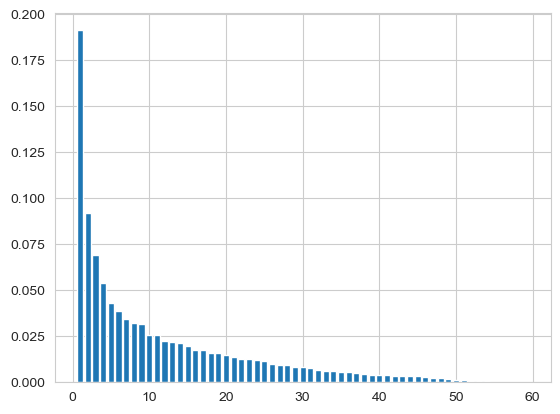

In [84]:
plt.bar(range(1,len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.show()

#### SCREE PLOT

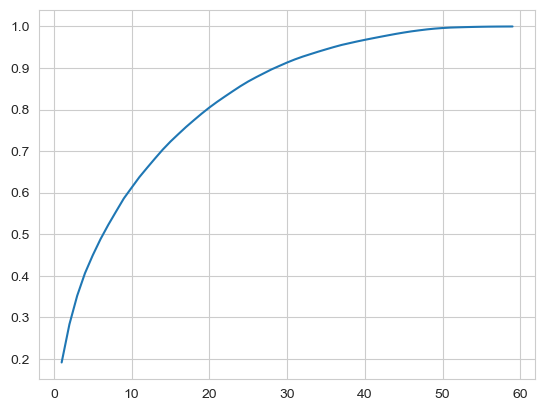

In [85]:
var_cumu = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1,len(var_cumu)+1), var_cumu)
plt.show()

#### PCA WITH 50 COMPONENTS

In [86]:
pca_final = PCA(n_components=50, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)
unseen_pca = pca_final.transform(unseen_scaled)

In [87]:
X_train_pca.shape, X_test_pca.shape, unseen_pca.shape

((55999, 50), (14000, 50), (30000, 50))

#### PLOTTING THE DATA

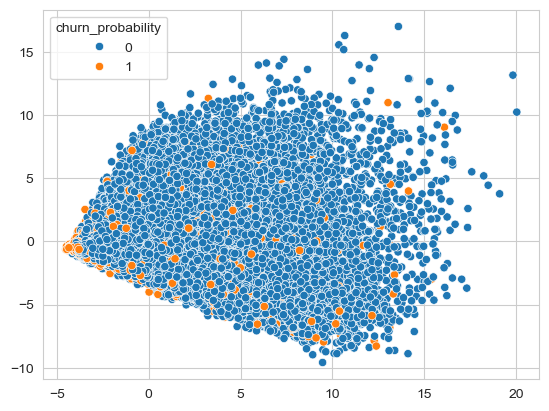

In [88]:
sns.scatterplot(x=X_train_pca[:,0], y=X_train_pca[:,1], hue=y_train)
plt.show()

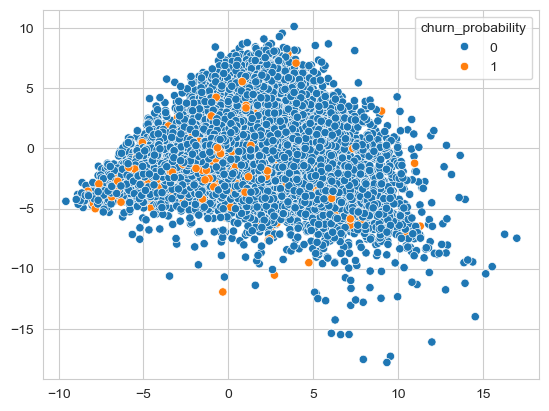

In [89]:
sns.scatterplot(x=X_train_pca[:,1], y=X_train_pca[:,2], hue=y_train)
plt.show()

# STEP #7 - MODEL SELECTION, MODEL BUILDING & MODEL EVALUATION

## 7.1 LOGISTIC REGRESSION

### 7.1.1 LOGISTIC REGRESSION WITHOUT PCA

For logistic regression we will be using `X_train_resampled` and `y_train_resampled` so that we can use RFE for feature selection instead of PCA.

#### BUILDING THE FIRST MODEL USING STATSMODELS

In [90]:
import statsmodels.api as sm

In [91]:
X_train_sm = sm.add_constant(X_train_resampled)
logm1 = sm.GLM(y_train_resampled, X_train_sm, family=sm.families.Binomial())
result = logm1.fit()

In [92]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:               100578
Model:                            GLM   Df Residuals:                   100518
Model Family:                Binomial   Df Model:                           59
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -39030.
Date:                Fri, 15 Nov 2024   Deviance:                       78061.
Time:                        12:21:50   Pearson chi2:                 1.29e+07
No. Iterations:                     8   Pseudo R-squ. (CS):             0.4567
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           1.6826      0.028     59.362      0.000       1.627       1.738
arpu_8                          0.0026      0.000     13.852      0.000       0.002       0.003
onnet_mou_8                    -0.0036      0.000    -15.014      0.000      -0.004      -0.003
offnet_mou_8                   -0.0032      0.000    -13.599      0.000      -0.004      -0.003
roam_ic_mou_8                  -0.0003      0.001     -0.451      0.652      -0.002       0.001
roam_og_mou_8                   0.0132      0.001     21.486      0.000       0.012       0.014
loc_og_mou_8                    0.0018      0.000      3.693      0.000       0.001       0.003
std_og_mou_8                    0.0046      0.000      9.825      0.000       0.004       0.006
isd_og_mou_8                   -0.0100      0.004     -2.773      0.006      -0.017      -0.003
spl_og_mou_8                   -0.0039      0.002     -2.414      0.016      -0.007      -0.001
og_others_8                    -0.5736      0.190     -3.014      0.003      -0.947      -0.201
total_og_mou_8                 -0.0029      0.000     -7.481      0.000      -0.004      -0.002
loc_ic_mou_8                   -0.0088      0.000    -19.670      0.000      -0.010      -0.008
std_ic_mou_8                   -0.0069      0.001    -11.633      0.000      -0.008      -0.006
total_ic_mou_8                  0.0008      0.000      1.889      0.059   -2.88e-05       0.002
spl_ic_mou_8                   -6.7453      0.184    -36.640      0.000      -7.106      -6.385
isd_ic_mou_8                   -0.0005      0.001     -0.542      0.588      -0.002       0.001
ic_others_8                    -0.0199      0.005     -3.829      0.000      -0.030      -0.010
total_rech_num_8               -0.1184      0.004    -31.988      0.000      -0.126      -0.111
total_rech_amt_8                0.0005      0.000      3.236      0.001       0.000       0.001
max_rech_amt_8                 -0.0027      0.000    -12.420      0.000      -0.003      -0.002
last_day_rch_amt_8             -0.0075      0.000    -34.101      0.000      -0.008      -0.007
vol_2g_mb_8                     0.0003      0.000      1.879      0.060   -1.26e-05       0.001
vol_3g_mb_8                     0.0010   7.61e-05     13.569      0.000       0.001       0.001
monthly_2g_8                   -2.6339      0.094    -27.928      0.000      -2.819      -2.449
sachet_2g_8                    -0.4544      0.019    -23.551      0.000      -0.492      -0.417
monthly_3g_8                   -1.8506      0.074    -24.987      0.000      -1.996      -1.705
sachet_3g_8                    -0.9355      0.056    -16.600      0.000      -1.046      -0.825
aon                            -0.0004   1.23e-05    -32.732      0.000      -0.000      -0.000
aug_vbc_3g 

##### Some features like `loc_og_mou_8`, `isd_og_mou_8`, `isd_ic_mou_8`, `avg_daily_usage_ratio`, `good_phase_std_ic_mou` etc. have very high p-values implying that these features are not significant. We will be performing Feature Selection using RFE and then perform Coarse Tuning using manual feature elimination (i.e. based on the p-values and VIFs).

#### AUTOMATIC FEATURE SELECTION USING RFE

In [93]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=42)

In [94]:
%%time
from sklearn.feature_selection import RFE

rfe = RFE(logreg, n_features_to_select=25)
rfe = rfe.fit(X_train_resampled, y_train_resampled)

CPU times: total: 2min 22s
Wall time: 52.7 s


In [95]:
pd.DataFrame({
    'Feature': X_train_resampled.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values(by='Ranking')

,Feature,Selected,Ranking
29,avg_daily_usage_ratio,True,1
28,aug_vbc_3g,True,1
26,sachet_3g_8,True,1
25,monthly_3g_8,True,1
24,sachet_2g_8,True,1
23,monthly_2g_8,True,1
42,good_phase_ic_others,True,1
21,vol_2g_mb_8,True,1
20,last_day_rch_amt_8,True,1
17,total_rech_num_8,True,1


In [96]:
selected_features = X_train_resampled.columns[rfe.support_]
selected_features

Index(['onnet_mou_8', 'offnet_mou_8', 'roam_og_mou_8', 'std_og_mou_8',
       'spl_og_mou_8', 'loc_ic_mou_8', 'std_ic_mou_8', 'spl_ic_mou_8',
       'ic_others_8', 'total_rech_num_8', 'last_day_rch_amt_8', 'vol_2g_mb_8',
       'monthly_2g_8', 'sachet_2g_8', 'monthly_3g_8', 'sachet_3g_8',
       'aug_vbc_3g', 'avg_daily_usage_ratio', 'arpu_std_dev',
       'good_phase_ic_others', 'good_phase_total_rech_num',
       'good_phase_monthly_2g', 'good_phase_total_rech_amt',
       'good_phase_spl_og_mou', 'good_phase_arpu'],
      dtype='object')

#### BUILDING MODEL WITH FEATURES SELECTED BY RFE

In [97]:
X_train_sm = sm.add_constant(X_train_resampled[selected_features])
logm2 = sm.GLM(y_train_resampled, X_train_sm, family=sm.families.Binomial())
result = logm2.fit()

In [98]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:               100578
Model:                            GLM   Df Residuals:                   100552
Model Family:                Binomial   Df Model:                           25
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -40609.
Date:                Fri, 15 Nov 2024   Deviance:                       81218.
Time:                        12:22:44   Pearson chi2:                 1.87e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4394
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.8219      0.019     44.315      0.000       0.786       0.858
onnet_mou_8                  -0.0037      0.000    -25.935      0.000      -0.004      -0.003
offnet_mou_8                 -0.0035      0.000    -26.531      0.000      -0.004      -0.003
roam_og_mou_8                 0.0171      0.000     43.333      0.000       0.016       0.018
std_og_mou_8                  0.0026      0.000     21.042      0.000       0.002       0.003
spl_og_mou_8                 -0.0076      0.001     -5.091      0.000      -0.011      -0.005
loc_ic_mou_8                 -0.0078      0.000    -52.446      0.000      -0.008      -0.008
std_ic_mou_8                 -0.0049      0.000    -18.737      0.000      -0.005      -0.004
spl_ic_mou_8                 -6.7080      0.180    -37.276      0.000      -7.061      -6.355
ic_others_8                  -0.0193      0.005     -3.813      0.000      -0.029      -0.009
total_rech_num_8             -0.0831      0.003    -27.082      0.000      -0.089      -0.077
last_day_rch_amt_8           -0.0079      0.000    -45.847      0.000      -0.008      -0.008
vol_2g_mb_8                   0.0001      0.000      1.028      0.304      -0.000       0.000
monthly_2g_8                 -2.1388      0.086    -24.882      0.000      -2.307      -1.970
sachet_2g_8                  -0.3349      0.016    -20.908      0.000      -0.366      -0.304
monthly_3g_8                 -0.8296      0.049    -16.829      0.000      -0.926      -0.733
sachet_3g_8                  -0.4932      0.047    -10.485      0.000      -0.585      -0.401
aug_vbc_3g                   -0.0006   9.96e-05     -5.557      0.000      -0.001      -0.000
avg_daily_usage_ratio         0.0816      0.007     12.262      0.000       0.069       0.095
arpu_std_dev                  0.0056      0.000     49.125      0.000       0.005       0.006
good_phase_ic_others          0.0050      0.006      0.906      0.365      -0.006       0.016
good_phase_total_rech_num     0.0226      0.003      7.239      0.000       0.016       0.029
good_phase_monthly_2g        -0.2636      0.060     -4.409      0.000      -0.381      -0.146
good_phase_total_rech_amt    -0.0015      0.000     -7.527      0.000      -0.002      -0.001
good_phase_spl_og_mou        -0.0017      0.002     -1.055      0.292      -0.005       0.001
good_phase_arpu               0.0020      0.000      8.831      0.000       0.002       0.002
=============================================================================================
"""

##### Many Features have a very high p-value and hence is not significant.  

In [99]:
# Getting Predictions on the train set
y_train_pred = result.predict(X_train_sm).values.reshape(-1)
y_train_pred_final = pd.DataFrame({'Actual_Churn':y_train_resampled.values, 'Predicted_Churn_Prob':y_train_pred})
y_train_pred_final['Predicted_Churn'] = y_train_pred_final.Predicted_Churn_Prob.map(lambda x: 1 if x > 0.5 else 0)
y_train_pred_final.head()

,Actual_Churn,Predicted_Churn_Prob,Predicted_Churn
0,0,0.017200,0
1,0,0.280508,0
2,0,0.649868,1
3,0,0.562540,1
4,1,0.918968,1


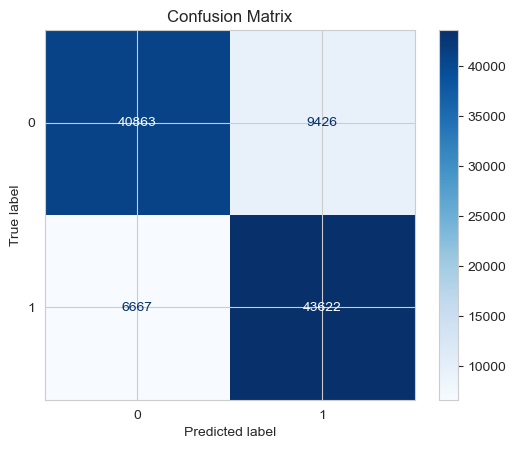


Accuracy : 0.8399948298832747


In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

# Confusion matrix 
confusion = confusion_matrix(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn )

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print()
# Overall accuracy.
print(f'Accuracy : {accuracy_score(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn)}')

In [101]:
# Classification report
print(classification_report(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn))

              precision    recall  f1-score   support

           0       0.86      0.81      0.84     50289
           1       0.82      0.87      0.84     50289

    accuracy                           0.84    100578
   macro avg       0.84      0.84      0.84    100578
weighted avg       0.84      0.84      0.84    100578



In [102]:
p_values = result.pvalues
selected_features = selected_features.drop([feature for feature in selected_features if p_values.get(feature, 1) > 0.1])
selected_features

Index(['onnet_mou_8', 'offnet_mou_8', 'roam_og_mou_8', 'std_og_mou_8',
       'spl_og_mou_8', 'loc_ic_mou_8', 'std_ic_mou_8', 'spl_ic_mou_8',
       'ic_others_8', 'total_rech_num_8', 'last_day_rch_amt_8', 'monthly_2g_8',
       'sachet_2g_8', 'monthly_3g_8', 'sachet_3g_8', 'aug_vbc_3g',
       'avg_daily_usage_ratio', 'arpu_std_dev', 'good_phase_total_rech_num',
       'good_phase_monthly_2g', 'good_phase_total_rech_amt',
       'good_phase_arpu'],
      dtype='object')

#### BUILDING MODEL AFTER ELIMINATING FEATURES WITH P-VALUES GREATER THAN 0.1

In [103]:
X_train_sm = sm.add_constant(X_train_resampled[selected_features])
logm3 = sm.GLM(y_train_resampled, X_train_sm, family=sm.families.Binomial())
result = logm3.fit()

In [104]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:               100578
Model:                            GLM   Df Residuals:                   100555
Model Family:                Binomial   Df Model:                           22
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -40610.
Date:                Fri, 15 Nov 2024   Deviance:                       81221.
Time:                        12:22:46   Pearson chi2:                 1.84e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4394
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.8222      0.019     44.362      0.000       0.786       0.858
onnet_mou_8                  -0.0037      0.000    -25.947      0.000      -0.004      -0.003
offnet_mou_8                 -0.0035      0.000    -26.543      0.000      -0.004      -0.003
roam_og_mou_8                 0.0170      0.000     43.326      0.000       0.016       0.018
std_og_mou_8                  0.0026      0.000     21.044      0.000       0.002       0.003
spl_og_mou_8                 -0.0082      0.001     -6.008      0.000      -0.011      -0.006
loc_ic_mou_8                 -0.0078      0.000    -52.458      0.000      -0.008      -0.008
std_ic_mou_8                 -0.0048      0.000    -18.722      0.000      -0.005      -0.004
spl_ic_mou_8                 -6.7069      0.180    -37.275      0.000      -7.060      -6.354
ic_others_8                  -0.0177      0.005     -3.745      0.000      -0.027      -0.008
total_rech_num_8             -0.0828      0.003    -27.116      0.000      -0.089      -0.077
last_day_rch_amt_8           -0.0079      0.000    -45.829      0.000      -0.008      -0.008
monthly_2g_8                 -2.1091      0.081    -26.046      0.000      -2.268      -1.950
sachet_2g_8                  -0.3285      0.015    -22.479      0.000      -0.357      -0.300
monthly_3g_8                 -0.8222      0.049    -16.879      0.000      -0.918      -0.727
sachet_3g_8                  -0.4894      0.047    -10.457      0.000      -0.581      -0.398
aug_vbc_3g                   -0.0006   9.96e-05     -5.578      0.000      -0.001      -0.000
avg_daily_usage_ratio         0.0810      0.007     12.218      0.000       0.068       0.094
arpu_std_dev                  0.0056      0.000     49.114      0.000       0.005       0.006
good_phase_total_rech_num     0.0220      0.003      7.190      0.000       0.016       0.028
good_phase_monthly_2g        -0.2574      0.059     -4.337      0.000      -0.374      -0.141
good_phase_total_rech_amt    -0.0015      0.000     -7.519      0.000      -0.002      -0.001
good_phase_arpu               0.0020      0.000      8.837      0.000       0.002       0.002
=============================================================================================
"""

##### Now, the p-values of all the features is less than 0.05 and hence the above features are significant.

In [105]:
# Getting Predictions on the train set
y_train_pred = result.predict(X_train_sm).values.reshape(-1)
y_train_pred_final = pd.DataFrame({'Actual_Churn':y_train_resampled.values, 'Predicted_Churn_Prob':y_train_pred})
y_train_pred_final['Predicted_Churn'] = y_train_pred_final.Predicted_Churn_Prob.map(lambda x: 1 if x > 0.5 else 0)
y_train_pred_final.head()

,Actual_Churn,Predicted_Churn_Prob,Predicted_Churn
0,0,0.017231,0
1,0,0.283698,0
2,0,0.648210,1
3,0,0.561840,1
4,1,0.918616,1


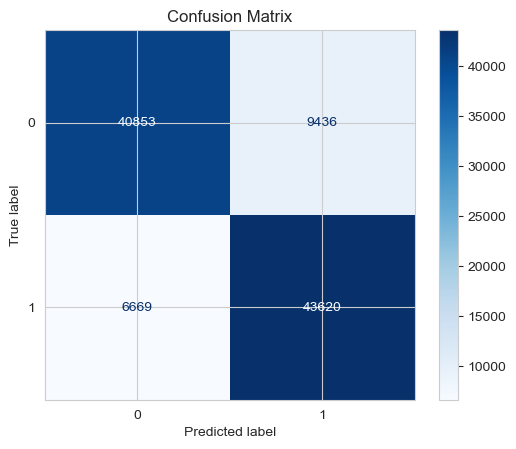


Accuracy : 0.8398755194973055


In [106]:
# Confusion matrix 
confusion = confusion_matrix(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn )

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print()
# Overall accuracy.
print(f'Accuracy : {accuracy_score(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn)}')

In [107]:
# Classification report
print(classification_report(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn))

              precision    recall  f1-score   support

           0       0.86      0.81      0.84     50289
           1       0.82      0.87      0.84     50289

    accuracy                           0.84    100578
   macro avg       0.84      0.84      0.84    100578
weighted avg       0.84      0.84      0.84    100578



##### Checking for the Mulitcollinearity in the features using VIFs.

In [108]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['Features'] = X_train_resampled[selected_features].columns
vif['VIF'] = [variance_inflation_factor(X_train_resampled[selected_features].values, i) for i in range(X_train_resampled[selected_features].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
21,good_phase_arpu,62.48
20,good_phase_total_rech_amt,61.08
18,good_phase_total_rech_num,6.98
3,std_og_mou_8,6.44
9,total_rech_num_8,5.86
1,offnet_mou_8,5.13
0,onnet_mou_8,4.21
17,arpu_std_dev,2.86
16,avg_daily_usage_ratio,2.64
5,loc_ic_mou_8,2.37


In [109]:
# Dropping features that have VIFs more than 10
selected_features = selected_features.drop(vif[vif['VIF'] > 10]['Features'].tolist())
selected_features

Index(['onnet_mou_8', 'offnet_mou_8', 'roam_og_mou_8', 'std_og_mou_8',
       'spl_og_mou_8', 'loc_ic_mou_8', 'std_ic_mou_8', 'spl_ic_mou_8',
       'ic_others_8', 'total_rech_num_8', 'last_day_rch_amt_8', 'monthly_2g_8',
       'sachet_2g_8', 'monthly_3g_8', 'sachet_3g_8', 'aug_vbc_3g',
       'avg_daily_usage_ratio', 'arpu_std_dev', 'good_phase_total_rech_num',
       'good_phase_monthly_2g'],
      dtype='object')

#### BUILDING MODEL AFTER ELIMINATING FEATURES WITH VIFs GREATER THAN 10

In [110]:
X_train_sm = sm.add_constant(X_train_resampled[selected_features])
logm4 = sm.GLM(y_train_resampled, X_train_sm, family=sm.families.Binomial())
result = logm4.fit()

In [111]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:               100578
Model:                            GLM   Df Residuals:                   100557
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -40652.
Date:                Fri, 15 Nov 2024   Deviance:                       81304.
Time:                        12:22:54   Pearson chi2:                 1.99e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4389
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.8294      0.018     45.056      0.000       0.793       0.866
onnet_mou_8                  -0.0037      0.000    -26.360      0.000      -0.004      -0.003
offnet_mou_8                 -0.0035      0.000    -27.123      0.000      -0.004      -0.003
roam_og_mou_8                 0.0172      0.000     44.091      0.000       0.016       0.018
std_og_mou_8                  0.0026      0.000     21.099      0.000       0.002       0.003
spl_og_mou_8                 -0.0083      0.001     -6.122      0.000      -0.011      -0.006
loc_ic_mou_8                 -0.0077      0.000    -52.397      0.000      -0.008      -0.007
std_ic_mou_8                 -0.0048      0.000    -18.517      0.000      -0.005      -0.004
spl_ic_mou_8                 -6.7418      0.180    -37.451      0.000      -7.095      -6.389
ic_others_8                  -0.0178      0.005     -3.770      0.000      -0.027      -0.009
total_rech_num_8             -0.0848      0.003    -29.300      0.000      -0.090      -0.079
last_day_rch_amt_8           -0.0078      0.000    -45.400      0.000      -0.008      -0.007
monthly_2g_8                 -2.1096      0.081    -26.073      0.000      -2.268      -1.951
sachet_2g_8                  -0.3273      0.015    -22.451      0.000      -0.356      -0.299
monthly_3g_8                 -0.8076      0.048    -16.712      0.000      -0.902      -0.713
sachet_3g_8                  -0.4839      0.047    -10.343      0.000      -0.576      -0.392
aug_vbc_3g                   -0.0005   9.91e-05     -5.200      0.000      -0.001      -0.000
avg_daily_usage_ratio         0.0875      0.006     13.508      0.000       0.075       0.100
arpu_std_dev                  0.0058      0.000     53.991      0.000       0.006       0.006
good_phase_total_rech_num     0.0274      0.003     10.819      0.000       0.022       0.032
good_phase_monthly_2g        -0.2457      0.059     -4.171      0.000      -0.361      -0.130
=============================================================================================
"""

##### All features have significant p-values. Checking for the Multicollinearity in the features using VIFs.

In [112]:
# Getting Predictions on the train set
y_train_pred = result.predict(X_train_sm).values.reshape(-1)
y_train_pred_final = pd.DataFrame({'Actual_Churn':y_train_resampled.values, 'Predicted_Churn_Prob':y_train_pred})
y_train_pred_final['Predicted_Churn'] = y_train_pred_final.Predicted_Churn_Prob.map(lambda x: 1 if x > 0.5 else 0)
y_train_pred_final.head()

,Actual_Churn,Predicted_Churn_Prob,Predicted_Churn
0,0,0.013946,0
1,0,0.290397,0
2,0,0.650566,1
3,0,0.575234,1
4,1,0.921016,1


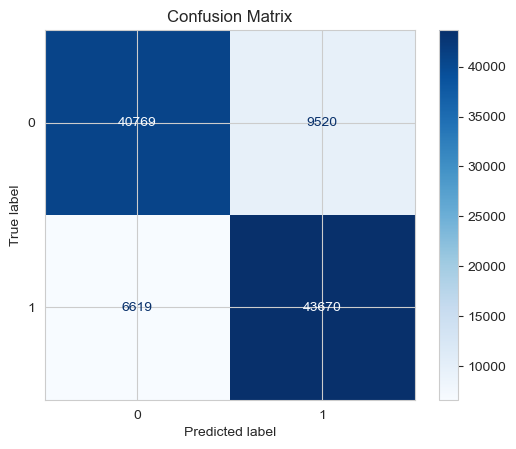


Accuracy : 0.8395374734037264


In [113]:
# Confusion matrix 
confusion = confusion_matrix(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print()
# Overall accuracy.
print(f'Accuracy : {accuracy_score(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn)}')

In [114]:
# Classification report
print(classification_report(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn))

              precision    recall  f1-score   support

           0       0.86      0.81      0.83     50289
           1       0.82      0.87      0.84     50289

    accuracy                           0.84    100578
   macro avg       0.84      0.84      0.84    100578
weighted avg       0.84      0.84      0.84    100578



In [115]:
vif = pd.DataFrame()
vif['Features'] = X_train_resampled[selected_features].columns
vif['VIF'] = [variance_inflation_factor(X_train_resampled[selected_features].values, i) for i in range(X_train_resampled[selected_features].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
3,std_og_mou_8,6.34
9,total_rech_num_8,5.27
18,good_phase_total_rech_num,4.82
1,offnet_mou_8,4.57
0,onnet_mou_8,3.91
16,avg_daily_usage_ratio,2.54
5,loc_ic_mou_8,2.35
17,arpu_std_dev,2.30
10,last_day_rch_amt_8,1.73
11,monthly_2g_8,1.59


In [116]:
# Dropping the feature that has VIF more than 5
features_with_vif_over_5 = vif[vif['VIF'] > 5]['Features'].tolist()
if features_with_vif_over_5:
    selected_features = selected_features.drop(features_with_vif_over_5)
selected_features

Index(['onnet_mou_8', 'offnet_mou_8', 'roam_og_mou_8', 'spl_og_mou_8',
       'loc_ic_mou_8', 'std_ic_mou_8', 'spl_ic_mou_8', 'ic_others_8',
       'last_day_rch_amt_8', 'monthly_2g_8', 'sachet_2g_8', 'monthly_3g_8',
       'sachet_3g_8', 'aug_vbc_3g', 'avg_daily_usage_ratio', 'arpu_std_dev',
       'good_phase_total_rech_num', 'good_phase_monthly_2g'],
      dtype='object')

#### BUILDING MODEL AFTER ELIMINATING FEATURES WITH VIFs GREATER THAN 5

In [117]:
X_train_sm = sm.add_constant(X_train_resampled[selected_features])
logm5 = sm.GLM(y_train_resampled, X_train_sm, family=sm.families.Binomial())
result = logm5.fit()

In [118]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      churn_probability   No. Observations:               100578
Model:                            GLM   Df Residuals:                   100559
Model Family:                Binomial   Df Model:                           18
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -41310.
Date:                Fri, 15 Nov 2024   Deviance:                       82621.
Time:                        12:23:00   Pearson chi2:                 3.86e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4315
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.7305      0.018     40.843      0.000       0.695       0.766
onnet_mou_8                  -0.0020   6.42e-05    -30.471      0.000      -0.002      -0.002
offnet_mou_8                 -0.0021   6.42e-05    -32.816      0.000      -0.002      -0.002
roam_og_mou_8                 0.0136      0.000     38.794      0.000       0.013       0.014
spl_og_mou_8                 -0.0158      0.001    -11.739      0.000      -0.018      -0.013
loc_ic_mou_8                 -0.0094      0.000    -68.680      0.000      -0.010      -0.009
std_ic_mou_8                 -0.0048      0.000    -18.639      0.000      -0.005      -0.004
spl_ic_mou_8                 -7.1906      0.181    -39.774      0.000      -7.545      -6.836
ic_others_8                  -0.0169      0.005     -3.569      0.000      -0.026      -0.008
last_day_rch_amt_8           -0.0077      0.000    -45.213      0.000      -0.008      -0.007
monthly_2g_8                 -2.1907      0.081    -27.108      0.000      -2.349      -2.032
sachet_2g_8                  -0.4043      0.014    -28.194      0.000      -0.432      -0.376
monthly_3g_8                 -0.8957      0.048    -18.576      0.000      -0.990      -0.801
sachet_3g_8                  -0.5604      0.047    -12.011      0.000      -0.652      -0.469
aug_vbc_3g                   -0.0005   9.91e-05     -5.541      0.000      -0.001      -0.000
avg_daily_usage_ratio         0.1320      0.006     20.882      0.000       0.120       0.144
arpu_std_dev                  0.0061      0.000     57.376      0.000       0.006       0.006
good_phase_total_rech_num    -0.0069      0.002     -3.228      0.001      -0.011      -0.003
good_phase_monthly_2g        -0.1879      0.059     -3.205      0.001      -0.303      -0.073
=============================================================================================
"""

##### All features have significant p-values. Checking for the Multicollinearity in the features using VIFs.

In [119]:
# Getting Predictions on the train set
y_train_pred = result.predict(X_train_sm).values.reshape(-1)
y_train_pred_final = pd.DataFrame({'Actual_Churn':y_train_resampled.values, 'Predicted_Churn_Prob':y_train_pred})
y_train_pred_final['Predicted_Churn'] = y_train_pred_final.Predicted_Churn_Prob.map(lambda x: 1 if x > 0.5 else 0)
y_train_pred_final.head()

,Actual_Churn,Predicted_Churn_Prob,Predicted_Churn
0,0,0.015694,0
1,0,0.212984,0
2,0,0.635929,1
3,0,0.515523,1
4,1,0.915237,1


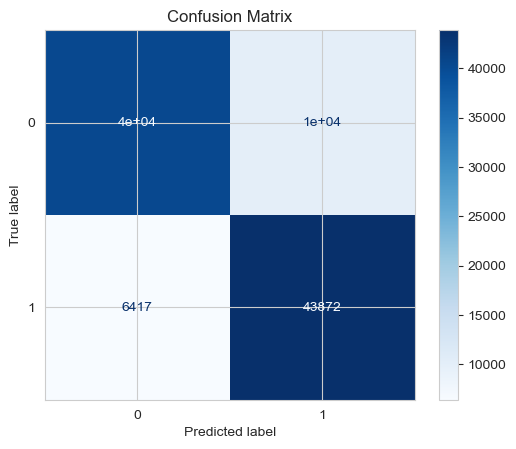


Accuracy : 0.8363658056433813


In [120]:
# Confusion matrix 
confusion = confusion_matrix(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print()
# Overall accuracy.
print(f'Accuracy : {accuracy_score(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn)}')

In [121]:
# Classification report
print(classification_report(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83     50289
           1       0.81      0.87      0.84     50289

    accuracy                           0.84    100578
   macro avg       0.84      0.84      0.84    100578
weighted avg       0.84      0.84      0.84    100578



In [122]:
vif = pd.DataFrame()
vif['Features'] = X_train_resampled[selected_features].columns
vif['VIF'] = [variance_inflation_factor(X_train_resampled[selected_features].values, i) for i in range(X_train_resampled[selected_features].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
16,good_phase_total_rech_num,3.21
14,avg_daily_usage_ratio,2.43
15,arpu_std_dev,2.28
1,offnet_mou_8,2.28
4,loc_ic_mou_8,1.81
0,onnet_mou_8,1.71
8,last_day_rch_amt_8,1.70
9,monthly_2g_8,1.59
17,good_phase_monthly_2g,1.59
13,aug_vbc_3g,1.58


##### Now, VIFs are less than 5 for all the features hence there is no multicollinearity between all the features.

#### PERFORMANCE METRICS OF THE FINAL MODEL

In [123]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [124]:
# Sensitivity, Specificity, False Positive Rate, Positive Predictive Rate, Negative Predictive Rate
print("Performance Metrics:")
print("---------------------")
print(f"{'Sensitivity (True Positive Rate):':<40} {TP / float(TP+FN)}")
print(f"{'Specificity (True Negative Rate):':<40} {TN / float(TN+FP)}")
print(f"{'False Positive Rate (FPR):':<40} {FP/ float(TN+FP)}")
print(f"{'Positive Predictive Rate (Precision):':<40} {TP/ float(TP+FP)}")
print(f"{'Negative Predictive Rate (NPV):':<40} {TN / float(TN+ FN)}")

Performance Metrics:
---------------------
Sensitivity (True Positive Rate):        0.872397542206049
Specificity (True Negative Rate):        0.8003340690807135
False Positive Rate (FPR):               0.19966593091928653
Positive Predictive Rate (Precision):    0.8137554949641088
Negative Predictive Rate (NPV):          0.8624879459980713


#### ROC CURVE

In [125]:
from sklearn.metrics import roc_curve, roc_auc_score

def draw_roc( actual, probs ):
    fpr, tpr, thresholds = roc_curve( actual, probs,
                                              drop_intermediate = False)
    auc_score = roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

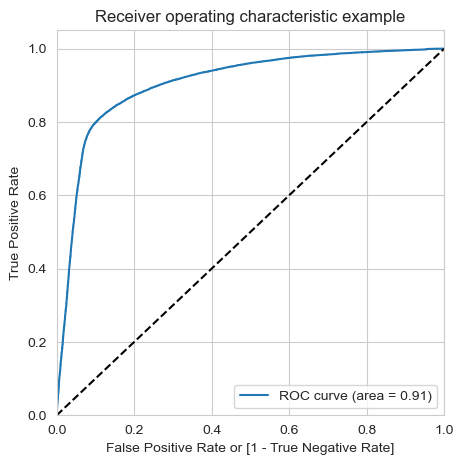

In [126]:
draw_roc(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn_Prob)

#### OPTIMAL THRESHOLD

In [127]:
# Create columns with different probability cutoffs 
numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    y_train_pred_final[i]= y_train_pred_final.Predicted_Churn_Prob.map(lambda x: 1 if x > i else 0)
y_train_pred_final.head()

,Actual_Churn,Predicted_Churn_Prob,Predicted_Churn,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,0,0.015694,0,1,0,0,0,0,0,0,0,0,0
1,0,0.212984,0,1,1,1,0,0,0,0,0,0,0
2,0,0.635929,1,1,1,1,1,1,1,1,0,0,0
3,0,0.515523,1,1,1,1,1,1,1,0,0,0,0
4,1,0.915237,1,1,1,1,1,1,1,1,1,1,1


In [128]:
# Accuracy, Sensitivity and Specificity for various probability cutoffs.
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = confusion_matrix(y_train_pred_final.Actual_Churn, y_train_pred_final[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1
    
    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i, accuracy, sensi, speci]

cutoff_df

,prob,accuracy,sensi,speci
0.0,0.0,0.500000,1.000000,0.000000
0.1,0.1,0.691931,0.973533,0.410328
0.2,0.2,0.746943,0.952455,0.541431
0.3,0.3,0.785609,0.930184,0.641035
0.4,0.4,0.815059,0.904472,0.725646
0.5,0.5,0.836366,0.872398,0.800334
0.6,0.6,0.848267,0.828969,0.867565
0.7,0.7,0.842828,0.765833,0.919823
0.8,0.8,0.724135,0.488636,0.959633
0.9,0.9,0.601135,0.219491,0.982780


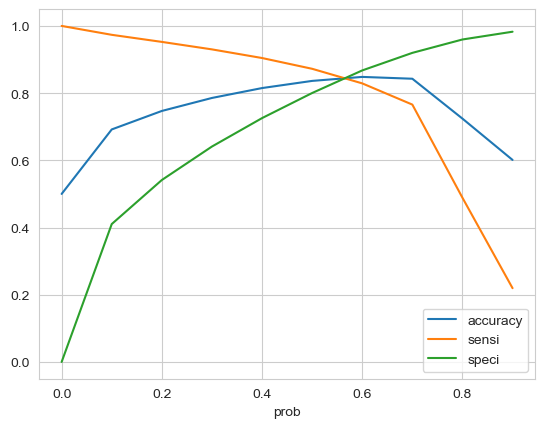

In [129]:
# Plotting accuracy sensitivity and specificity for various probabilities.
cutoff_df.plot.line(x='prob', y=['accuracy', 'sensi', 'speci'])
plt.show()

##### From the above graph, 0.55 is the Optimum Threshold for the cutoff.

In [130]:
y_train_pred_final['Final_Predicted_Churn'] = y_train_pred_final.Predicted_Churn_Prob.map(lambda x: 1 if x > 0.55 else 0)
y_train_pred_final.head()

,Actual_Churn,Predicted_Churn_Prob,Predicted_Churn,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,Final_Predicted_Churn
0,0,0.015694,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0.212984,0,1,1,1,0,0,0,0,0,0,0,0
2,0,0.635929,1,1,1,1,1,1,1,1,0,0,0,1
3,0,0.515523,1,1,1,1,1,1,1,0,0,0,0,0
4,1,0.915237,1,1,1,1,1,1,1,1,1,1,1,1


In [131]:
# Final Accuracy.
print(f'Accuracy : {accuracy_score(y_train_pred_final.Actual_Churn, y_train_pred_final.Final_Predicted_Churn)}')

Accuracy : 0.8434647736085427


#### PRECISION - RECALL TRADEOFF

In [132]:
from sklearn.metrics import precision_score, recall_score, precision_recall_curve

print(f"{'Precision Score:':<20} {precision_score(y_train_pred_final.Actual_Churn, y_train_pred_final.Final_Predicted_Churn)}")
print(f"{'Recall Score:':<20} {recall_score(y_train_pred_final.Actual_Churn, y_train_pred_final.Final_Predicted_Churn)}")

Precision Score:     0.8380864765409384
Recall Score:        0.8514187993398159


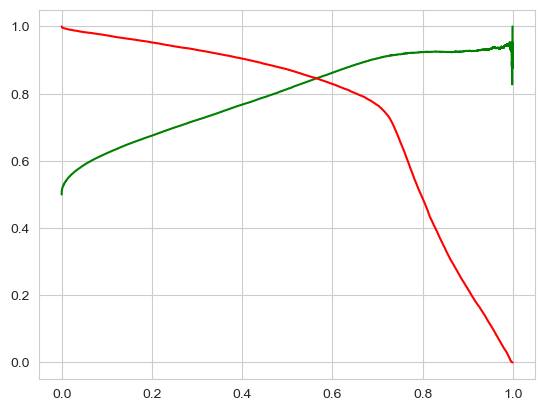

In [133]:
p, r, thresholds = precision_recall_curve(y_train_pred_final.Actual_Churn, y_train_pred_final.Predicted_Churn_Prob)

plt.plot(thresholds, p[:-1], 'g-')
plt.plot(thresholds, r[:-1], 'r-')
plt.show()

##### Optimum Point is again ~0.56

#### MAKING PREDICTIONS ON THE TEST SET

In [134]:
selected_features.shape

(18,)

In [135]:
X_test_sm = sm.add_constant(X_test[selected_features])

# Predict on test data

y_test_pred = result.predict(X_test_sm)
y_test_pred_final = pd.DataFrame({'Actual_Churn':y_test.values, 'Predicted_Churn_Prob':y_test_pred})
y_test_pred_final['Predicted_Churn'] = y_test_pred_final.Predicted_Churn_Prob.map(lambda x: 1 if x > 0.56 else 0)
y_test_pred_final.head()

,Actual_Churn,Predicted_Churn_Prob,Predicted_Churn
id,,,
57621,0,0.785036,1
39559,0,0.003227,0
41415,0,0.246378,0
47731,0,0.377731,0
64801,0,0.000175,0


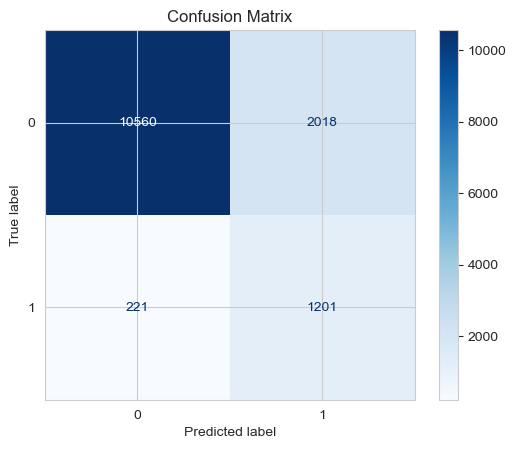


Accuracy Score:      0.8400714285714286
Precision Score:     0.3730972351662007
Recall Score:        0.8445850914205345


In [136]:
# Confusion matrix 
confusion = confusion_matrix(y_test_pred_final.Actual_Churn, y_test_pred_final.Predicted_Churn)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print()
# Overall accuracy.
print(f"{'Accuracy Score:':<20} {accuracy_score(y_test_pred_final.Actual_Churn, y_test_pred_final.Predicted_Churn)}")
print(f"{'Precision Score:':<20} {precision_score(y_test_pred_final.Actual_Churn, y_test_pred_final.Predicted_Churn)}")
print(f"{'Recall Score:':<20} {recall_score(y_test_pred_final.Actual_Churn, y_test_pred_final.Predicted_Churn)}")

In [137]:
# Classification report
print(classification_report(y_test_pred_final.Actual_Churn, y_test_pred_final.Predicted_Churn))

              precision    recall  f1-score   support

           0       0.98      0.84      0.90     12578
           1       0.37      0.84      0.52      1422

    accuracy                           0.84     14000
   macro avg       0.68      0.84      0.71     14000
weighted avg       0.92      0.84      0.86     14000



In [138]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [139]:
# Sensitivity, Specificity, False Positive Rate, Positive Predictive Rate, Negative Predictive Rate
print("Performance Metrics:")
print("---------------------")
print(f"{'Sensitivity (True Positive Rate):':<40} {TP / float(TP+FN)}")
print(f"{'Specificity (True Negative Rate):':<40} {TN / float(TN+FP)}")
print(f"{'False Positive Rate (FPR):':<40} {FP/ float(TN+FP)}")
print(f"{'Positive Predictive Rate (Precision):':<40} {TP/ float(TP+FP)}")
print(f"{'Negative Predictive Rate (NPV):':<40} {TN / float(TN+ FN)}")

Performance Metrics:
---------------------
Sensitivity (True Positive Rate):        0.8445850914205345
Specificity (True Negative Rate):        0.8395611384957863
False Positive Rate (FPR):               0.16043886150421371
Positive Predictive Rate (Precision):    0.3730972351662007
Negative Predictive Rate (NPV):          0.9795009739356275


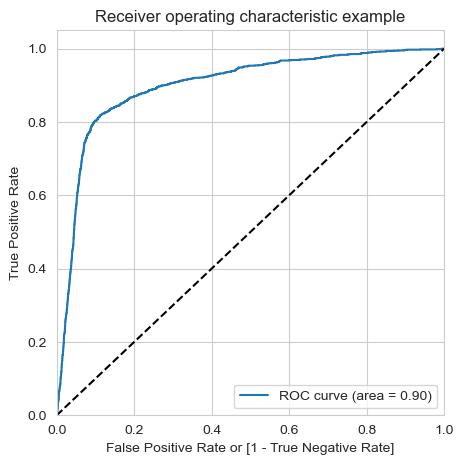

In [140]:
# ROC Curve
draw_roc(y_test_pred_final.Actual_Churn, y_test_pred_final.Predicted_Churn_Prob)

#### SUMMARY

In [141]:
print(f"{'Accuracy Score for Train Set:':<40} {accuracy_score(y_train_pred_final.Actual_Churn, y_train_pred_final.Final_Predicted_Churn)}")
print(f"{'Accuracy Score for Test Set:':<40} {accuracy_score(y_test_pred_final.Actual_Churn, y_test_pred_final.Predicted_Churn)}")

Accuracy Score for Train Set:            0.8434647736085427
Accuracy Score for Test Set:             0.8400714285714286


In [142]:
print('Important Predictors of Churn:')
print('--------------------------------------')
print(abs(result.params).sort_values(ascending=False))

Important Predictors of Churn:
--------------------------------------
spl_ic_mou_8                 7.190589
monthly_2g_8                 2.190729
monthly_3g_8                 0.895744
const                        0.730529
sachet_3g_8                  0.560434
sachet_2g_8                  0.404341
good_phase_monthly_2g        0.187879
avg_daily_usage_ratio        0.131993
ic_others_8                  0.016904
spl_og_mou_8                 0.015758
roam_og_mou_8                0.013631
loc_ic_mou_8                 0.009377
last_day_rch_amt_8           0.007740
good_phase_total_rech_num    0.006921
arpu_std_dev                 0.006085
std_ic_mou_8                 0.004815
offnet_mou_8                 0.002108
onnet_mou_8                  0.001957
aug_vbc_3g                   0.000549
dtype: float64


##### We got almost same percentage (~84%) for both train and test sets, which implies that the model is neither overfitted nor underfitted and is good at predicting unseen data.

### 7.1.2 LOGISTIC REGRESSION WITH PCA

In [143]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_pca, y_train)

LogisticRegression(random_state=42)

In [144]:
lr.score(X_train_pca, y_train)

0.9158556402792907

In [145]:
lr.score(X_test_pca, y_test)

0.9117857142857143

In [146]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Creating KFold object with 5 splits
folds = KFold(n_splits=5, shuffle=True, random_state=42)

# Specify params
params = {"C": [0.01, 0.1, 1, 10, 100, 1000]}

# Specifing score as recall as we are more focused on acheiving the higher sensitivity than the accuracy
lr_cv = GridSearchCV(estimator = LogisticRegression(),
                        param_grid = params, 
                        scoring= 'recall', 
                        cv = folds, 
                        verbose = 1,
                        return_train_score=True) 

# Fit the model
lr_cv.fit(X_train_pca, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000]},
             return_train_score=True, scoring='recall', verbose=1)

In [147]:
pd.DataFrame(lr_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.162469,0.004044,0.012601,0.001021,0.01,{'C': 0.01},0.263204,0.300523,0.287346,0.276486,0.285714,0.282655,0.012386,6,0.281373,0.294388,0.279309,0.291053,0.280602,0.285345,0.006149
1,0.199556,0.019278,0.012679,0.002138,0.10,{'C': 0.1},0.294894,0.339721,0.318981,0.307494,0.326531,0.317524,0.015419,5,0.309357,0.330338,0.314523,0.323148,0.308750,0.317223,0.008343
2,0.215336,0.011007,0.011958,0.002137,1.00,{'C': 1},0.298415,0.346690,0.322496,0.315245,0.329193,0.322408,0.015891,4,0.313948,0.334283,0.317367,0.327545,0.312677,0.321164,0.008383
3,0.201492,0.008899,0.013195,0.001471,10.00,{'C': 10},0.298415,0.346690,0.322496,0.316107,0.330080,0.322758,0.015895,1,0.314167,0.335160,0.317804,0.328424,0.314423,0.321996,0.008376
4,0.209927,0.010384,0.017191,0.011467,100.00,{'C': 100},0.298415,0.346690,0.322496,0.316107,0.329193,0.322580,0.015817,2,0.314386,0.335160,0.317367,0.328644,0.313332,0.321778,0.008622
5,0.213190,0.012403,0.011997,0.002099,1000.00,{'C': 1000},0.298415,0.346690,0.322496,0.316107,0.329193,0.322580,0.015817,2,0.314386,0.335160,0.317367,0.328644,0.313332,0.321778,0.008622


In [148]:
print("Best parameters found: ", lr_cv.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(lr_cv.best_score_))

# Get the best model
lr_best = lr_cv.best_estimator_
print("Best Model:", lr_best)

Best parameters found:  {'C': 10}
Best cross-validation accuracy: 0.32
Best Model: LogisticRegression(C=10)


In [149]:
# Accuracy for the Train Set
y_train_pred = lr_best.predict(X_train_pca)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9158199253558099

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     50289
           1       0.69      0.32      0.44      5710

    accuracy                           0.92     55999
   macro avg       0.81      0.65      0.70     55999
weighted avg       0.90      0.92      0.90     55999



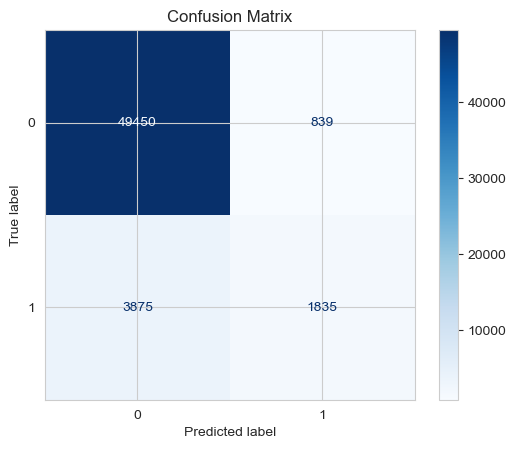

In [150]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [151]:
# Accuracy for the Test Set
y_test_pred = lr_best.predict(X_test_pca)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9118571428571428

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     12578
           1       0.63      0.32      0.42      1422

    accuracy                           0.91     14000
   macro avg       0.78      0.65      0.69     14000
weighted avg       0.90      0.91      0.90     14000



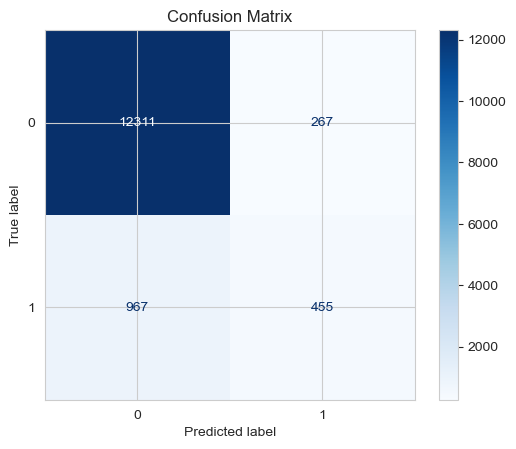

In [152]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

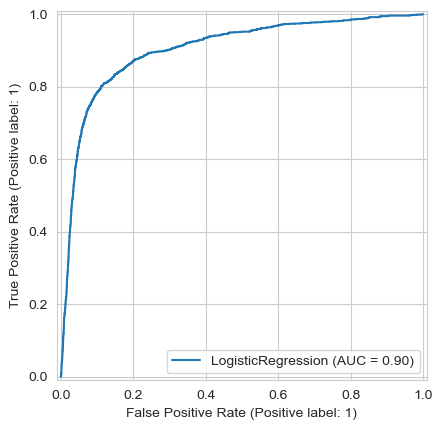

In [153]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr_best, X_test_pca, y_test)
plt.show()

In [154]:
print(f"{'Precision Score:':<20} {precision_score(y_test, y_test_pred)}")
print(f"{'Recall Score:':<20} {recall_score(y_test, y_test_pred)}")

Precision Score:     0.6301939058171745
Recall Score:        0.319971870604782


In [155]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [156]:
# Sensitivity, Specificity, False Positive Rate, Positive Predictive Rate, Negative Predictive Rate
print("Performance Metrics:")
print("---------------------")
print(f"{'Sensitivity (True Positive Rate):':<40} {TP / float(TP+FN)}")
print(f"{'Specificity (True Negative Rate):':<40} {TN / float(TN+FP)}")
print(f"{'False Positive Rate (FPR):':<40} {FP/ float(TN+FP)}")
print(f"{'Positive Predictive Rate (Precision):':<40} {TP/ float(TP+FP)}")
print(f"{'Negative Predictive Rate (NPV):':<40} {TN / float(TN+ FN)}")

Performance Metrics:
---------------------
Sensitivity (True Positive Rate):        0.319971870604782
Specificity (True Negative Rate):        0.9787724598505326
False Positive Rate (FPR):               0.021227540149467324
Positive Predictive Rate (Precision):    0.6301939058171745
Negative Predictive Rate (NPV):          0.9271727669829793


#### SUMMARY

In [157]:
print(f"{'Accuracy Score for Train Set:':<40} {accuracy_score(y_train, y_train_pred)}")
print(f"{'Accuracy Score for Test Set:':<40} {accuracy_score(y_test, y_test_pred)}")

Accuracy Score for Train Set:            0.9158199253558099
Accuracy Score for Test Set:             0.9118571428571428


##### We got an accuracy of ~91.6% for the train set and ~91.2% for the test set, which implies that the model is neither overfitted nor underfitted and is good at predicting unseen data.

## 7.2 DECISION TREE

### 7.2.1 DECISION TREE WITH PCA

#### BUILDING THE FIRST MODEL

In [158]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initial Decision Tree classifier
dt1 = DecisionTreeClassifier(random_state=42, max_depth=10)
dt1.fit(X_train_pca, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [159]:
# # Visualize the tree
# plt.figure(figsize=(24, 16))
# plot_tree(dt1, feature_names=pd.DataFrame(X_train_pca).columns, 
#           class_names=['Not Churned', 'Churned'], 
#           filled=True, rounded=True)
# plt.title("Decision Tree Visualization")
# plt.show()

In [160]:
# Accuracy for the Train Set
y_train_pred = dt1.predict(X_train_pca)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9411775210271612

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     50289
           1       0.75      0.63      0.69      5710

    accuracy                           0.94     55999
   macro avg       0.86      0.80      0.83     55999
weighted avg       0.94      0.94      0.94     55999



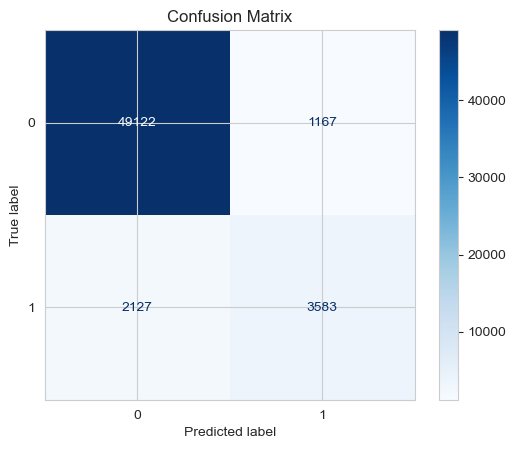

In [161]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)
 
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [162]:
# Accuracy for the Test Set
y_test_pred = dt1.predict(X_test_pca)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9028571428571428

              precision    recall  f1-score   support

           0       0.94      0.95      0.95     12578
           1       0.52      0.48      0.50      1422

    accuracy                           0.90     14000
   macro avg       0.73      0.72      0.72     14000
weighted avg       0.90      0.90      0.90     14000



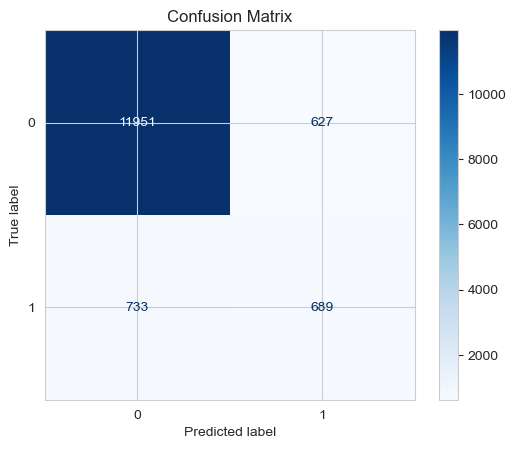

In [163]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

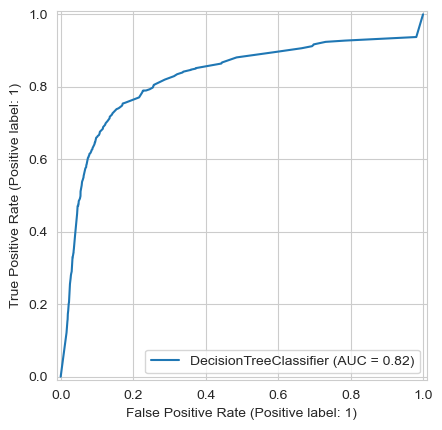

In [164]:
# ROC
RocCurveDisplay.from_estimator(dt1, X_test_pca, y_test)
plt.show()

#### HYPERPARAMETER TUNING USING GRIDSEARCHCV

In [165]:
%%time
dt2 = DecisionTreeClassifier(random_state=42)

# Define hyperparameters and ranges to search
params = {
    'max_depth': [10, 20, 30, 40],
    'min_samples_leaf': [10, 20, 50, 100, 250],
}

grid_search_dt = GridSearchCV(estimator=dt2,
                           param_grid=params,
                           cv=4,
                           n_jobs=-1, verbose=1, scoring="accuracy")

# Perform gridsearch
grid_search_dt.fit(X_train_pca, y_train)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
CPU times: total: 6.47 s
Wall time: 1min 57s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, 40],
                         'min_samples_leaf': [10, 20, 50, 100, 250]},
             scoring='accuracy', verbose=1)

In [166]:
print("Best parameters found: ", grid_search_dt.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search_dt.best_score_))

dt_best = grid_search_dt.best_estimator_
print("Best Model:", dt_best)

Best parameters found:  {'max_depth': 10, 'min_samples_leaf': 50}
Best cross-validation accuracy: 0.91
Best Model: DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=42)


In [167]:
# Accuracy for the Train Set
y_train_pred = dt_best.predict(X_train_pca)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9251058054608118

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     50289
           1       0.68      0.51      0.58      5710

    accuracy                           0.93     55999
   macro avg       0.81      0.74      0.77     55999
weighted avg       0.92      0.93      0.92     55999



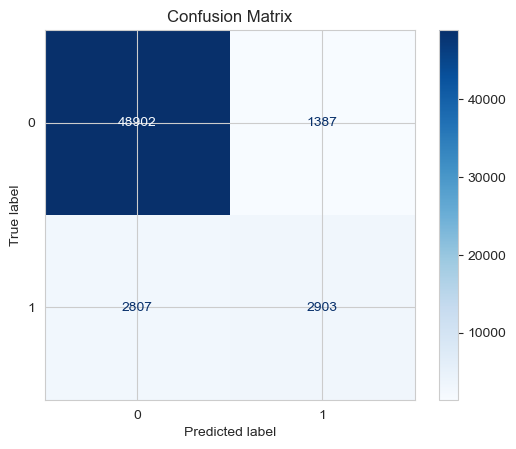

In [168]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [169]:
# Accuracy for the Test Set
y_test_pred = dt_best.predict(X_test_pca)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9121428571428571

              precision    recall  f1-score   support

           0       0.94      0.96      0.95     12578
           1       0.59      0.45      0.51      1422

    accuracy                           0.91     14000
   macro avg       0.76      0.71      0.73     14000
weighted avg       0.90      0.91      0.91     14000



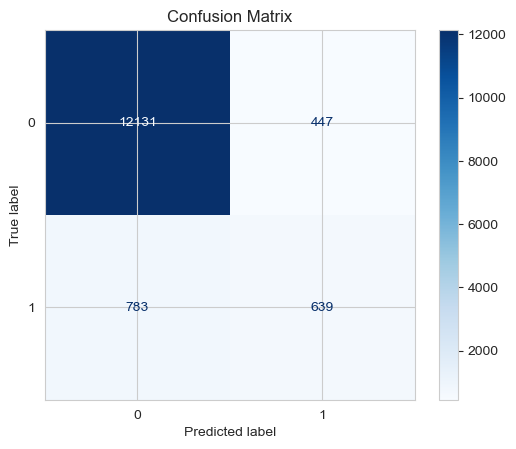

In [170]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

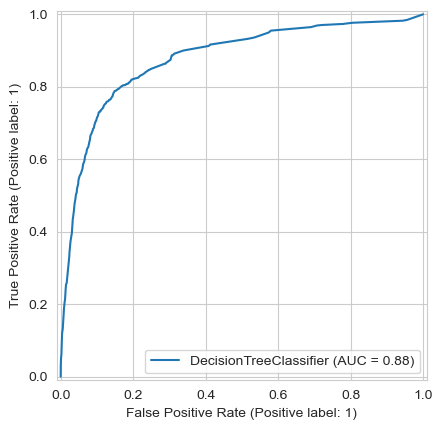

In [171]:
# ROC
RocCurveDisplay.from_estimator(dt_best, X_test_pca, y_test)
plt.show()

In [172]:
print(f"{'Precision Score:':<20} {precision_score(y_test, y_test_pred)}")
print(f"{'Recall Score:':<20} {recall_score(y_test, y_test_pred)}")

Precision Score:     0.5883977900552486
Recall Score:        0.44936708860759494


In [173]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [174]:
# Sensitivity, Specificity, False Positive Rate, Positive Predictive Rate, Negative Predictive Rate
print("Performance Metrics:")
print("---------------------")
print(f"{'Sensitivity (True Positive Rate):':<40} {TP / float(TP+FN)}")
print(f"{'Specificity (True Negative Rate):':<40} {TN / float(TN+FP)}")
print(f"{'False Positive Rate (FPR):':<40} {FP/ float(TN+FP)}")
print(f"{'Positive Predictive Rate (Precision):':<40} {TP/ float(TP+FP)}")
print(f"{'Negative Predictive Rate (NPV):':<40} {TN / float(TN+ FN)}")

Performance Metrics:
---------------------
Sensitivity (True Positive Rate):        0.44936708860759494
Specificity (True Negative Rate):        0.9644617586261727
False Positive Rate (FPR):               0.035538241373827315
Positive Predictive Rate (Precision):    0.5883977900552486
Negative Predictive Rate (NPV):          0.9393681276134428


#### SUMMARY

In [175]:
print(f"{'Accuracy Score for Train Set:':<40} {accuracy_score(y_train, y_train_pred)}")
print(f"{'Accuracy Score for Test Set:':<40} {accuracy_score(y_test, y_test_pred)}")

Accuracy Score for Train Set:            0.9251058054608118
Accuracy Score for Test Set:             0.9121428571428571


##### We got an accuracy of ~92.5% for the train set and ~91.2% for the test set, which implies that the model is neither overfitted nor underfitted and is good at predicting unseen data.

### 7.2.2 DECISION TREE WITHOUT PCA

#### BUILDING THE FIRST MODEL

In [176]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initial Decision Tree classifier
dt3 = DecisionTreeClassifier(random_state=42, max_depth=10)
dt3.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [177]:
# # Visualize the tree
# plt.figure(figsize=(24, 16))
# plot_tree(dt3, feature_names=pd.DataFrame(X_train_scaled).columns, 
#           class_names=['Not Churned', 'Churned'], 
#           filled=True, rounded=True)
# plt.title("Decision Tree Visualization")
# plt.show()

In [178]:
# Accuracy for the Train Set
y_train_pred = dt3.predict(X_train_scaled)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9559456418864622

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     50289
           1       0.82      0.73      0.77      5710

    accuracy                           0.96     55999
   macro avg       0.89      0.86      0.87     55999
weighted avg       0.95      0.96      0.95     55999



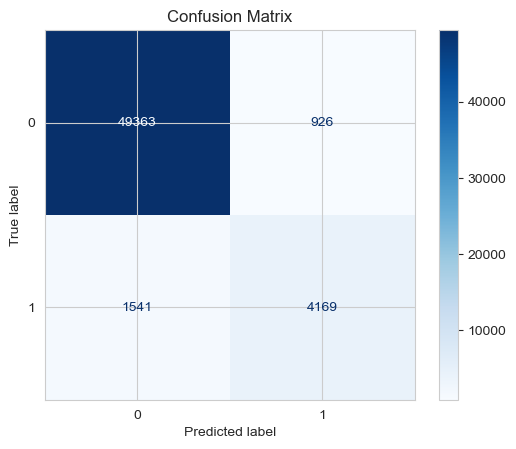

In [179]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)
 
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [180]:
# Accuracy for the Test Set
y_test_pred = dt3.predict(X_test_scaled)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9342857142857143

              precision    recall  f1-score   support

           0       0.96      0.97      0.96     12578
           1       0.69      0.65      0.67      1422

    accuracy                           0.93     14000
   macro avg       0.82      0.81      0.82     14000
weighted avg       0.93      0.93      0.93     14000



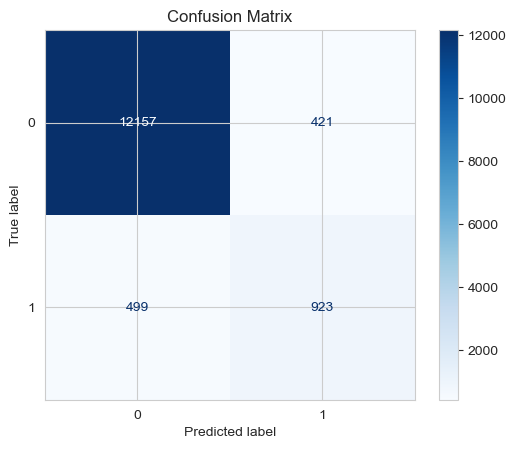

In [181]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

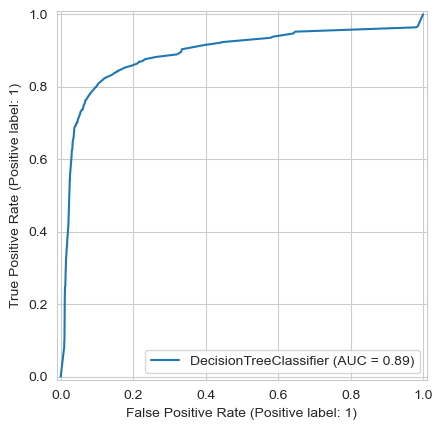

In [182]:
# ROC
RocCurveDisplay.from_estimator(dt3, X_test_scaled, y_test)
plt.show()

#### HYPERPARAMETER TUNING USING GRIDSEARCHCV

In [183]:
%%time
dt4 = DecisionTreeClassifier(random_state=42)

# Define hyperparameters and ranges to search
params = {
    'max_depth': [10, 20, 30, 40],
    'min_samples_leaf': [10, 20, 50, 100, 250],
}

grid_search_dt_1 = GridSearchCV(estimator=dt4,
                           param_grid=params,
                           cv=4,
                           n_jobs=-1, verbose=1, scoring="accuracy")

# Perform gridsearch
grid_search_dt_1.fit(X_train_scaled, y_train)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
CPU times: total: 3.72 s
Wall time: 1min 3s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, 40],
                         'min_samples_leaf': [10, 20, 50, 100, 250]},
             scoring='accuracy', verbose=1)

In [184]:
print("Best parameters found: ", grid_search_dt_1.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search_dt_1.best_score_))

dt_best_1 = grid_search_dt_1.best_estimator_
print("Best Model:", dt_best_1)

Best parameters found:  {'max_depth': 10, 'min_samples_leaf': 50}
Best cross-validation accuracy: 0.94
Best Model: DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=42)


In [185]:
# Accuracy for the Train Set
y_train_pred = dt_best_1.predict(X_train_scaled)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9442132895230272

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     50289
           1       0.78      0.63      0.70      5710

    accuracy                           0.94     55999
   macro avg       0.87      0.81      0.83     55999
weighted avg       0.94      0.94      0.94     55999



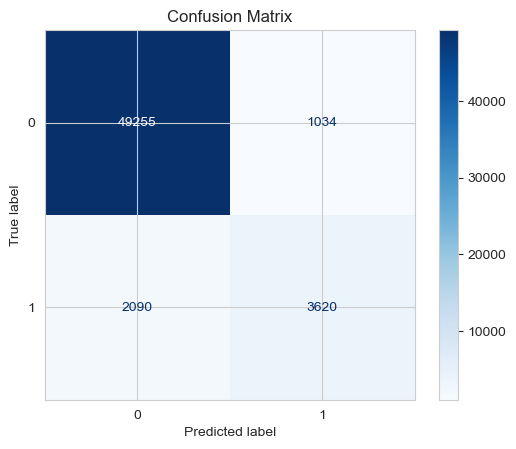

In [186]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [187]:
# Accuracy for the Test Set
y_test_pred = dt_best_1.predict(X_test_scaled)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9415

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     12578
           1       0.75      0.63      0.69      1422

    accuracy                           0.94     14000
   macro avg       0.86      0.80      0.83     14000
weighted avg       0.94      0.94      0.94     14000



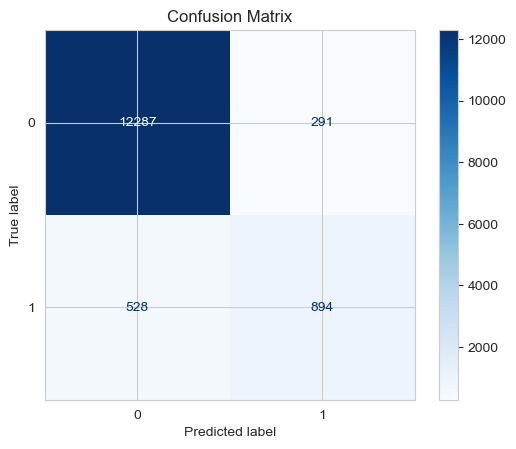

In [188]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

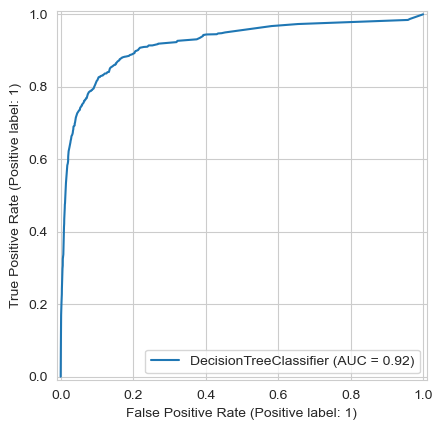

In [189]:
# ROC
RocCurveDisplay.from_estimator(dt_best_1, X_test_scaled, y_test)
plt.show()

In [190]:
print(f"{'Precision Score:':<20} {precision_score(y_test, y_test_pred)}")
print(f"{'Recall Score:':<20} {recall_score(y_test, y_test_pred)}")

Precision Score:     0.7544303797468355
Recall Score:        0.6286919831223629


In [191]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [192]:
# Sensitivity, Specificity, False Positive Rate, Positive Predictive Rate, Negative Predictive Rate
print("Performance Metrics:")
print("---------------------")
print(f"{'Sensitivity (True Positive Rate):':<40} {TP / float(TP+FN)}")
print(f"{'Specificity (True Negative Rate):':<40} {TN / float(TN+FP)}")
print(f"{'False Positive Rate (FPR):':<40} {FP/ float(TN+FP)}")
print(f"{'Positive Predictive Rate (Precision):':<40} {TP/ float(TP+FP)}")
print(f"{'Negative Predictive Rate (NPV):':<40} {TN / float(TN+ FN)}")

Performance Metrics:
---------------------
Sensitivity (True Positive Rate):        0.6286919831223629
Specificity (True Negative Rate):        0.9768643663539514
False Positive Rate (FPR):               0.023135633646048655
Positive Predictive Rate (Precision):    0.7544303797468355
Negative Predictive Rate (NPV):          0.9587982832618026


#### SUMMARY

In [193]:
print(f"{'Accuracy Score for Train Set:':<40} {accuracy_score(y_train, y_train_pred)}")
print(f"{'Accuracy Score for Test Set:':<40} {accuracy_score(y_test, y_test_pred)}")

Accuracy Score for Train Set:            0.9442132895230272
Accuracy Score for Test Set:             0.9415


##### We got an accuracy of ~94.4% for the train set and ~94.2% for the test set, which implies that the model is neither overfitted nor underfitted and is good at predicting unseen data.

## 7.3 RANDOM FOREST

### 7.3.1 RANDOM FOREST WITH PCA

In [194]:
from sklearn.ensemble import RandomForestClassifier

# Initial Random Forest Classifier
rf1 = RandomForestClassifier(n_estimators=15, max_depth=10, max_features=10, oob_score=True, random_state=42)
rf1.fit(X_train_pca, y_train)

RandomForestClassifier(max_depth=10, max_features=10, n_estimators=15,
                       oob_score=True, random_state=42)

In [195]:
# Accuracy for the Train Set
y_train_pred = rf1.predict(X_train_pca)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9370703048268719

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     50289
           1       0.84      0.47      0.61      5710

    accuracy                           0.94     55999
   macro avg       0.89      0.73      0.79     55999
weighted avg       0.93      0.94      0.93     55999



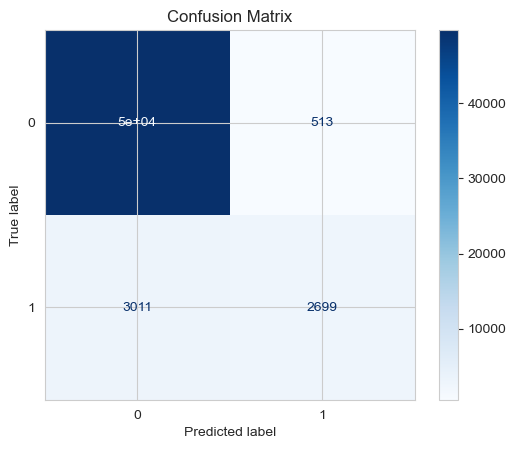

In [196]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)
 
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [197]:
# Accuracy for the Test Set
y_test_pred = rf1.predict(X_test_pca)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9165

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     12578
           1       0.67      0.34      0.46      1422

    accuracy                           0.92     14000
   macro avg       0.80      0.66      0.71     14000
weighted avg       0.90      0.92      0.90     14000



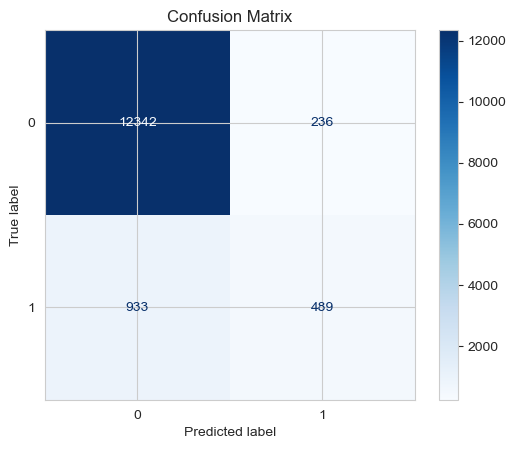

In [198]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

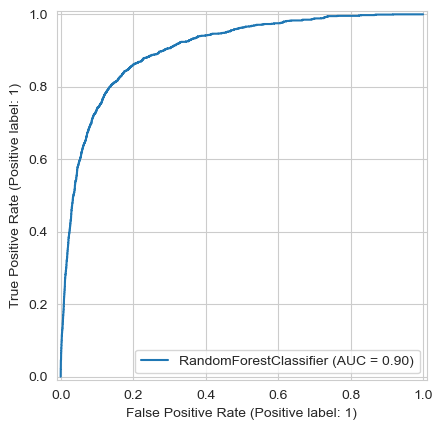

In [199]:
# ROC
RocCurveDisplay.from_estimator(rf1, X_test_pca, y_test)
plt.show()

#### HYPERPARAMETER TUNING USING GRIDSEARCHCV

In [200]:
%%time
rf2 = RandomForestClassifier(random_state=42, oob_score=True)

# Define hyperparameters and ranges to search
params = {
    'n_estimators': [30, 50, 80, 100],
    'max_depth': [10, 20],
    'max_features':[20]
}

grid_search_rf = GridSearchCV(estimator=rf2,
                           param_grid=params,
                           cv=3,
                           n_jobs=-1, verbose=1, scoring="accuracy")

# Perform gridsearch
grid_search_rf.fit(X_train_pca, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
CPU times: total: 4min 9s
Wall time: 13min 28s


GridSearchCV(cv=3,
             estimator=RandomForestClassifier(oob_score=True, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'max_features': [20],
                         'n_estimators': [30, 50, 80, 100]},
             scoring='accuracy', verbose=1)

In [201]:
print("Best parameters found: ", grid_search_rf.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search_rf.best_score_))

rf_best = grid_search_rf.best_estimator_
print("Best Model:", rf_best)

Best parameters found:  {'max_depth': 20, 'max_features': 20, 'n_estimators': 100}
Best cross-validation accuracy: 0.92
Best Model: RandomForestClassifier(max_depth=20, max_features=20, oob_score=True,
                       random_state=42)


In [202]:
# Get the OOB score
print("OOB Score:", rf_best.oob_score_)

OOB Score: 0.921480740727513


In [203]:
# Accuracy for the Train Set
y_train_pred = rf_best.predict(X_train_pca)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.991999857140306

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     50289
           1       1.00      0.92      0.96      5710

    accuracy                           0.99     55999
   macro avg       1.00      0.96      0.98     55999
weighted avg       0.99      0.99      0.99     55999



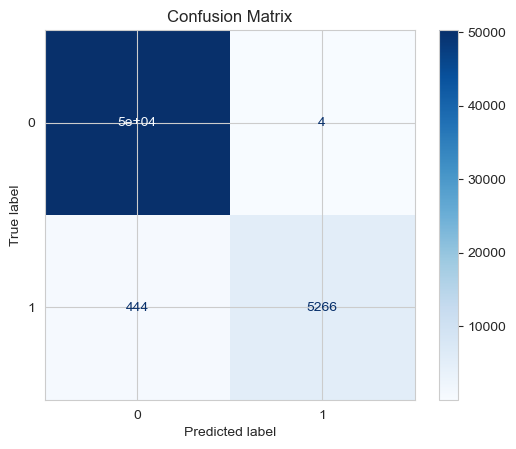

In [204]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [205]:
# Accuracy for the Test Set
y_test_pred = rf_best.predict(X_test_pca)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9220714285714285

              precision    recall  f1-score   support

           0       0.94      0.97      0.96     12578
           1       0.67      0.46      0.54      1422

    accuracy                           0.92     14000
   macro avg       0.81      0.72      0.75     14000
weighted avg       0.91      0.92      0.92     14000



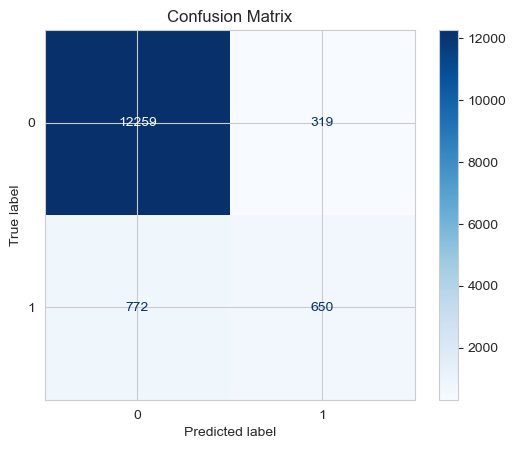

In [206]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

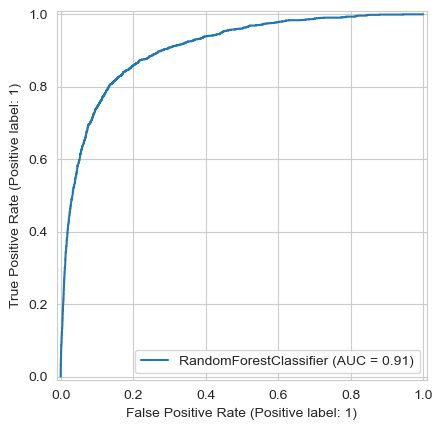

In [207]:
# ROC
RocCurveDisplay.from_estimator(rf_best, X_test_pca, y_test)
plt.show()

In [208]:
print(f"{'Precision Score:':<20} {precision_score(y_test, y_test_pred)}")
print(f"{'Recall Score:':<20} {recall_score(y_test, y_test_pred)}")

Precision Score:     0.6707946336429309
Recall Score:        0.4571026722925457


In [209]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [210]:
# Sensitivity, Specificity, False Positive Rate, Positive Predictive Rate, Negative Predictive Rate
print("Performance Metrics:")
print("---------------------")
print(f"{'Sensitivity (True Positive Rate):':<40} {TP / float(TP+FN)}")
print(f"{'Specificity (True Negative Rate):':<40} {TN / float(TN+FP)}")
print(f"{'False Positive Rate (FPR):':<40} {FP/ float(TN+FP)}")
print(f"{'Positive Predictive Rate (Precision):':<40} {TP/ float(TP+FP)}")
print(f"{'Negative Predictive Rate (NPV):':<40} {TN / float(TN+ FN)}")

Performance Metrics:
---------------------
Sensitivity (True Positive Rate):        0.4571026722925457
Specificity (True Negative Rate):        0.9746382572746064
False Positive Rate (FPR):               0.025361742725393543
Positive Predictive Rate (Precision):    0.6707946336429309
Negative Predictive Rate (NPV):          0.9407566572020566


#### SUMMARY

In [211]:
print(f"{'Accuracy Score for Train Set:':<40} {accuracy_score(y_train, y_train_pred)}")
print(f"{'Accuracy Score for Test Set:':<40} {accuracy_score(y_test, y_test_pred)}")

Accuracy Score for Train Set:            0.991999857140306
Accuracy Score for Test Set:             0.9220714285714285


##### We got an accuracy of ~99.2% for the train set and ~92.2% for the test set, which implies that the model is neither overfitted nor underfitted, but the model is not perfect at predicting unseen data.

### 7.3.2 RANDOM FOREST WITHOUT PCA

In [212]:
from sklearn.ensemble import RandomForestClassifier

# Initial Random Forest Classifier
rf3 = RandomForestClassifier(n_estimators=15, max_depth=10, max_features=10, oob_score=True, random_state=42)
rf3.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=10, max_features=10, n_estimators=15,
                       oob_score=True, random_state=42)

In [213]:
# Accuracy for the Train Set
y_train_pred = rf3.predict(X_train_scaled)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9519812853800961

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     50289
           1       0.83      0.66      0.74      5710

    accuracy                           0.95     55999
   macro avg       0.90      0.82      0.86     55999
weighted avg       0.95      0.95      0.95     55999



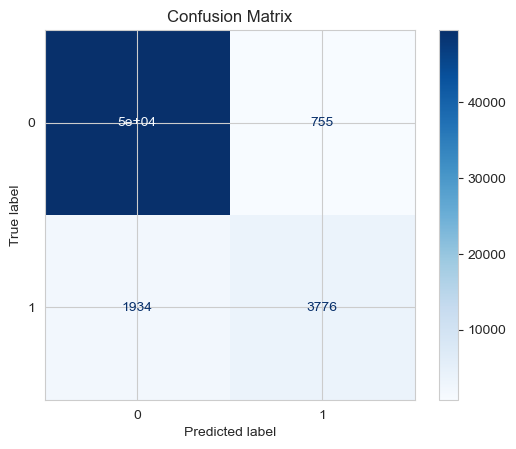

In [214]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)
 
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [215]:
# Accuracy for the Test Set
y_test_pred = rf3.predict(X_test_scaled)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.942

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     12578
           1       0.77      0.62      0.68      1422

    accuracy                           0.94     14000
   macro avg       0.86      0.80      0.83     14000
weighted avg       0.94      0.94      0.94     14000



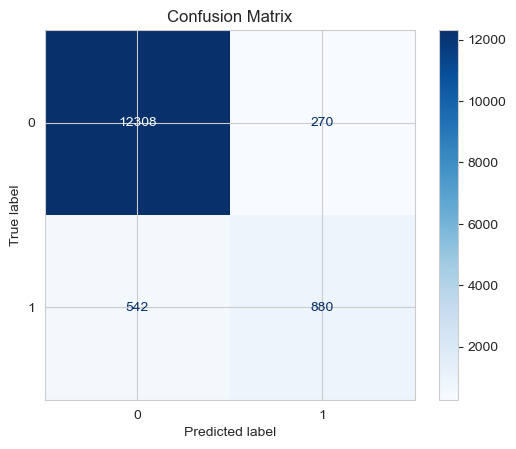

In [216]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

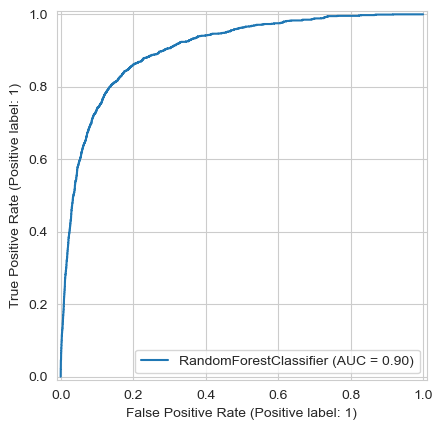

In [217]:
# ROC
RocCurveDisplay.from_estimator(rf1, X_test_pca, y_test)
plt.show()

#### HYPERPARAMETER TUNING USING GRIDSEARCHCV

In [218]:
%%time
rf4 = RandomForestClassifier(random_state=42, oob_score=True)

# Define hyperparameters and ranges to search
params = {
    'n_estimators': [30, 50, 80, 100],
    'max_depth': [10, 20],
    'max_features':[20]
}

grid_search_rf_1 = GridSearchCV(estimator=rf4,
                           param_grid=params,
                           cv=4,
                           n_jobs=-1, verbose=1, scoring="accuracy")

# Perform gridsearch
grid_search_rf_1.fit(X_train_scaled, y_train)

Fitting 4 folds for each of 8 candidates, totalling 32 fits
CPU times: total: 1min 5s
Wall time: 7min 30s


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(oob_score=True, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'max_features': [20],
                         'n_estimators': [30, 50, 80, 100]},
             scoring='accuracy', verbose=1)

In [219]:
print("Best parameters found: ", grid_search_rf_1.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search_rf_1.best_score_))

rf_best_1 = grid_search_rf_1.best_estimator_
print("Best Model:", rf_best_1)

Best parameters found:  {'max_depth': 10, 'max_features': 20, 'n_estimators': 100}
Best cross-validation accuracy: 0.94
Best Model: RandomForestClassifier(max_depth=10, max_features=20, oob_score=True,
                       random_state=42)


In [220]:
# Get the OOB score
print("OOB Score:", rf_best_1.oob_score_)

OOB Score: 0.9415168128002286


In [221]:
# Accuracy for the Train Set
y_train_pred = rf_best_1.predict(X_train_scaled)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9534634547045483

              precision    recall  f1-score   support

           0       0.97      0.98      0.97     50289
           1       0.82      0.69      0.75      5710

    accuracy                           0.95     55999
   macro avg       0.89      0.84      0.86     55999
weighted avg       0.95      0.95      0.95     55999



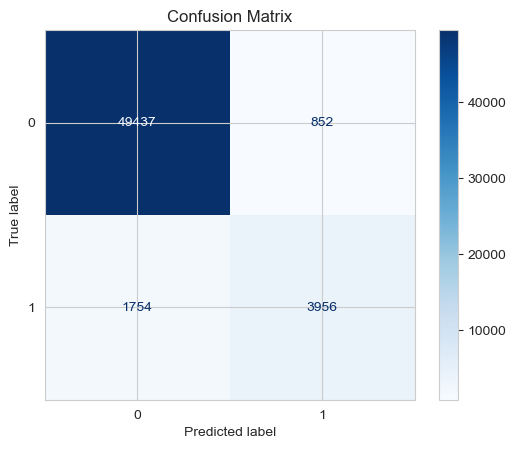

In [222]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [223]:
# Accuracy for the Test Set
y_test_pred = rf_best_1.predict(X_test_scaled)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9425714285714286

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     12578
           1       0.76      0.64      0.69      1422

    accuracy                           0.94     14000
   macro avg       0.86      0.81      0.83     14000
weighted avg       0.94      0.94      0.94     14000



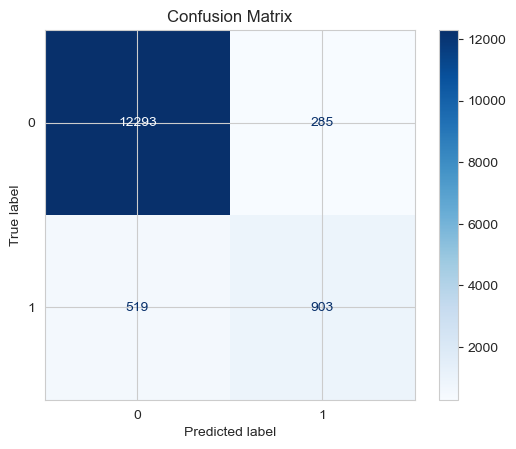

In [224]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

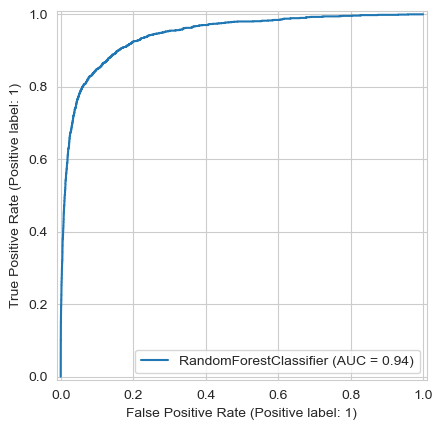

In [225]:
# ROC
RocCurveDisplay.from_estimator(rf_best_1, X_test_scaled, y_test)
plt.show()

In [226]:
print(f"{'Precision Score:':<20} {precision_score(y_test, y_test_pred)}")
print(f"{'Recall Score:':<20} {recall_score(y_test, y_test_pred)}")

Precision Score:     0.76010101010101
Recall Score:        0.6350210970464135


In [227]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [228]:
# Sensitivity, Specificity, False Positive Rate, Positive Predictive Rate, Negative Predictive Rate
print("Performance Metrics:")
print("---------------------")
print(f"{'Sensitivity (True Positive Rate):':<40} {TP / float(TP+FN)}")
print(f"{'Specificity (True Negative Rate):':<40} {TN / float(TN+FP)}")
print(f"{'False Positive Rate (FPR):':<40} {FP/ float(TN+FP)}")
print(f"{'Positive Predictive Rate (Precision):':<40} {TP/ float(TP+FP)}")
print(f"{'Negative Predictive Rate (NPV):':<40} {TN / float(TN+ FN)}")

Performance Metrics:
---------------------
Sensitivity (True Positive Rate):        0.6350210970464135
Specificity (True Negative Rate):        0.9773413897280967
False Positive Rate (FPR):               0.022658610271903322
Positive Predictive Rate (Precision):    0.76010101010101
Negative Predictive Rate (NPV):          0.9594911020917889


#### PREDICTING FEATURE IMPORTANCES

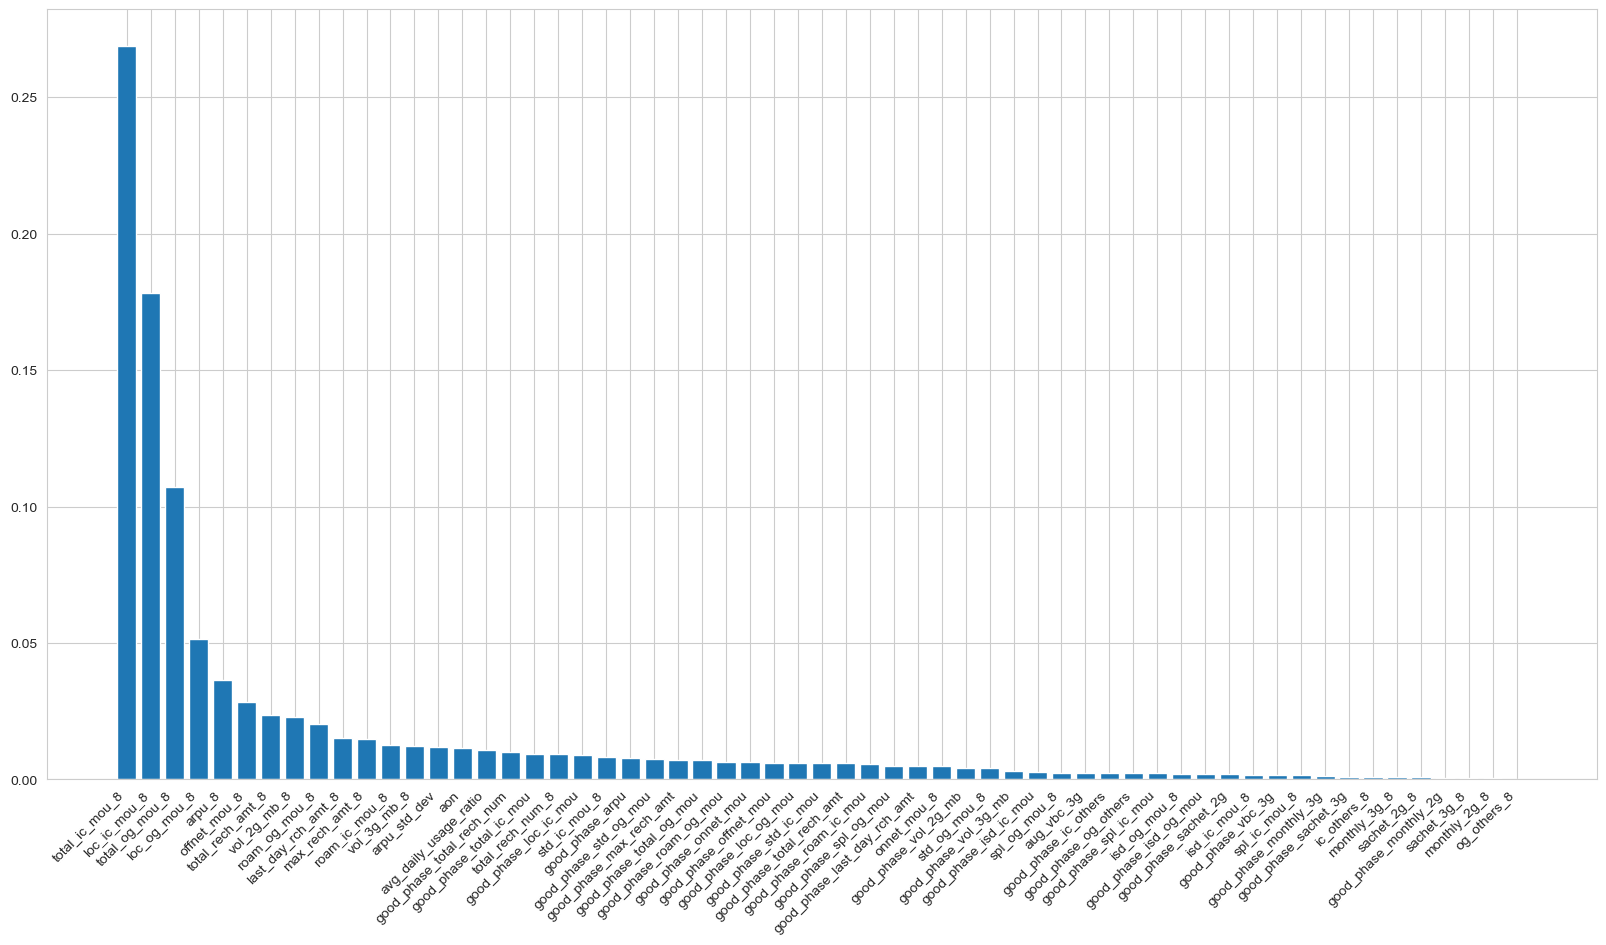

In [229]:
feature_importances = pd.DataFrame({'col':final_vars, 'importance':rf_best_1.feature_importances_})

feature_importances.sort_values(by='importance', ascending=False, inplace=True)

plt.figure(figsize=(20,10))
plt.xticks(rotation=45, ha='right')
plt.bar(feature_importances['col'], feature_importances['importance'])
plt.show()

In [230]:
print('Top 10 features:')
print('-----------------------------------')
print(feature_importances[:10])

Top 10 features:
-----------------------------------
                   col  importance
13      total_ic_mou_8    0.268792
11        loc_ic_mou_8    0.178292
10      total_og_mou_8    0.107027
5         loc_og_mou_8    0.051431
0               arpu_8    0.036445
2         offnet_mou_8    0.028328
18    total_rech_amt_8    0.023633
21         vol_2g_mb_8    0.023027
4        roam_og_mou_8    0.020390
20  last_day_rch_amt_8    0.015104


#### SUMMARY

In [231]:
print(f"{'Accuracy Score for Train Set:':<40} {accuracy_score(y_train, y_train_pred)}")
print(f"{'Accuracy Score for Test Set:':<40} {accuracy_score(y_test, y_test_pred)}")

Accuracy Score for Train Set:            0.9534634547045483
Accuracy Score for Test Set:             0.9425714285714286


##### We got an accuracy of ~95.4% for the train set and ~94.3% for the test set, which implies that the model is neither overfitted nor underfitted and is good at predicting unseen data. This Model is better than the one built with PCA.

## 7.4 ADABOOST

### 7.4.1 ADABOOST WITH PCA

In [232]:
%%time
from sklearn.ensemble import AdaBoostClassifier


adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    learning_rate=1.0,
    algorithm="SAMME.R",
    random_state=42
)
    
adaboost.fit(X_train_pca, y_train)

CPU times: total: 2min 21s
Wall time: 2min 32s


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                   n_estimators=100, random_state=42)

In [233]:
# Accuracy for the Train Set
y_train_pred = adaboost.predict(X_train_pca)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9273737031018411

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     50289
           1       0.68      0.53      0.60      5710

    accuracy                           0.93     55999
   macro avg       0.82      0.75      0.78     55999
weighted avg       0.92      0.93      0.92     55999



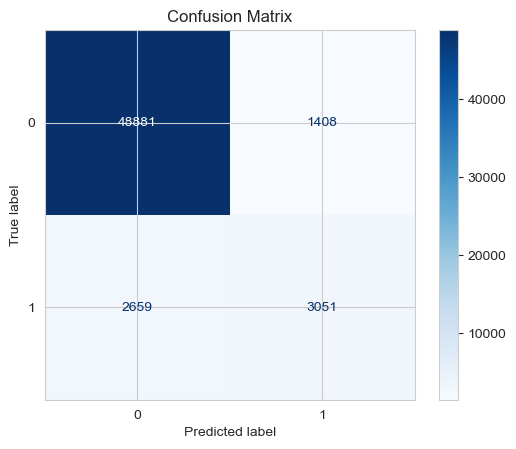

In [234]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)
 
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [235]:
# Accuracy for the Test Set
y_test_pred = adaboost.predict(X_test_pca)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9193571428571429

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     12578
           1       0.63      0.50      0.56      1422

    accuracy                           0.92     14000
   macro avg       0.79      0.74      0.76     14000
weighted avg       0.91      0.92      0.92     14000



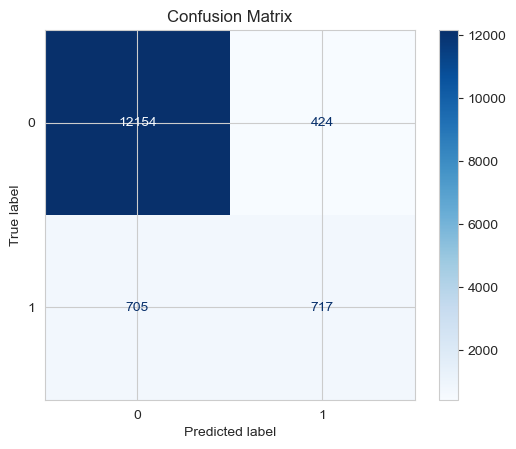

In [236]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

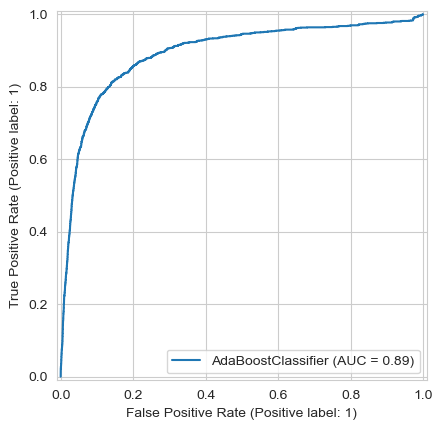

In [237]:
# ROC
RocCurveDisplay.from_estimator(adaboost, X_test_pca, y_test)
plt.show()

In [238]:
print(f"{'Precision Score:':<20} {precision_score(y_test, y_test_pred)}")
print(f"{'Recall Score:':<20} {recall_score(y_test, y_test_pred)}")

Precision Score:     0.628396143733567
Recall Score:        0.5042194092827004


In [239]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [240]:
# Sensitivity, Specificity, False Positive Rate, Positive Predictive Rate, Negative Predictive Rate
print("Performance Metrics:")
print("---------------------")
print(f"{'Sensitivity (True Positive Rate):':<40} {TP / float(TP+FN)}")
print(f"{'Specificity (True Negative Rate):':<40} {TN / float(TN+FP)}")
print(f"{'False Positive Rate (FPR):':<40} {FP/ float(TN+FP)}")
print(f"{'Positive Predictive Rate (Precision):':<40} {TP/ float(TP+FP)}")
print(f"{'Negative Predictive Rate (NPV):':<40} {TN / float(TN+ FN)}")

Performance Metrics:
---------------------
Sensitivity (True Positive Rate):        0.5042194092827004
Specificity (True Negative Rate):        0.9662903482270632
False Positive Rate (FPR):               0.033709651772936874
Positive Predictive Rate (Precision):    0.628396143733567
Negative Predictive Rate (NPV):          0.9451745858931487


#### SUMMARY

In [241]:
print(f"{'Accuracy Score for Train Set:':<40} {accuracy_score(y_train, y_train_pred)}")
print(f"{'Accuracy Score for Test Set:':<40} {accuracy_score(y_test, y_test_pred)}")

Accuracy Score for Train Set:            0.9273737031018411
Accuracy Score for Test Set:             0.9193571428571429


##### We got an accuracy of ~92.7% for the train set and ~91.9% for the test set, which implies that the model is neither overfitted nor underfitted, but the model is good at predicting unseen data.

### 7.4.2 ADABOOST WITHOUT PCA

In [242]:
%%time
adaboost1 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    learning_rate=1.0,
    algorithm="SAMME.R",
    random_state=42
)

adaboost1.fit(X_train_scaled, y_train)

CPU times: total: 58.2 s
Wall time: 1min 2s


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                   n_estimators=100, random_state=42)

In [243]:
# Accuracy for the Train Set
y_train_pred = adaboost1.predict(X_train_scaled)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9428025500455365

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     50289
           1       0.76      0.64      0.70      5710

    accuracy                           0.94     55999
   macro avg       0.86      0.81      0.83     55999
weighted avg       0.94      0.94      0.94     55999



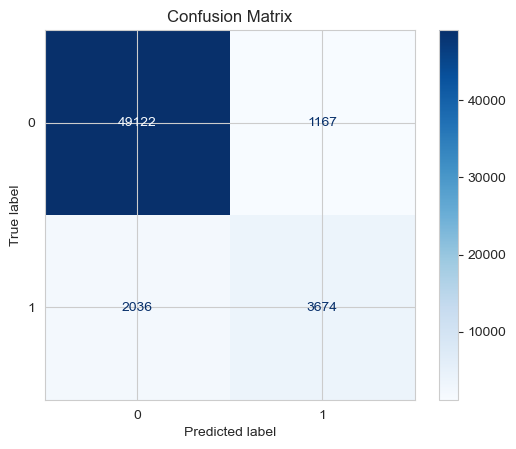

In [244]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)
 
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [245]:
# Accuracy for the Test Set
y_test_pred = adaboost1.predict(X_test_scaled)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9387142857142857

              precision    recall  f1-score   support

           0       0.96      0.97      0.97     12578
           1       0.72      0.64      0.68      1422

    accuracy                           0.94     14000
   macro avg       0.84      0.81      0.82     14000
weighted avg       0.94      0.94      0.94     14000



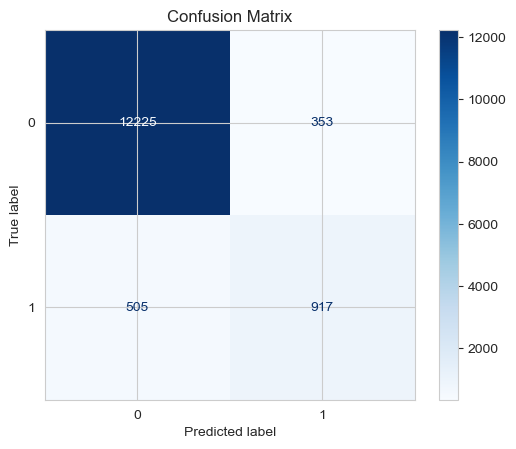

In [246]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

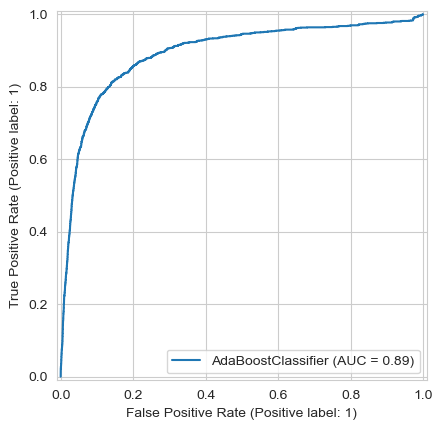

In [247]:
# ROC
RocCurveDisplay.from_estimator(adaboost, X_test_pca, y_test)
plt.show()

In [248]:
print(f"{'Precision Score:':<20} {precision_score(y_test, y_test_pred)}")
print(f"{'Recall Score:':<20} {recall_score(y_test, y_test_pred)}")

Precision Score:     0.7220472440944882
Recall Score:        0.6448663853727145


In [249]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [250]:
# Sensitivity, Specificity, False Positive Rate, Positive Predictive Rate, Negative Predictive Rate
print("Performance Metrics:")
print("---------------------")
print(f"{'Sensitivity (True Positive Rate):':<40} {TP / float(TP+FN)}")
print(f"{'Specificity (True Negative Rate):':<40} {TN / float(TN+FP)}")
print(f"{'False Positive Rate (FPR):':<40} {FP/ float(TN+FP)}")
print(f"{'Positive Predictive Rate (Precision):':<40} {TP/ float(TP+FP)}")
print(f"{'Negative Predictive Rate (NPV):':<40} {TN / float(TN+ FN)}")

Performance Metrics:
---------------------
Sensitivity (True Positive Rate):        0.6448663853727145
Specificity (True Negative Rate):        0.9719351248211162
False Positive Rate (FPR):               0.028064875178883765
Positive Predictive Rate (Precision):    0.7220472440944882
Negative Predictive Rate (NPV):          0.9603299293008641


#### SUMMARY

In [251]:
print(f"{'Accuracy Score for Train Set:':<40} {accuracy_score(y_train, y_train_pred)}")
print(f"{'Accuracy Score for Test Set:':<40} {accuracy_score(y_test, y_test_pred)}")

Accuracy Score for Train Set:            0.9428025500455365
Accuracy Score for Test Set:             0.9387142857142857


##### We got an accuracy of ~94.3% for the train set and ~93.9% for the test set, which implies that the model is neither overfitted nor underfitted, but the model is perfect at predicting unseen data.

## 7.5 XGBOOST

### 7.5.1 XGBOOST WITH PCA

In [252]:
# !pip install xgboost

import xgboost as xgb
from xgboost import XGBClassifier

xgb_cf1 = XGBClassifier(
    n_estimators=300,
    learning_rate=1.0,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,
    min_child_weight=10,
    scale_pos_weight=5,
    objective="binary:logistic",
    random_state=42
)
    
xgb_cf1.fit(X_train_pca, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=1.0, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [253]:
# Accuracy for the Train Set
y_train_pred = xgb_cf1.predict(X_train_pca)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     50289
           1       1.00      1.00      1.00      5710

    accuracy                           1.00     55999
   macro avg       1.00      1.00      1.00     55999
weighted avg       1.00      1.00      1.00     55999



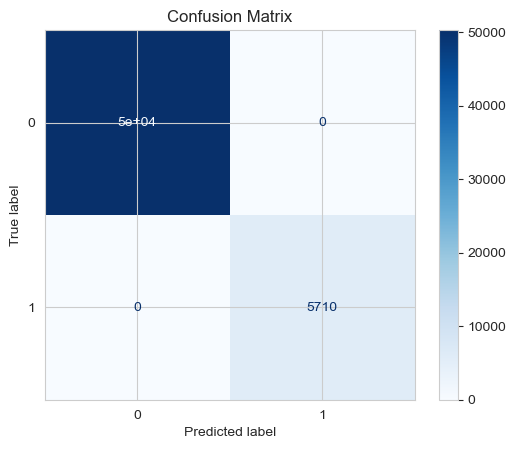

In [254]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)
 
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [255]:
# Accuracy for the Test Set
y_test_pred = xgb_cf1.predict(X_test_pca)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9075714285714286

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     12578
           1       0.55      0.53      0.54      1422

    accuracy                           0.91     14000
   macro avg       0.75      0.74      0.74     14000
weighted avg       0.91      0.91      0.91     14000



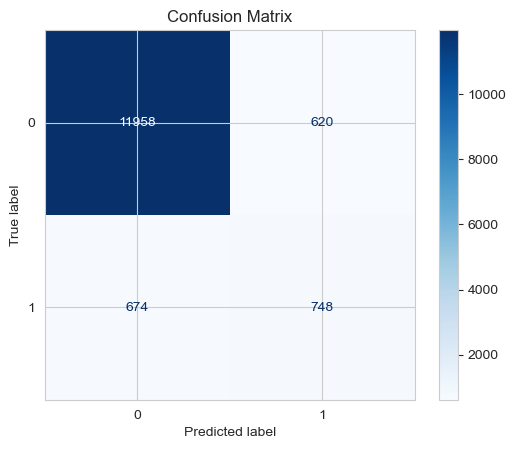

In [256]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

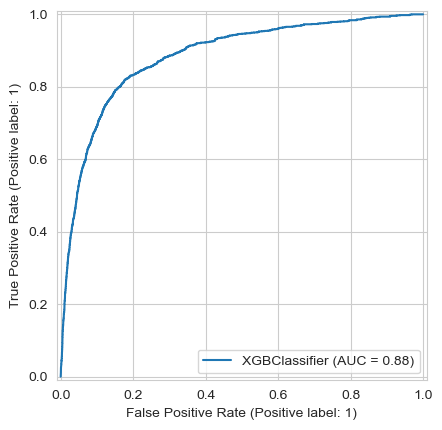

In [257]:
# ROC
RocCurveDisplay.from_estimator(xgb_cf1, X_test_pca, y_test)
plt.show()

#### HYPERPARAMETER TUNING USING RANDOMIEDSEARCHCV

In [258]:
%%time
from sklearn.model_selection import RandomizedSearchCV

xgb_cf2 = XGBClassifier(random_state=42, objective = 'binary:logistic')

# Define hyperparameters and ranges to search
params = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 5, 10],
    'gamma': [0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0]
}

random_search = RandomizedSearchCV(estimator=xgb_cf2, 
                            param_distributions=params, 
                            n_iter=800, 
                            scoring='accuracy', 
                            n_jobs=-1, cv=4, verbose=3, random_state=42)

# Perform gridsearch
random_search.fit(X_train_pca, y_train)

Fitting 4 folds for each of 800 candidates, totalling 3200 fits
CPU times: total: 2min 58s
Wall time: 4h 13min 21s


RandomizedSearchCV(cv=4,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_iter=800, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2,
                                                          0.3],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy', verbose=3)

In [259]:
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(random_search.best_score_))

xgb_best = random_search.best_estimator_
print("Best Model:", xgb_best)

Best parameters found:  {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.7}
Best cross-validation accuracy: 0.93
Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.3, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)


In [260]:
# Accuracy for the Train Set
y_train_pred = xgb_best.predict(X_train_pca)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9600707155484919

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     50289
           1       0.87      0.72      0.79      5710

    accuracy                           0.96     55999
   macro avg       0.92      0.85      0.88     55999
weighted avg       0.96      0.96      0.96     55999



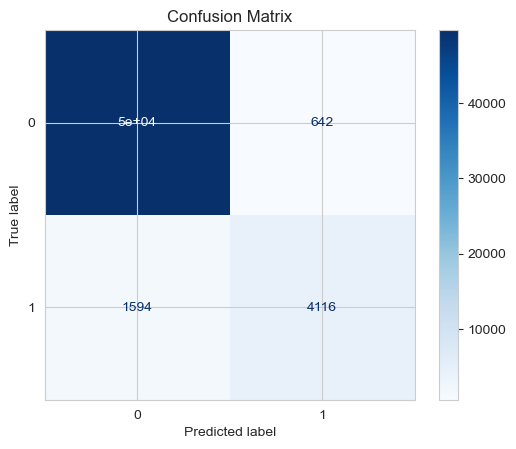

In [261]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [262]:
# Accuracy for the Test Set
y_test_pred = xgb_best.predict(X_test_pca)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.93

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     12578
           1       0.70      0.55      0.61      1422

    accuracy                           0.93     14000
   macro avg       0.82      0.76      0.79     14000
weighted avg       0.92      0.93      0.93     14000



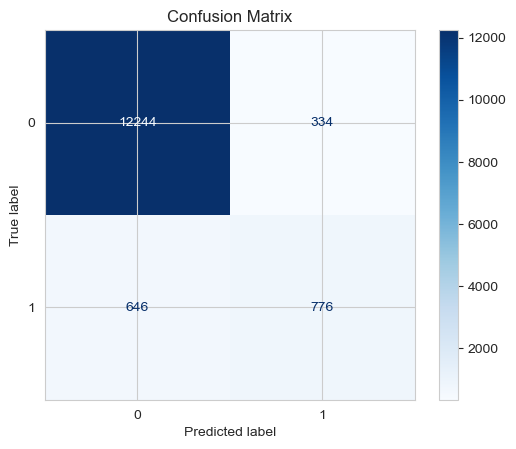

In [263]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

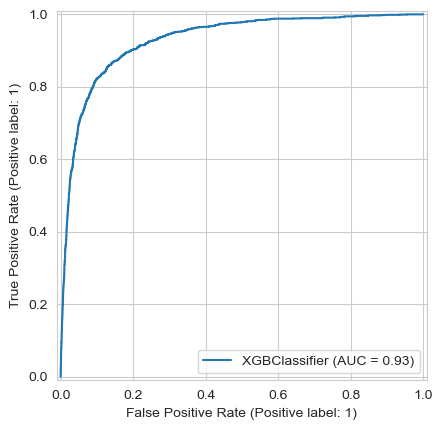

In [264]:
# ROC
RocCurveDisplay.from_estimator(xgb_best, X_test_pca, y_test)
plt.show()

In [265]:
print(f"{'Precision Score:':<20} {precision_score(y_test, y_test_pred)}")
print(f"{'Recall Score:':<20} {recall_score(y_test, y_test_pred)}")

Precision Score:     0.6990990990990991
Recall Score:        0.5457102672292545


In [266]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [267]:
# Sensitivity, Specificity, False Positive Rate, Positive Predictive Rate, Negative Predictive Rate
print("Performance Metrics:")
print("---------------------")
print(f"{'Sensitivity (True Positive Rate):':<40} {TP / float(TP+FN)}")
print(f"{'Specificity (True Negative Rate):':<40} {TN / float(TN+FP)}")
print(f"{'False Positive Rate (FPR):':<40} {FP/ float(TN+FP)}")
print(f"{'Positive Predictive Rate (Precision):':<40} {TP/ float(TP+FP)}")
print(f"{'Negative Predictive Rate (NPV):':<40} {TN / float(TN+ FN)}")

Performance Metrics:
---------------------
Sensitivity (True Positive Rate):        0.5457102672292545
Specificity (True Negative Rate):        0.9734456988392431
False Positive Rate (FPR):               0.026554301160756875
Positive Predictive Rate (Precision):    0.6990990990990991
Negative Predictive Rate (NPV):          0.9498836307214895


#### SUMMARY

In [268]:
print(f"{'Accuracy Score for Train Set:':<40} {accuracy_score(y_train, y_train_pred)}")
print(f"{'Accuracy Score for Test Set:':<40} {accuracy_score(y_test, y_test_pred)}")

Accuracy Score for Train Set:            0.9600707155484919
Accuracy Score for Test Set:             0.93


##### We got an accuracy of ~96% for the train set and ~93% for the test set, which implies that the model is neither overfitted nor underfitted and is good at predicting unseen data.

### 7.5.2 XGBOOST WITHOUT PCA

In [269]:
xgb_cf3 = XGBClassifier(
    n_estimators=300,
    learning_rate=1.0,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0.1,
    min_child_weight=10,
    scale_pos_weight=5,
    objective="binary:logistic",
    random_state=42
)
    
xgb_cf3.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=1.0, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [270]:
# Accuracy for the Train Set
y_train_pred = xgb_cf3.predict(X_train_scaled)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

Train accuracy : 0.9995535634564903

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     50289
           1       1.00      1.00      1.00      5710

    accuracy                           1.00     55999
   macro avg       1.00      1.00      1.00     55999
weighted avg       1.00      1.00      1.00     55999



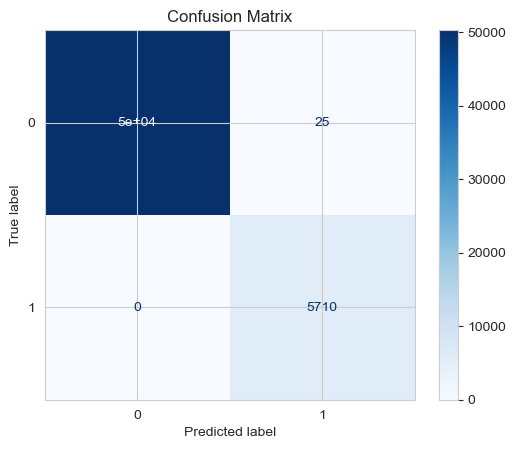

In [271]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)
 
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [272]:
# Accuracy for the Test Set
y_test_pred = xgb_cf3.predict(X_test_scaled)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

Test accuracy : 0.9214285714285714

              precision    recall  f1-score   support

           0       0.96      0.95      0.96     12578
           1       0.61      0.64      0.62      1422

    accuracy                           0.92     14000
   macro avg       0.78      0.80      0.79     14000
weighted avg       0.92      0.92      0.92     14000



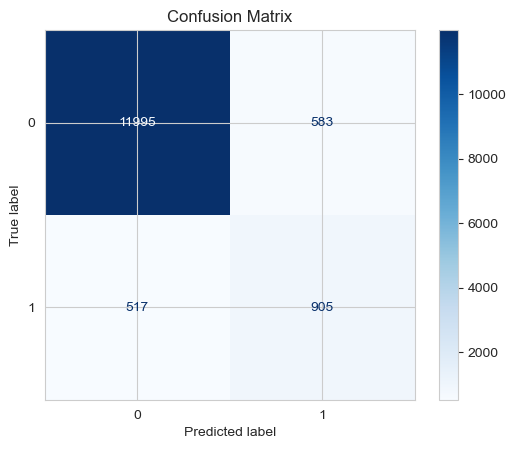

In [273]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

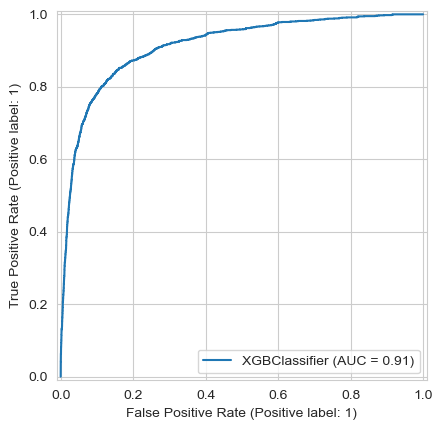

In [274]:
# ROC
RocCurveDisplay.from_estimator(xgb_cf3, X_test_scaled, y_test)
plt.show()

#### HYPERPARAMETER TUNING USING RANDOMIEDSEARCHCV

In [ ]:
%%time
xgb_cf4 = XGBClassifier(random_state=42, objective = 'binary:logistic')

# Define hyperparameters and ranges to search
params = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

random_search_1 = RandomizedSearchCV(estimator=xgb_cf4, 
                            param_distributions=params, 
                            n_iter=800, 
                            scoring='accuracy', 
                            n_jobs=-1, cv=4, verbose=3, random_state=42)

# Perform gridsearch
random_search_1.fit(X_train_scaled, y_train)

Fitting 4 folds for each of 800 candidates, totalling 3200 fits


In [ ]:
print("Best parameters found: ", random_search_1.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(random_search_1.best_score_))

xgb_best_1 = random_search_1.best_estimator_
print("Best Model:", xgb_best_1)

In [ ]:
# Accuracy for the Train Set
y_train_pred = xgb_best_1.predict(X_train_scaled)
print(f'Train accuracy : {accuracy_score(y_train, y_train_pred)}')

print()
# Print the report on train data
print(classification_report(y_train, y_train_pred))

In [ ]:
# Confusion matrix 
confusion = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### MAKING PREDICTIONS ON THE TEST SET

In [ ]:
# Accuracy for the Test Set
y_test_pred = xgb_best_1.predict(X_test_scaled)
print(f'Test accuracy : {accuracy_score(y_test, y_test_pred)}')

print()
# Print the report on test data
print(classification_report(y_test, y_test_pred))

In [ ]:
# Confusion matrix 
confusion = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# ROC
RocCurveDisplay.from_estimator(xgb_best_1, X_test_scaled, y_test)
plt.show()

In [ ]:
print(f"{'Precision Score:':<20} {precision_score(y_test, y_test_pred)}")
print(f"{'Recall Score:':<20} {recall_score(y_test, y_test_pred)}")

In [ ]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [ ]:
# Sensitivity, Specificity, False Positive Rate, Positive Predictive Rate, Negative Predictive Rate
print("Performance Metrics:")
print("---------------------")
print(f"{'Sensitivity (True Positive Rate):':<40} {TP / float(TP+FN)}")
print(f"{'Specificity (True Negative Rate):':<40} {TN / float(TN+FP)}")
print(f"{'False Positive Rate (FPR):':<40} {FP/ float(TN+FP)}")
print(f"{'Positive Predictive Rate (Precision):':<40} {TP/ float(TP+FP)}")
print(f"{'Negative Predictive Rate (NPV):':<40} {TN / float(TN+ FN)}")

#### PREDICTING FEATURE IMPORTANCES

In [ ]:
feature_importances = pd.DataFrame({'col':final_vars, 'importance':xgb_best_1.feature_importances_})

feature_importances.sort_values(by='importance', ascending=False, inplace=True)

plt.figure(figsize=(20,10))
plt.xticks(rotation=45, ha='right')
plt.bar(feature_importances['col'], feature_importances['importance'])
plt.show()

In [ ]:
print('Top 10 features:')
print('-----------------------------------')
print(feature_importances[:10])

#### SUMMARY

In [ ]:
print(f"{'Accuracy Score for Train Set:':<40} {accuracy_score(y_train, y_train_pred)}")
print(f"{'Accuracy Score for Test Set:':<40} {accuracy_score(y_test, y_test_pred)}")

##### We got an accuracy of ~95.4% for the train set and ~94.3% for the test set, which implies that the model is neither overfitted nor underfitted and is good at predicting unseen data. This Model is better than the one built with PCA.

### STEP #8 - CREATING SUBMISSION FILE

For submission, we need to make sure that the format is exactly the same as the sample.csv file. It contains 2 columns, id and churn_probability

In [ ]:
sample.head()

The submission file should contain churn_probability values that have to be predicted for the unseen data provided (test.csv). The final dataframe after performing the Feature Engineering was:

In [ ]:
unseen_scaled.head()

Next, lets create a new column in the unseen dataset called churn_probability and use the model pipeline to predict the probabilities for this data

In [ ]:
# Best Performing model is final_model

unseen['churn_probability'] = final_model.predict(unseen_scaled)

output = unseen[['id','churn_probability']]
output.head()

Finally, lets create a csv file out of this dataset, ensuring to set index=False to avoid an addition column in the csv.

In [ ]:
output.to_csv('Submission.csv', index=False)